# Phase 2

## Imports

In [1]:
#!pip install openpyxl scikit-learn umap-learn hdbscan scikit-fuzzy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from scipy.sparse import csr_matrix, issparse
from scipy.spatial.distance import cdist

from sklearn.preprocessing import normalize
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, BisectingKMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, adjusted_rand_score
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances

#!pip install cdlib --quiet
import cdlib
from cdlib import algorithms as cdlib_alg
from cdlib import evaluation as cdlib_eval
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

from cdlib import evaluation
from copkmeans.cop_kmeans import cop_kmeans
from active_semi_clustering.semi_supervised.pairwise_constraints import MPCKMeans
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx

import os, json as _json
from sklearn.metrics import adjusted_rand_score
import umap
import hdbscan as hdbscan_lib
import skfuzzy as fuzz
from sklearn.metrics import pairwise_distances
from sklearn.model_selection import KFold
import time, json, os
import warnings
warnings.filterwarnings('ignore')
import time
import pickle
from sklearn.metrics import pairwise_distances
from cdlib import evaluation as cdlib_eval
import glob
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import json as _json, os as _os
from sklearn.preprocessing import normalize as sk_normalize
from itertools import combinations
import matplotlib.lines as mlines

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 60)
print('Imports OK')

Note: to be able to use all crisp methods, you need to install some additional packages:  {'graph_tool', 'infomap', 'bayanpy', 'wurlitzer', 'leidenalg'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'ASLPAw', 'pyclustering'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'wurlitzer', 'leidenalg'}
Imports OK


In [2]:
# set to True only when you explicitly want to delete checkpoints
ALLOW_DELETE = False

CHECKPOINT_DIR = 'cv_checkpoints_jt'
checkpoints = glob.glob(f'{CHECKPOINT_DIR}/*.json')
npy_files   = glob.glob(f'{CHECKPOINT_DIR}/*.npy')
all_files   = checkpoints + npy_files
print(f'Checkpoints encontrados: {len(all_files)}')
for cp in all_files:
    print(f'  {cp}')

if ALLOW_DELETE:
    for cp in all_files:
        os.remove(cp)
        print(f'  Borrado: {cp}')
    print('Todos los checkpoints eliminados')
else:
    print('\n ALLOW_DELETE=False — no se ha borrado nada.')
    print('   Pon ALLOW_DELETE=True si realmente quieres borrarlos.')


Checkpoints encontrados: 10
  cv_checkpoints_jt/cv_hdbscan_guided.json
  cv_checkpoints_jt/cv_kmeans.json
  cv_checkpoints_jt/cv_fcmcl.json
  cv_checkpoints_jt/cv_hdbscan.json
  cv_checkpoints_jt/cv_gmm.json
  cv_checkpoints_jt/cv_bkmeans.json
  cv_checkpoints_jt/cv_cop_smart.json
  cv_checkpoints_jt/cv_cop_allpairs.json
  cv_checkpoints_jt/X_umap_direct.npy
  cv_checkpoints_jt/X_umap_on_svd.npy

 ALLOW_DELETE=False — no se ha borrado nada.
   Pon ALLOW_DELETE=True si realmente quieres borrarlos.


# 2b Job Title

## 1. Import Data and Declare Parameters

In [3]:
#path and import data
PATH_USAGE_MATRIX = 'output phase1 JT/JT_usage_matrix.csv'
PATH_JT_METADATA = 'output phase1 JT/JT_metadata.csv'

usage_matrix = pd.read_csv(PATH_USAGE_MATRIX, index_col=0)
df_jt_metadata = pd.read_csv(PATH_JT_METADATA)


print(f'Usage matrix:   {usage_matrix.shape[0]:,} job titles × {usage_matrix.shape[1]:,} t-codes')



Usage matrix:   866 job titles × 1,626 t-codes


In [4]:
#VARIABLES
MIN_TCODES_PER_JT = 4

#Dim Reduction
N_COMPONENTS_SVD = 202  #pick the number that gives 90% of explained var
N_COMPONENTS_UMAP_DIRECT = 20 
N_COMPONENTS_UMAP_ON_SVD = 20 
N_NEIGHBORS_UMAP = 15
UMAP_METRIC = 'cosine' #better than euclidean for SAP usage data


#K-search
K_MIN = 40 #lower bound
K_MAX = 300 #upper bound
K_STEP = 5
K_FINAL = None #set after reviewing silhouette score


#Final clustering chosen method: A = K-means , B = Bisection K-means , C = GMM , D = HDBSCAN
METHOD_FINAL = 'D'

#HDBSCAN
HDBSCAN_MIN_CLUSTER_SIZE = 10
HDBSCAN_MIN_SAMPLES = 10


#Final representation: SVD, UMAP, SVD_UMAP
REPRESENTATION_FINAL = 'SVD_UMAP'


#Cluster t-code profiles
PREVALENCE_REQUIRED = 0.60  # above 60%
PREVALENCE_OPTIONAL = 0.25  # 25% To 60% OPTIONAL

RANDOM_STATE = 42

print('Configuration loaded')

Configuration loaded


In [5]:
matrix_clean = usage_matrix.copy()
total_jt = matrix_clean.shape[0]


tcodes_per_jt = (matrix_clean > 0).sum(axis=1)
sparse_jt =tcodes_per_jt[tcodes_per_jt < MIN_TCODES_PER_JT].index
matrix_train = matrix_clean.drop(index=sparse_jt)

#if not use MIN_TCODES_PER_USER
#matrix_train = usage_matrix.copy()

print(f'Sparse job titles: {len(sparse_jt)} 'f' ({len(sparse_jt)/total_jt:.1%} of total)')
print(f'Training matrix: {matrix_train.shape[0]:,} job titles x {matrix_train.shape[1]:,} t-codes')


Sparse job titles: 70  (8.1% of total)
Training matrix: 796 job titles x 1,626 t-codes


## 2. Log(x+1)

In [6]:
# No se aplica log1p previo — TF-IDF con sublinear_tf=True
# ya aplica 1+log(tf) internamente, lo que evita la doble compresión.
# Se usa la matriz de conteos directamente como entrada a TF-IDF.
matrix_train_log = matrix_train.copy()  # alias mantenido para compatibilidad downstream

vals_raw = matrix_train.values[matrix_train.values > 0]

In [7]:
print(f'Pipeline — TF-IDF con sublinear_tf=True (sin log1p previo):')
print(f'  Raw counts: mean={vals_raw.mean():.0f}  max={vals_raw.max():.0f}')
print(f'  (Sublinear_tf aplica 1+log(tf) internamente en TF-IDF)')

print(f'\nMatrix summary:')
print(f'  Original:          {matrix_clean.shape[0]:,} job title × {matrix_clean.shape[1]:,} t-codes')
print(f'  Training:          {matrix_train.shape[0]:,} job title × {matrix_train.shape[1]:,} t-codes')
print(f'  Excluded (sparse): {len(sparse_jt):,} job titles ({len(sparse_jt)/total_jt:.1%})')

Pipeline — TF-IDF con sublinear_tf=True (sin log1p previo):
  Raw counts: mean=109  max=27568
  (Sublinear_tf aplica 1+log(tf) internamente en TF-IDF)

Matrix summary:
  Original:          866 job title × 1,626 t-codes
  Training:          796 job title × 1,626 t-codes
  Excluded (sparse): 70 job titles (8.1%)


## 3. TF-IDF

In [8]:
# TF-IDF
X_raw   = csr_matrix(matrix_train_log.values.astype(float))
tfidf   = TfidfTransformer(sublinear_tf=True, norm='l2')
X_tfidf = tfidf.fit_transform(X_raw)

In [9]:
print(f'TF-IDF matrix: {X_tfidf.shape[0]:,} job title × {X_tfidf.shape[1]:,} t-codes')
print(f'Density after TF-IDF: {X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]):.2%}')

TF-IDF matrix: 796 job title × 1,626 t-codes
Density after TF-IDF: 2.21%


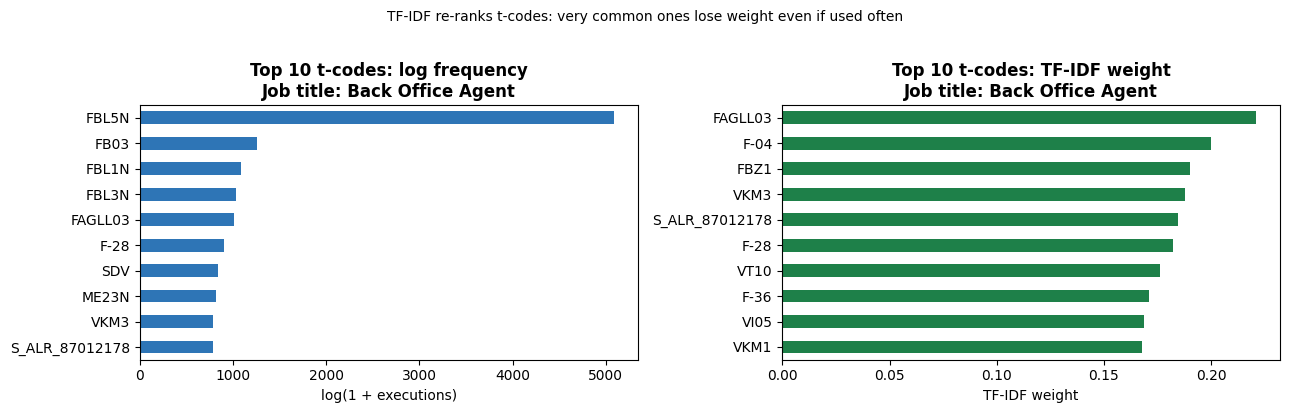

In [10]:
# Visual check with a specific user
sample_idx  = min(50, matrix_train_log.shape[0] - 1)
sample_user = matrix_train_log.index[sample_idx]

raw_s   = matrix_train_log.iloc[sample_idx]
tfidf_s = pd.Series(
    X_tfidf[sample_idx].toarray().flatten(),
    index=matrix_train_log.columns
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

raw_s.nlargest(10).sort_values().plot(kind='barh', ax=axes[0], color='#2E75B6')
axes[0].set_title(f'Top 10 t-codes: log frequency\nJob title: {sample_user}',fontweight='bold')
axes[0].set_xlabel('log(1 + executions)')

tfidf_s.nlargest(10).sort_values().plot(kind='barh', ax=axes[1], color='#1E8049')
axes[1].set_title(f'Top 10 t-codes: TF-IDF weight\nJob title: {sample_user}',fontweight='bold')
axes[1].set_xlabel('TF-IDF weight')

plt.suptitle('TF-IDF re-ranks t-codes: very common ones lose weight even if used often',fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

## 4. Dim reduction

## 4.1 SVD

Cumulative variance explained:
  80% → 120 components
  85% → 154 components
  90% → 202 components
  95% → 280 components

Max variance explained with 300 components: 95.8%


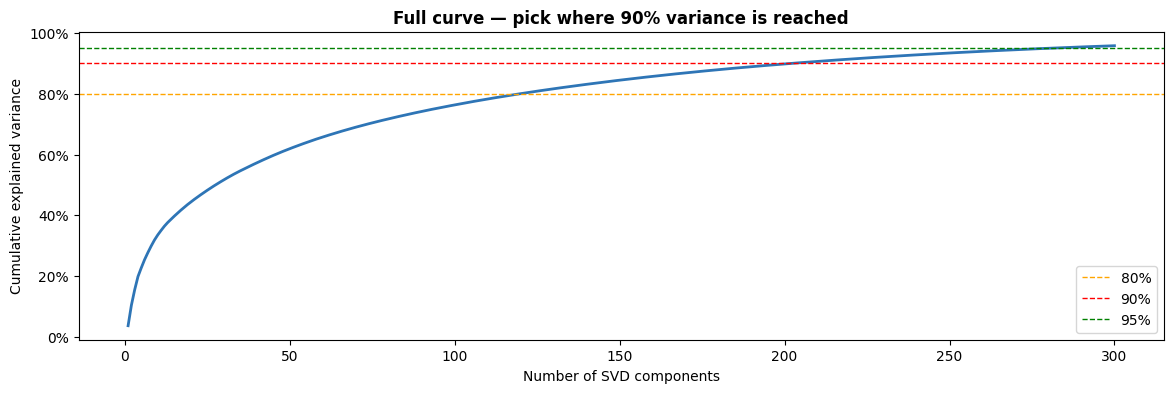

In [11]:
#to find the SVD components that explain 90% of variance

N_CAL_COMPONENTS = min(300, min(X_tfidf.shape) - 1)

svd_cal = TruncatedSVD(n_components=N_CAL_COMPONENTS, random_state=RANDOM_STATE)
svd_cal.fit(X_tfidf)

var_cumulative = np.cumsum(svd_cal.explained_variance_ratio_)

# Print threshold crossings
print('Cumulative variance explained:')
for target in [0.80, 0.85, 0.90, 0.95]:
    idx = np.where(var_cumulative >= target)[0]
    if len(idx) > 0:
        print(f'  {target:.0%} → {idx[0]+1:3d} components')
    else:
        print(f'  {target:.0%} → not reached with {N_CAL_COMPONENTS} components '
              f'(max achieved: {var_cumulative[-1]:.1%})')

print(f'\nMax variance explained with {N_CAL_COMPONENTS} components: '
      f'{var_cumulative[-1]:.1%}')

# Plot
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(range(1, len(var_cumulative)+1), var_cumulative,
             linewidth=2, color='#2E75B6')
ax.axhline(0.80, color='orange', linestyle='--', linewidth=1, label='80%')
ax.axhline(0.90, color='red',    linestyle='--', linewidth=1, label='90%')
ax.axhline(0.95, color='green',  linestyle='--', linewidth=1, label='95%')
ax.set_xlabel('Number of SVD components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('Full curve — pick where 90% variance is reached',
                  fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()

In [12]:
# Build X_svd with the components that explain 90% of var

svd   = TruncatedSVD(n_components=N_COMPONENTS_SVD, random_state=RANDOM_STATE)
X_svd = svd.fit_transform(X_tfidf)
X_svd = normalize(X_svd, norm='l2')

In [13]:
print(f'  Shape:             {X_svd.shape}')
print(f'  Variance explained: {svd.explained_variance_ratio_.sum():.1%}')

  Shape:             (796, 202)
  Variance explained: 90.0%


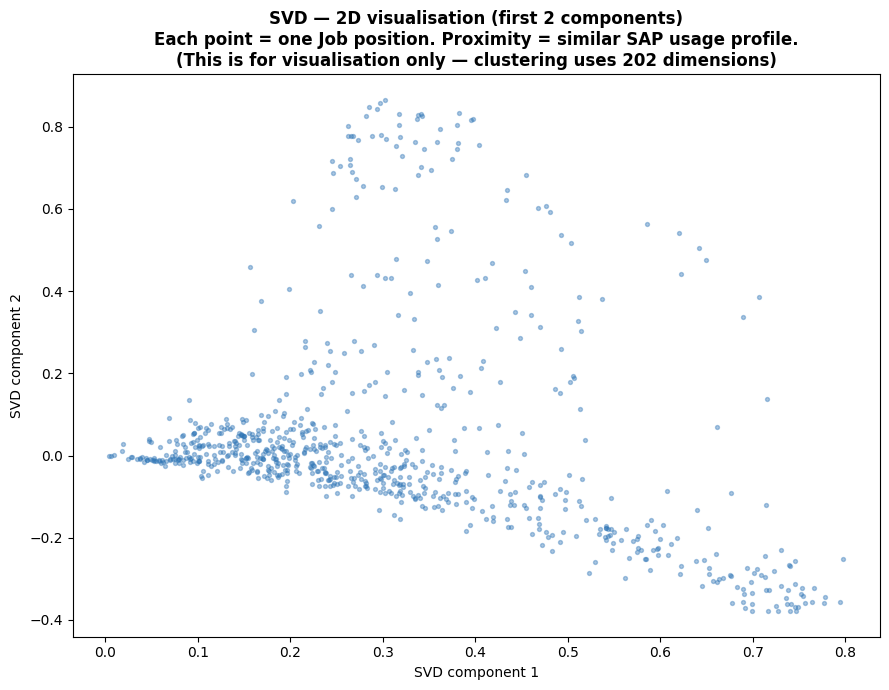

In [14]:
# 2D Representation with the first 2 dimensions

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_svd[:, 0], X_svd[:, 1],
           alpha=0.4, s=8, c='#2E75B6')
ax.set_title('SVD — 2D visualisation (first 2 components)\n'
             'Each point = one Job position. Proximity = similar SAP usage profile.\n'
             '(This is for visualisation only — clustering uses '
             f'{N_COMPONENTS_SVD} dimensions)',
             fontweight='bold')
ax.set_xlabel('SVD component 1')
ax.set_ylabel('SVD component 2')
plt.tight_layout()
plt.show()


## 4.2 UMAP

In [15]:
# Build X_umap_direct — with cache so it only runs once
import os, numpy as np_
X_tfidf_dense = X_tfidf.toarray()

_cache_direct = f'{CHECKPOINT_DIR}/X_umap_direct.npy'
if os.path.exists(_cache_direct):
    X_umap_direct      = np_.load(_cache_direct)
    X_umap_direct_norm = normalize(X_umap_direct, norm='l2')
    print(f'    X_umap_direct loaded from cache  shape={X_umap_direct.shape}')
else:
    reducer_direct = umap.UMAP(
        n_components = N_COMPONENTS_UMAP_DIRECT,
        metric       = UMAP_METRIC,
        n_neighbors  = N_NEIGHBORS_UMAP,
        min_dist     = 0.0,
        random_state = RANDOM_STATE,
        low_memory   = True
    )
    X_umap_direct      = reducer_direct.fit_transform(X_tfidf_dense)
    X_umap_direct_norm = normalize(X_umap_direct, norm='l2')
    np_.save(_cache_direct, X_umap_direct)
    print(f'    X_umap_direct computed and cached  shape={X_umap_direct.shape}')


    X_umap_direct loaded from cache  shape=(796, 20)


In [16]:
print(f'  Shape: {X_umap_direct_norm.shape}')

  Shape: (796, 20)


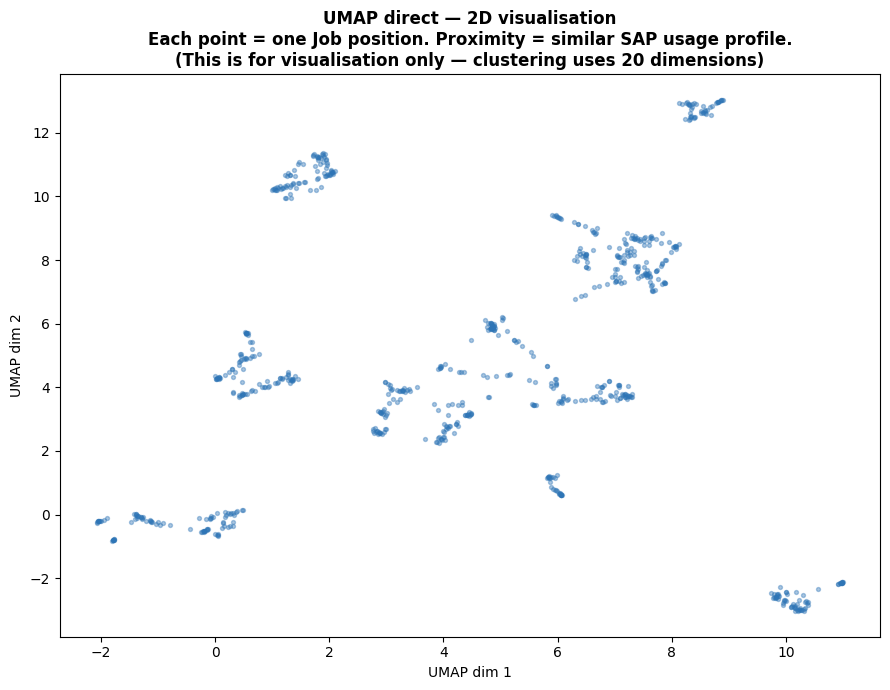


What to look for in the plot:
  Clear separated groups --> strong cluster structure --> good
  Uniform cloud with no structure --> clustering will be hard


In [17]:
# 2D UMAP just for visualisation
# The 2D plot just helps us see if there is visible cluster structure.

reducer_2d_direct = umap.UMAP(
    n_components = 2,
    metric       = UMAP_METRIC,
    n_neighbors  = N_NEIGHBORS_UMAP,
    min_dist     = 0.0,
    random_state = RANDOM_STATE,
    low_memory   = True
)

X_umap_direct_2d = reducer_2d_direct.fit_transform(X_tfidf_dense)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_umap_direct_2d[:, 0], X_umap_direct_2d[:, 1],
           alpha=0.4, s=8, c='#2E75B6')
ax.set_title('UMAP direct — 2D visualisation\n'
             'Each point = one Job position. Proximity = similar SAP usage profile.\n'
             '(This is for visualisation only — clustering uses '
             f'{N_COMPONENTS_UMAP_DIRECT} dimensions)',
             fontweight='bold')
ax.set_xlabel('UMAP dim 1')
ax.set_ylabel('UMAP dim 2')
plt.tight_layout()
plt.show()

print('\nWhat to look for in the plot:')
print('  Clear separated groups --> strong cluster structure --> good')
print('  Uniform cloud with no structure --> clustering will be hard')

## 4.3 UMAP on top of SVD


In [18]:
# Build X_umap_on_svd — with cache so it only runs once
import os, numpy as np_

_cache_svd = f'{CHECKPOINT_DIR}/X_umap_on_svd.npy'
if os.path.exists(_cache_svd):
    X_umap_on_svd      = np_.load(_cache_svd)
    X_umap_on_svd_norm = normalize(X_umap_on_svd, norm='l2')
    print(f'    X_umap_on_svd loaded from cache  shape={X_umap_on_svd.shape}')
else:
    reducer_on_svd = umap.UMAP(
        n_components = N_COMPONENTS_UMAP_ON_SVD,
        metric       = UMAP_METRIC,
        n_neighbors  = N_NEIGHBORS_UMAP,
        min_dist     = 0.0,
        random_state = RANDOM_STATE,
        low_memory   = True
    )
    X_umap_on_svd      = reducer_on_svd.fit_transform(X_svd)
    X_umap_on_svd_norm = normalize(X_umap_on_svd, norm='l2')
    np_.save(_cache_svd, X_umap_on_svd)
    print(f'    X_umap_on_svd computed and cached  shape={X_umap_on_svd.shape}')


    X_umap_on_svd loaded from cache  shape=(796, 20)


In [19]:
print(f'  Shape: {X_umap_on_svd_norm.shape}')

  Shape: (796, 20)


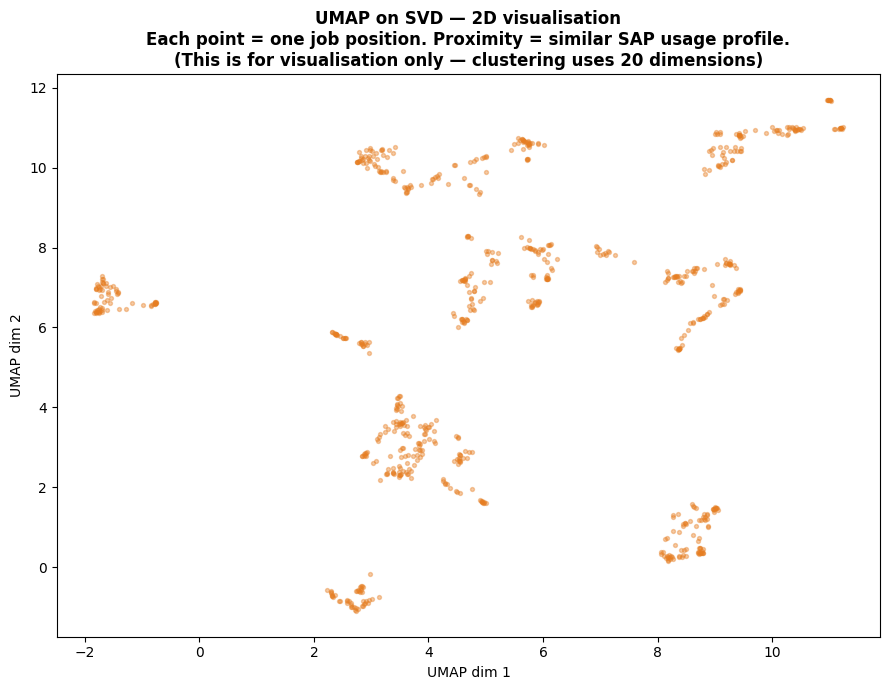

In [20]:
# 2D visualization
reducer_on_svd_2d = umap.UMAP(
    n_components = 2,
    metric       = UMAP_METRIC,
    n_neighbors  = N_NEIGHBORS_UMAP,
    min_dist     = 0.0,
    random_state = RANDOM_STATE,
    low_memory   = True
)

X_umap_on_svd_2d = reducer_on_svd_2d.fit_transform(X_svd)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_umap_on_svd_2d[:, 0], X_umap_on_svd_2d[:, 1],
           alpha=0.4, s=8, c='#E67E22')
ax.set_title('UMAP on SVD — 2D visualisation\n'
             'Each point = one job position. Proximity = similar SAP usage profile.\n'
             '(This is for visualisation only — clustering uses '
             f'{N_COMPONENTS_UMAP_ON_SVD} dimensions)',
             fontweight='bold')
ax.set_xlabel('UMAP dim 1')
ax.set_ylabel('UMAP dim 2')
plt.tight_layout()
plt.show()

## 4.4 Summary

In [21]:
# Summary of all 3 representations
print('ALL 3 REPRESENTATIONS READY')
print('═'*55)
print(f'  Representation 1 — SVD only:      {X_svd.shape}')
print(f'  Representation 2 — UMAP direct:   {X_umap_direct_norm.shape}')
print(f'  Representation 3 — SVD → UMAP:    {X_umap_on_svd_norm.shape}')
print('═'*55)


ALL 3 REPRESENTATIONS READY
═══════════════════════════════════════════════════════
  Representation 1 — SVD only:      (796, 202)
  Representation 2 — UMAP direct:   (796, 20)
  Representation 3 — SVD → UMAP:    (796, 20)
═══════════════════════════════════════════════════════


# 5. Clustering Methods

## KFold Validation Set up

In [22]:
# K-FOLD HYPERPARAMETER SEARCH + VALIDATION


warnings.filterwarnings('ignore')

# Config
N_FOLDS      = 5
RANDOM_STATE = 42

# HDBSCAN grid
MCS_RANGE = [5, 8, 10, 15, 20]
MS_RANGE  = [1, 3, 5,  8, 10]

# Checkpoint path — saves even if it disconnect won't lose progress
CHECKPOINT_DIR = 'cv_checkpoints_jt'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def save_checkpoint(name, data):
    path = f'{CHECKPOINT_DIR}/{name}.json'
    # Convert numpy types to native Python for JSON serialization
    def convert(o):
        if isinstance(o, (np.integer,)): return int(o)
        if isinstance(o, (np.floating,)): return float(o)
        if isinstance(o, np.ndarray): return o.tolist()
        return o
    with open(path, 'w') as f:
        json.dump(data, f, default=convert)
    print(f'    Checkpoint saved: {name}')

def load_checkpoint(name):
    path = f'{CHECKPOINT_DIR}/{name}.json'
    if os.path.exists(path):
        with open(path, 'r') as f:
            print(f'    Checkpoint loaded: {name}')
            return json.load(f)
    return None

# KFold splitter
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Metric helper
def eval_on_test(X_test, labels_test):
    """Silhouette + DB on held-out test set."""
    labels_test = np.array(labels_test)
    mask        = labels_test != -1
    n_clusters  = len(np.unique(labels_test[mask]))
    pct_out     = (labels_test == -1).sum() / len(labels_test)

    if n_clusters > 1 and pct_out < 0.30:
        sil = float(silhouette_score(X_test[mask], labels_test[mask]))
        db  = float(davies_bouldin_score(X_test[mask], labels_test[mask]))
    else:
        sil = np.nan
        db  = np.nan
    return sil, db, int(n_clusters), float(pct_out)

print('Setup OK')
print(f'Checkpoints will be saved to: {CHECKPOINT_DIR}')

Setup OK
Checkpoints will be saved to: cv_checkpoints_jt


#### Perepare K-fold

In [23]:
# K-Fold splits are applied directly on the pre-computed embeddings.

umap_folds = {}

rep_inputs = {
    'SVD':         X_svd,
    'UMAP_direct': X_umap_direct_norm,
    'SVD_UMAP':    X_umap_on_svd_norm
}

for rep_name, X_input in rep_inputs.items():
    fold_trains    = []
    fold_tests     = []
    fold_train_idx = []
    fold_test_idx  = []

    for tr_idx, te_idx in kf.split(X_input):
        fold_trains.append(X_input[tr_idx])
        fold_tests.append(X_input[te_idx])
        fold_train_idx.append(tr_idx)
        fold_test_idx.append(te_idx)

    umap_folds[rep_name] = {
        'train':     fold_trains,
        'test':      fold_tests,
        'train_idx': fold_train_idx,
        'test_idx':  fold_test_idx
    }
    print(f'[{rep_name}] Folds ready — shape train: {fold_trains[0].shape}')

print('\nAll folds ready')

[SVD] Folds ready — shape train: (636, 202)
[UMAP_direct] Folds ready — shape train: (636, 20)
[SVD_UMAP] Folds ready — shape train: (636, 20)

All folds ready


## 5.1 Non Overlapping Clustering
Methods:

1. K-means
2. Bisection K-means
3. GMM
4. HDBSCAN

 ### 5.1.1 K-fold Hyperparameter search

In [24]:
# K-FOLD HYPERPARAMETER SEARCH — ALL METHODS
# For each method × representation × fold:
#   - fit on train partition
#   - evaluate silhouette on held-out test partition
# Best params = those maximising mean test silhouette across folds


cv_all = {}   
# A: K-Means
print('═'*60)
print('A — K-Means')
print('═'*60)

ck = load_checkpoint('cv_kmeans')
if ck is not None:
    cv_all.update(ck)
    print('Loaded from checkpoint')
else:
    for rep_name in ['SVD', 'UMAP_direct', 'SVD_UMAP']:
        cv_all.setdefault(rep_name, {})
        k_max_safe = min(K_MAX,
                         min(len(f) for f in umap_folds[rep_name]['train']) // 5)
        k_range    = range(K_MIN, k_max_safe + 1, K_STEP)

        print(f'\n[{rep_name}]  K range: {K_MIN}→{k_max_safe} step {K_STEP}')
        k_sils = {}   # {k: [sil per fold]}

        for k in k_range:
            fold_sils = []
            for fold_i in range(N_FOLDS):
                X_tr = umap_folds[rep_name]['train'][fold_i]
                X_te = umap_folds[rep_name]['test'][fold_i]
                try:
                    km     = KMeans(n_clusters=k, random_state=RANDOM_STATE,
                                    n_init=5, max_iter=200)
                    km.fit(X_tr)
                    labels = km.predict(X_te)
                    sil, _, _, _ = eval_on_test(X_te, labels)
                    fold_sils.append(sil if not np.isnan(sil) else np.nan)
                except Exception:
                    fold_sils.append(np.nan)
            k_sils[k] = fold_sils
            mean_sil = np.nanmean(fold_sils)
            print(f'  K={k:4d}  mean_sil={mean_sil:.4f}  '
                  f'folds={[round(s,3) if not np.isnan(s) else "nan" for s in fold_sils]}')

        cv_all[rep_name]['A — K-Means'] = k_sils

    save_checkpoint('cv_kmeans', cv_all)

# B: Bisecting K-Means
print('\n' + '═'*60)
print('B — Bisecting K-Means')
print('═'*60)

ck = load_checkpoint('cv_bkmeans')
if ck is not None:
    for rep, methods in ck.items():
        cv_all.setdefault(rep, {}).update(methods)
    print('Loaded from checkpoint')
else:
    for rep_name in ['SVD', 'UMAP_direct', 'SVD_UMAP']:
        k_max_safe = min(K_MAX,
                         min(len(f) for f in umap_folds[rep_name]['train']) // 10)
        k_range    = range(K_MIN, k_max_safe + 1, K_STEP)

        print(f'\n[{rep_name}]  K range: {K_MIN}→{k_max_safe} step {K_STEP}')
        k_sils = {}

        for k in k_range:
            fold_sils = []
            for fold_i in range(N_FOLDS):
                X_tr = umap_folds[rep_name]['train'][fold_i]
                X_te = umap_folds[rep_name]['test'][fold_i]
                try:
                    bkm    = BisectingKMeans(n_clusters=k,
                                             random_state=RANDOM_STATE,
                                             n_init=3)
                    bkm.fit(X_tr)
                    labels = bkm.predict(X_te)
                    sil, _, _, _ = eval_on_test(X_te, labels)
                    fold_sils.append(sil if not np.isnan(sil) else np.nan)
                except Exception:
                    fold_sils.append(np.nan)
            k_sils[k] = fold_sils
            mean_sil = np.nanmean(fold_sils)
            print(f'  K={k:4d}  mean_sil={mean_sil:.4f}  'f'folds={[round(s,3) if not np.isnan(s) else "nan" for s in fold_sils]}')

        cv_all[rep_name]['B — Bisecting K-Means'] = k_sils

    save_checkpoint('cv_bkmeans',
                    {r: {'B — Bisecting K-Means': cv_all[r]['B — Bisecting K-Means']}
                     for r in cv_all if 'B — Bisecting K-Means' in cv_all[r]})

# C: GMM
print('\n' + '═'*60)
print('C — GMM')
print('═'*60)

ck = load_checkpoint('cv_gmm')
if ck is not None:
    for rep, methods in ck.items():
        cv_all.setdefault(rep, {}).update(methods)
    print('Loaded from checkpoint')
else:
    for rep_name in ['SVD', 'UMAP_direct', 'SVD_UMAP']:
        k_max_safe = min(K_MAX,
                         min(len(f) for f in umap_folds[rep_name]['train']) // 5)
        k_range    = range(K_MIN, k_max_safe + 1, K_STEP)

        print(f'\n[{rep_name}]  K range: {K_MIN}→{k_max_safe} step {K_STEP}')
        k_sils = {}

        for k in k_range:
            fold_sils = []
            for fold_i in range(N_FOLDS):
                X_tr = umap_folds[rep_name]['train'][fold_i]
                X_te = umap_folds[rep_name]['test'][fold_i]
                try:
                    gmm = GaussianMixture(n_components=k,
                      random_state=RANDOM_STATE,
                      covariance_type='diag',
                      max_iter=100, n_init=1,
                      reg_covar=1e-3)
                    gmm.fit(X_tr)
                    labels = gmm.predict(X_te)
                    sil, _, _, _ = eval_on_test(X_te, labels)
                    fold_sils.append(sil if not np.isnan(sil) else np.nan)
                except Exception:
                    fold_sils.append(np.nan)
            k_sils[k] = fold_sils
            mean_sil = np.nanmean(fold_sils)
            print(f'  K={k:4d}  mean_sil={mean_sil:.4f}  'f'folds={[round(s,3) if not np.isnan(s) else "nan" for s in fold_sils]}')

        cv_all[rep_name]['C — GMM'] = k_sils

    save_checkpoint('cv_gmm',
                    {r: {'C — GMM': cv_all[r]['C — GMM']}
                     for r in cv_all if 'C — GMM' in cv_all[r]})

# D: HDBSCAN
print('\n' + '═'*60)
print('D — HDBSCAN')
print('═'*60)

ck = load_checkpoint('cv_hdbscan')
if ck is not None:
    for rep, methods in ck.items():
        cv_all.setdefault(rep, {}).update(methods)
    print('Loaded from checkpoint')
else:
    for rep_name in ['SVD', 'UMAP_direct', 'SVD_UMAP']:
        print(f'\n[{rep_name}]  Grid: mcs={MCS_RANGE}  ms={MS_RANGE}')
        param_sils = {}   # {(mcs, ms): [sil per fold]}

        for mcs in MCS_RANGE:
            for ms in MS_RANGE:
                fold_sils = []
                for fold_i in range(N_FOLDS):
                    X_tr = umap_folds[rep_name]['train'][fold_i]
                    X_te = umap_folds[rep_name]['test'][fold_i]
                    try:
                        hdb = hdbscan_lib.HDBSCAN(
                            min_cluster_size=mcs, min_samples=ms,
                            metric='euclidean',
                            cluster_selection_method='eom',
                            prediction_data=True  # required for approximate_predict
                        )
                        hdb.fit(X_tr)

                        # Native HDBSCAN prediction — no centroid bias
                        # Requires prediction_data=True; hdbscan fits with it by default.
                        labels, _ = hdbscan_lib.approximate_predict(hdb, X_te)
                        # approximate_predict returns -1 for points outside all clusters;
                        # eval_on_test already handles -1 as outliers.
                        unique_cl = np.unique(labels[labels != -1])
                        if len(unique_cl) < 2:
                            fold_sils.append(np.nan)
                            continue
                        sil, _, _, _ = eval_on_test(X_te, labels)
                        fold_sils.append(sil if not np.isnan(sil) else np.nan)
                    except Exception:
                        fold_sils.append(np.nan)

                param_sils[f'{mcs}_{ms}'] = fold_sils
                mean_sil = np.nanmean(fold_sils)
                print(f'  mcs={mcs:3d}  ms={ms:3d}  mean_sil={mean_sil:.4f}  'f'folds={[round(s,3) if not np.isnan(s) else "nan" for s in fold_sils]}')

        cv_all[rep_name]['D — HDBSCAN'] = param_sils

    save_checkpoint('cv_hdbscan',
                    {r: {'D — HDBSCAN': cv_all[r]['D — HDBSCAN']}
                     for r in cv_all if 'D — HDBSCAN' in cv_all[r]})

print('\nAll CV grid searches complete')

════════════════════════════════════════════════════════════
A — K-Means
════════════════════════════════════════════════════════════
    Checkpoint loaded: cv_kmeans
Loaded from checkpoint

════════════════════════════════════════════════════════════
B — Bisecting K-Means
════════════════════════════════════════════════════════════
    Checkpoint loaded: cv_bkmeans
Loaded from checkpoint

════════════════════════════════════════════════════════════
C — GMM
════════════════════════════════════════════════════════════
    Checkpoint loaded: cv_gmm
Loaded from checkpoint

════════════════════════════════════════════════════════════
D — HDBSCAN
════════════════════════════════════════════════════════════
    Checkpoint loaded: cv_hdbscan
Loaded from checkpoint

All CV grid searches complete


════════════════════════════════════════════════════════════════════════════════
CV RESULTS — Best params per method × representation
Metric: mean test silhouette across 5 folds
════════════════════════════════════════════════════════════════════════════════
   Representation                 Method    Best params  Sil mean  Sil std  Valid folds
1        SVD_UMAP            D — HDBSCAN  mcs=20, ms=10    0.7501   0.0073            5
2     UMAP_direct            D — HDBSCAN  mcs=15, ms=10    0.7373   0.0085            5
3        SVD_UMAP                C — GMM          K=125    0.7141   0.0149            5
4     UMAP_direct                C — GMM           K=60    0.6827   0.0159            5
5        SVD_UMAP            A — K-Means           K=40    0.5334   0.0236            5
6     UMAP_direct            A — K-Means           K=40    0.5259   0.0334            5
7     UMAP_direct  B — Bisecting K-Means           K=40    0.5096   0.0319            5
8        SVD_UMAP  B — Bisecting K-Me

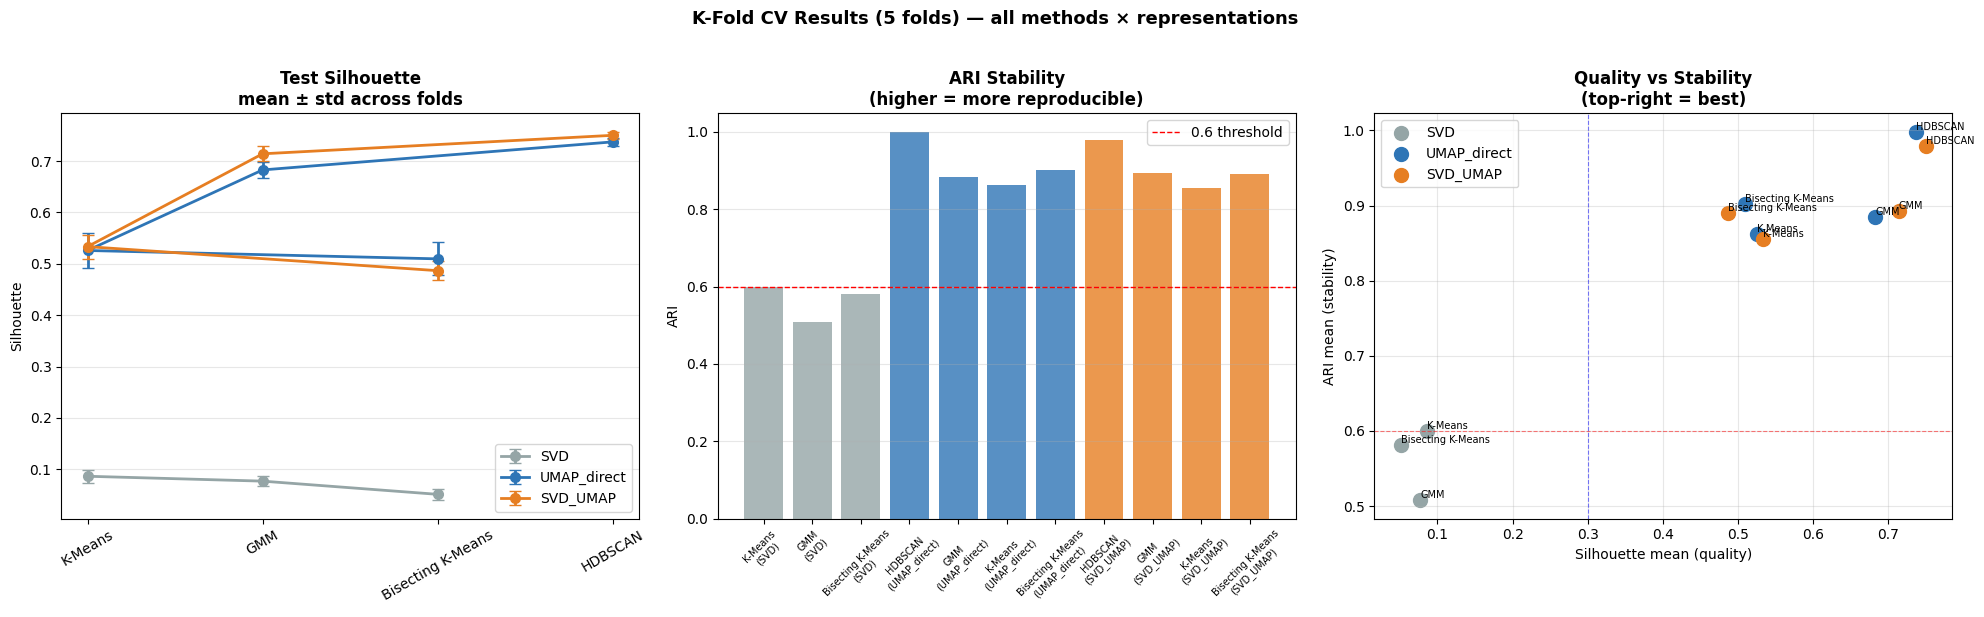


════════════════════════════════════════════════════════════
BEST OVERALL (by Silhouette mean)
════════════════════════════════════════════════════════════
  Representation: SVD_UMAP
  Method:         D — HDBSCAN
  Best params:    mcs=20, ms=10
  Silhouette:     0.7501 ± 0.0073
  ARI stability:  0.9791 ± 0.0209

Update METHOD_FINAL and K_FINAL in your config
then run the Final Clustering cell

────────────────────────────────────────────────────────────
INTERPRETATION GUIDE
────────────────────────────────────────────────────────────
  Sil std  < 0.02  → metric stable across folds
  ARI      > 0.60  → cluster structure reproducible
  ARI      < 0.30  → unstable, consider simpler model
  Scatter top-right corner = best quality + stability


In [25]:

# RESULTS: best params + stability (ARI) + comparison table


best_params = {}   # {rep: {method: best_k or (mcs, ms)}}
summary_rows = []

METHOD_NAMES = [
    'A — K-Means',
    'B — Bisecting K-Means',
    'C — GMM',
    'D — HDBSCAN'
]

for rep_name in ['SVD', 'UMAP_direct', 'SVD_UMAP']:
    best_params[rep_name] = {}

    for method_name in METHOD_NAMES:
        if method_name not in cv_all.get(rep_name, {}):
            continue

        data = cv_all[rep_name][method_name]

        if method_name == 'D — HDBSCAN':
            # Keys are 'mcs_ms' strings
            means = {k: np.nanmean(v) for k, v in data.items()
                     if not all(np.isnan(v))}
            if not means:
                continue
            best_key  = max(means, key=means.get)
            best_mcs, best_ms = int(best_key.split('_')[0]), int(best_key.split('_')[1])
            best_sils = data[best_key]
            best_params[rep_name][method_name] = (best_mcs, best_ms)
            param_str = f'mcs={best_mcs}, ms={best_ms}'
        else:
            # Keys are K values (stored as strings after JSON round-trip)
            means = {k: np.nanmean(v) for k, v in data.items()
                    if not all(np.isnan(v))}
            if not means:
                continue
            best_k_str = max(means, key=means.get) 
            best_k     = int(best_k_str)            
            best_sils  = data[best_k_str]           
            best_params[rep_name][method_name] = best_k
            param_str = f'K={best_k}'


        valid_sils = [s for s in best_sils if not np.isnan(s)]
        sil_mean   = np.mean(valid_sils)   if valid_sils else np.nan
        sil_std    = np.std(valid_sils)    if valid_sils else np.nan

        summary_rows.append({
            'Representation': rep_name,
            'Method':         method_name,
            'Best params':    param_str,
            'Sil mean':       round(sil_mean, 4),
            'Sil std':        round(sil_std,  4),
            'Valid folds':    len(valid_sils)
        })

df_cv_summary = (pd.DataFrame(summary_rows)
                   .sort_values('Sil mean', ascending=False)
                   .reset_index(drop=True))
df_cv_summary.index += 1

print('═'*80)
print('CV RESULTS — Best params per method × representation')
print('Metric: mean test silhouette across 5 folds')
print('═'*80)
print(df_cv_summary.to_string())

# ARI stability with best params
print('\n\nComputing ARI stability with best params...')
ari_rows = []

for rep_name in ['SVD', 'UMAP_direct', 'SVD_UMAP']:
    for method_name, params in best_params[rep_name].items():

        fold_label_sets = []

        for fold_i in range(N_FOLDS):
            X_tr = umap_folds[rep_name]['train'][fold_i]
            tr_idx = umap_folds[rep_name]['train_idx'][fold_i]

            try:
                if method_name == 'A — K-Means':
                    labels = KMeans(n_clusters=params, random_state=RANDOM_STATE,
                                    n_init=10, max_iter=300).fit_predict(X_tr)
                elif method_name == 'B — Bisecting K-Means':
                    labels = BisectingKMeans(n_clusters=params,
                                             random_state=RANDOM_STATE,
                                             n_init=5).fit_predict(X_tr)
                elif method_name == 'C — GMM':
                    # Cap K so each component has ≥20 training samples
                    gmm_k = min(int(params), max(5, len(X_tr) // 20))
                    gmm = GaussianMixture(n_components=gmm_k,
                                          random_state=RANDOM_STATE,
                                          covariance_type='diag',
                                          max_iter=300, n_init=3,
                                          reg_covar=1e-4)
                    with np.errstate(under='ignore'):
                        labels = gmm.fit_predict(X_tr)
                elif method_name == 'D — HDBSCAN':
                    mcs, ms = params
                    labels  = hdbscan_lib.HDBSCAN(
                        min_cluster_size=mcs, min_samples=ms,
                        metric='euclidean', cluster_selection_method='eom'
                    ).fit_predict(X_tr)

                fold_label_sets.append((np.array(tr_idx), np.array(labels)))
            except Exception as _e:
                if method_name == 'C — GMM':
                    print(f'  GMM fold {fold_i} FAILED: {type(_e).__name__}: {_e}')
                continue

        # ARI between consecutive fold pairs on shared users
        ari_scores = []
        for i in range(len(fold_label_sets) - 1):
            idx_a, lbl_a = fold_label_sets[i]
            idx_b, lbl_b = fold_label_sets[i + 1]
            shared = np.intersect1d(idx_a, idx_b)
            if len(shared) < 10:
                continue
            pos_a = np.where(np.isin(idx_a, shared))[0]
            pos_b = np.where(np.isin(idx_b, shared))[0]
            la    = lbl_a[pos_a]
            lb    = lbl_b[pos_b]
            valid = (la != -1) & (lb != -1)
            if valid.sum() < 10:
                continue
            ari_scores.append(adjusted_rand_score(la[valid], lb[valid]))

        ari_rows.append({
            'Representation': rep_name,
            'Method':         method_name,
            'ARI mean':       round(np.mean(ari_scores), 4) if ari_scores else np.nan,
            'ARI std':        round(np.std(ari_scores),  4) if ari_scores else np.nan,
        })

df_ari = pd.DataFrame(ari_rows)

# Merge into summary
df_final = df_cv_summary.merge(df_ari, on=['Representation', 'Method'], how='left')
df_final = df_final.sort_values('Sil mean', ascending=False).reset_index(drop=True)
df_final.index += 1

print('\n' + '═'*90)
print('FINAL CV TABLE — Silhouette + ARI stability')
print('Higher Sil = better separation | Higher ARI = more stable clusters')
print('═'*90)
print(df_final.to_string())

#Plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
rep_colors = {'SVD': '#95A5A6', 'UMAP_direct': '#2E75B6', 'SVD_UMAP': '#E67E22'}

for rep_name, color in rep_colors.items():
    sub = df_final[df_final['Representation'] == rep_name]
    if sub.empty:
        continue
    method_labels = sub['Method'].str.split('—').str[1].str.strip()

    axes[0].errorbar(method_labels, sub['Sil mean'], yerr=sub['Sil std'],
                     fmt='o-', color=color, label=rep_name,
                     capsize=4, linewidth=2, markersize=7)
    axes[1].bar(
        [f'{m}\n({rep_name})' for m in method_labels],
        sub['ARI mean'], color=color, alpha=0.8
    )
    axes[2].scatter(sub['Sil mean'], sub['ARI mean'],
                    color=color, s=100, label=rep_name)
    for _, row in sub.iterrows():
        axes[2].annotate(
            row['Method'].split('—')[1].strip(),
            (row['Sil mean'], row['ARI mean']),
            fontsize=7, ha='left', va='bottom'
        )

axes[0].set_title('Test Silhouette\nmean ± std across folds', fontweight='bold')
axes[0].set_ylabel('Silhouette')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].set_title('ARI Stability\n(higher = more reproducible)', fontweight='bold')
axes[1].set_ylabel('ARI')
axes[1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1].axhline(0.6, color='red', linestyle='--', linewidth=1, label='0.6 threshold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

axes[2].set_title('Quality vs Stability\n(top-right = best)', fontweight='bold')
axes[2].set_xlabel('Silhouette mean (quality)')
axes[2].set_ylabel('ARI mean (stability)')
axes[2].legend()
axes[2].axhline(0.6, color='red',  linestyle='--', linewidth=0.8, alpha=0.5)
axes[2].axvline(0.3, color='blue', linestyle='--', linewidth=0.8, alpha=0.5)
axes[2].grid(alpha=0.3)

plt.suptitle(f'K-Fold CV Results ({N_FOLDS} folds) — all methods × representations',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Print best overall
print('\n' + '═'*60)
print('BEST OVERALL (by Silhouette mean)')
print('═'*60)
best = df_final.iloc[0]
print(f'  Representation: {best["Representation"]}')
print(f'  Method:         {best["Method"]}')
print(f'  Best params:    {best["Best params"]}')
print(f'  Silhouette:     {best["Sil mean"]:.4f} ± {best["Sil std"]:.4f}')
print(f'  ARI stability:  {best["ARI mean"]:.4f} ± {best["ARI std"]:.4f}')
print(f'\nUpdate METHOD_FINAL and K_FINAL in your config')
print(f'then run the Final Clustering cell')

# Interpretation guide 
print('\n' + '─'*60)
print('INTERPRETATION GUIDE')
print('─'*60)
print('  Sil std  < 0.02  → metric stable across folds')
print('  ARI      > 0.60  → cluster structure reproducible')
print('  ARI      < 0.30  → unstable, consider simpler model')
print('  Scatter top-right corner = best quality + stability')

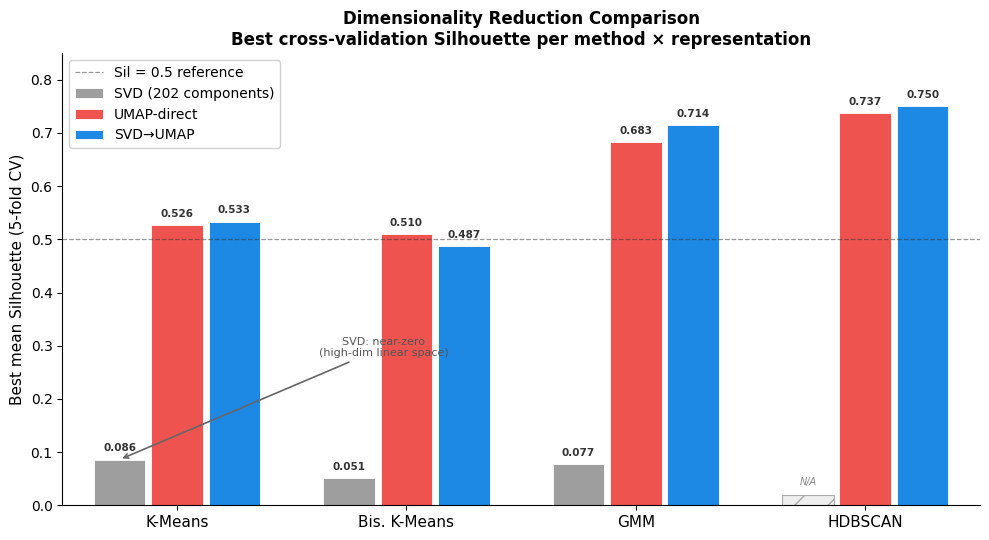

Saved figs/figNEW_repr_comparison_3bar.png


In [26]:
# FIG: Dimensionality Reduction — 3-representation Silhouette comparison
# SVD vs UMAP-direct vs SVD→UMAP — best CV Silhouette per method


methods  = ['K-Means', 'Bis. K-Means', 'GMM', 'HDBSCAN']

# Best mean Silhouette from 5-fold CV (cell 40)
sil_svd        = [0.086,  0.051,  0.077,  None]   # HDBSCAN not evaluated on raw SVD
sil_umap_direct= [0.526,  0.510,  0.683,  0.737]
sil_svd_umap   = [0.533,  0.487,  0.714,  0.750]

repr_data = {
    'SVD (202 components)': (sil_svd,        '#9E9E9E'),
    'UMAP-direct':           (sil_umap_direct,'#EF5350'),
    'SVD→UMAP':              (sil_svd_umap,   '#1E88E5'),
}

x      = np.arange(len(methods))
width  = 0.25
offs   = [-width, 0, width]

fig, ax = plt.subplots(figsize=(10, 5.5))

for i, (label, (vals, col)) in enumerate(repr_data.items()):
    for j, v in enumerate(vals):
        if v is not None:
            ax.bar(x[j]+offs[i], v, width=width*0.9, color=col,
                   edgecolor='white', linewidth=0.6,
                   label=label if j==0 else "")
            ax.text(x[j]+offs[i], v+0.012, f'{v:.3f}',
                    ha='center', va='bottom', fontsize=7.5,
                    fontweight='bold', color='#333')
        else:
            ax.bar(x[j]+offs[i], 0.02, width=width*0.9,
                   color='#EEE', edgecolor='#AAA', linewidth=0.8, hatch='/')
            ax.text(x[j]+offs[i], 0.035, 'N/A',
                    ha='center', va='bottom', fontsize=7,
                    color='#888', style='italic')

ax.axhline(0.5, color='#333', linestyle='--', linewidth=0.9,
           alpha=0.5, label='Sil = 0.5 reference')

ax.annotate('SVD: near-zero\n(high-dim linear space)',
            xy=(x[0]+offs[0], 0.086), xytext=(0.9, 0.28),
            arrowprops=dict(arrowstyle='->', color='#666', lw=1.2),
            fontsize=8, color='#555', ha='center')

ax.set_xticks(x); ax.set_xticklabels(methods, fontsize=11)
ax.set_ylabel('Best mean Silhouette (5-fold CV)', fontsize=11)
ax.set_title('Dimensionality Reduction Comparison\n'
             'Best cross-validation Silhouette per method × representation',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 0.85)
ax.set_xlim(-0.5, len(methods)-0.5)
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figs/figNEW_repr_comparison_3bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/figNEW_repr_comparison_3bar.png')

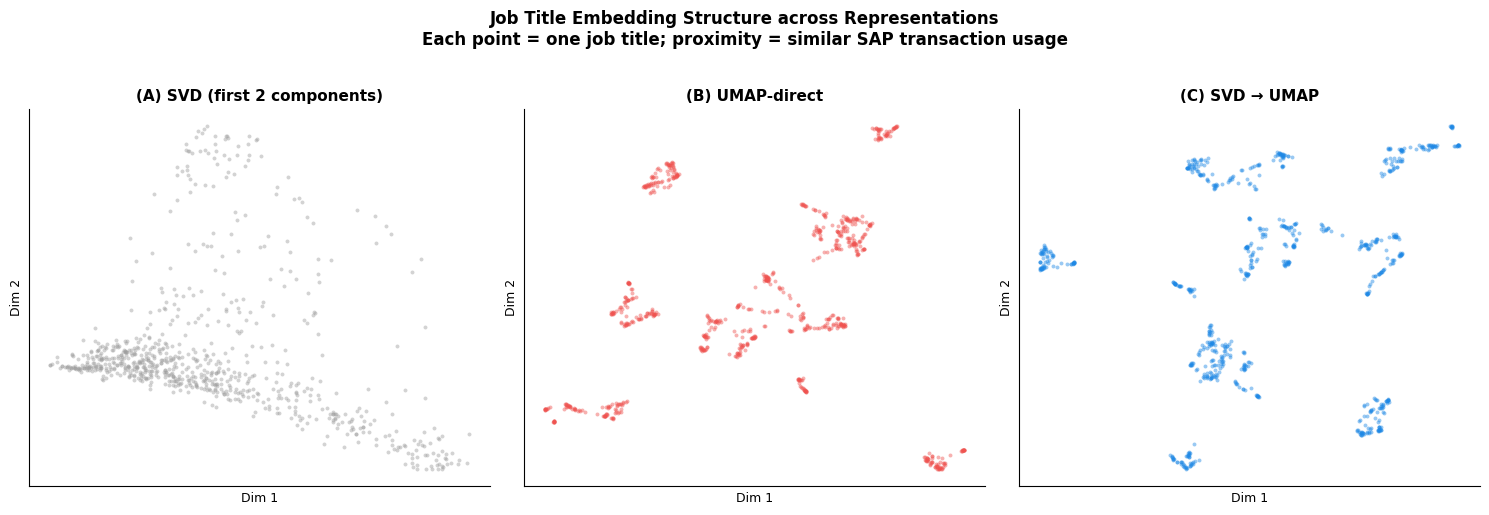

Saved figs/figNEW_dimred_scatter3.png


In [27]:
# FIG: Dimensionality Reduction — 2D scatter tripanel
# SVD (first 2 components) | UMAP-direct 2D | SVD→UMAP 2D


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

panels = [
    (X_svd[:, :2],        '#9E9E9E', '(A) SVD (first 2 components)'),
    (X_umap_direct_2d,    '#EF5350', '(B) UMAP-direct'),
    (X_umap_on_svd_2d,    '#1E88E5', '(C) SVD → UMAP'),
]

for ax, (X2d, col, title) in zip(axes, panels):
    ax.scatter(X2d[:, 0], X2d[:, 1],
               c=col, alpha=0.45, s=8, linewidths=0)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Dim 1', fontsize=9)
    ax.set_ylabel('Dim 2', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Job Title Embedding Structure across Representations\n'
             'Each point = one job title; proximity = similar SAP transaction usage',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figs/figNEW_dimred_scatter3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/figNEW_dimred_scatter3.png')


### 5.1.2 Results of the best method

════════════════════════════════════════════════════════════
FINAL CLUSTERING
  Representation:    SVD_UMAP
  Method:            HDBSCAN
  min_cluster_size:  20
  min_samples:       10
════════════════════════════════════════════════════════════

HDBSCAN results:
  Clusters found:  10
  Outliers (-1):   9 (1.1%)

Reassigning 9 outliers to nearest centroid...
  9 outliers reassigned

Reassigning 70 sparse job titles...
  70 sparse job titles assigned

────────────────────────────────────────────────────────────
FINAL CLUSTERING SUMMARY
────────────────────────────────────────────────────────────
  Total job titles:        866
  Clusters:                10
  Normal assignments:      796
  Outlier reassigned:      0
  Sparse reassigned:       70
  Cluster size — mean:     86.6
  Cluster size — min:      36
  Cluster size — max:      176
  Small clusters (<10):    0


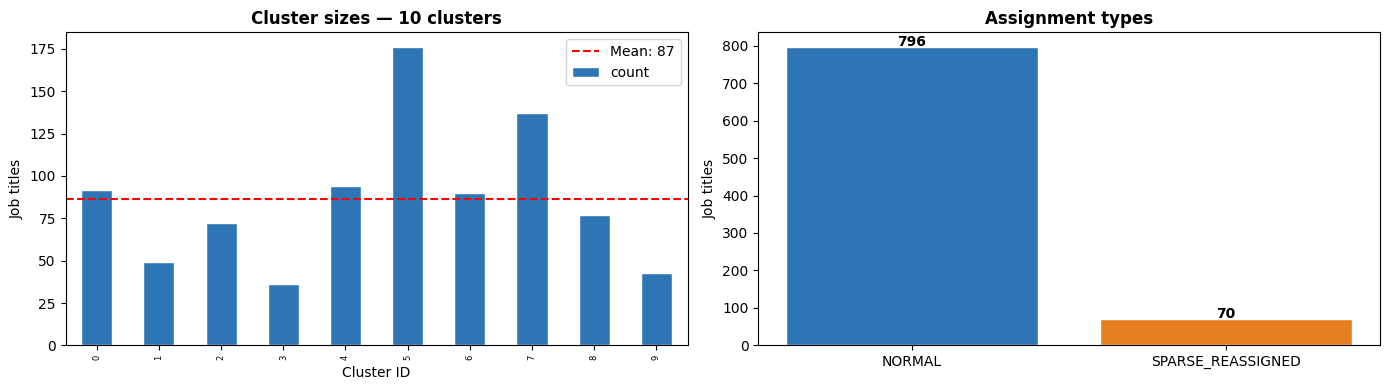

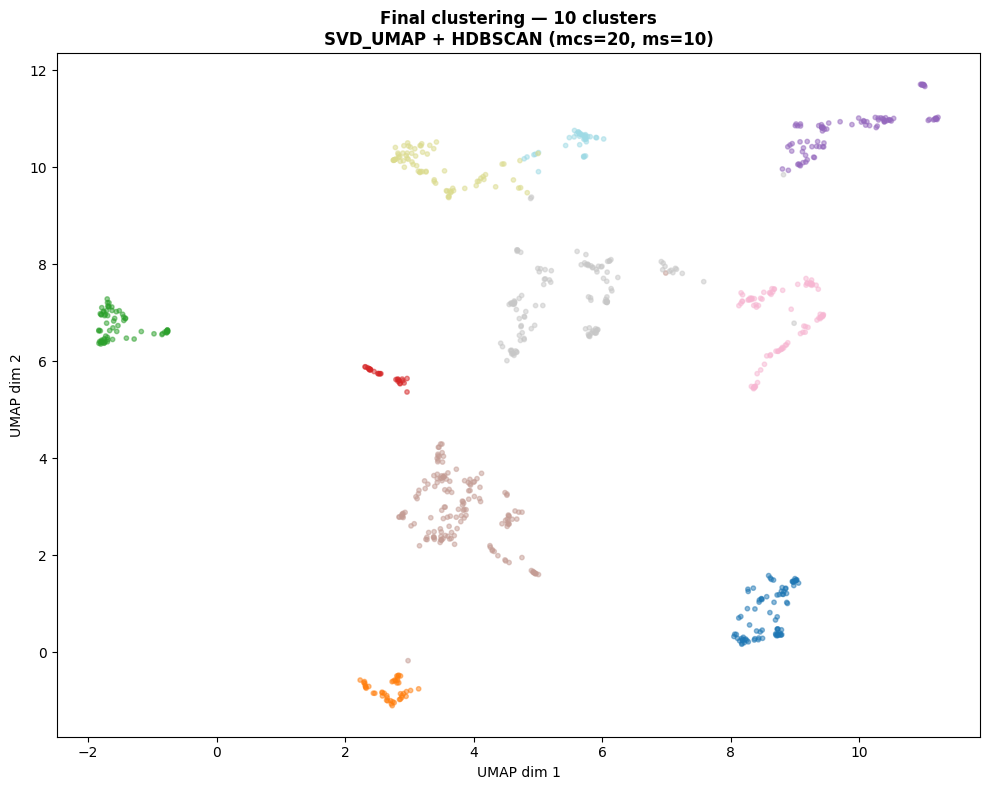


df_clustered: 866 job titles × 6 columns
Columns: ['JOB_TITLE', 'CLUSTER_ID', 'HDBSCAN_PROB', 'N_USERS', 'BUSINESS PROCESS', 'ASSIGNMENT_TYPE']


In [28]:
# FINAL non overlapping CLUSTERING - HDBSCAN
# Best params from CV: SVD_UMAP, mcs=20, ms=10


HDBSCAN_MIN_CLUSTER_SIZE = 20
HDBSCAN_MIN_SAMPLES      = 10
REPRESENTATION_FINAL     = 'SVD_UMAP'

print('═'*60)
print('FINAL CLUSTERING')
print(f'  Representation:    {REPRESENTATION_FINAL}')
print(f'  Method:            HDBSCAN')
print(f'  min_cluster_size:  {HDBSCAN_MIN_CLUSTER_SIZE}')
print(f'  min_samples:       {HDBSCAN_MIN_SAMPLES}')
print('═'*60)

X_final = X_umap_on_svd_norm

# Step 1: run HDBSCAN 
hdb_final = hdbscan_lib.HDBSCAN(
    min_cluster_size         = HDBSCAN_MIN_CLUSTER_SIZE,
    min_samples              = HDBSCAN_MIN_SAMPLES,
    metric                   = 'euclidean',
    cluster_selection_method = 'eom'
)
cluster_labels = hdb_final.fit_predict(X_final)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_outliers = int((cluster_labels == -1).sum())

print(f'\nHDBSCAN results:')
print(f'  Clusters found:  {n_clusters}')
print(f'  Outliers (-1):   {n_outliers} ({n_outliers/len(cluster_labels):.1%})')

# Step 2: reassign outliers to nearest centroid
if n_outliers > 0:
    print(f'\nReassigning {n_outliers} outliers to nearest centroid...')
    valid_mask      = cluster_labels != -1
    unique_clusters = np.unique(cluster_labels[valid_mask])
    centroids       = np.array([
        X_final[cluster_labels == c].mean(axis=0)
        for c in unique_clusters
    ])
    outlier_idx            = np.where(~valid_mask)[0]
    dists                  = cosine_distances(X_final[outlier_idx], centroids)
    nearest                = unique_clusters[dists.argmin(axis=1)]
    cluster_labels[outlier_idx] = nearest
    print(f'  {n_outliers} outliers reassigned')

# Step 3: reassign sparse job titles
if len(sparse_jt) > 0:
    print(f'\nReassigning {len(sparse_jt)} sparse job titles...')

    # Transform sparse job titles through the same pipeline as training
    sparse_raw   = matrix_clean.loc[matrix_clean.index.isin(sparse_jt)]
    sparse_tfidf = tfidf.transform(csr_matrix(sparse_raw.values.astype(float)))

    # SVD_UMAP: project through SVD, assign via nearest centroid in SVD space
    sparse_svd = normalize(svd.transform(sparse_tfidf), norm='l2')
    X_svd_train = normalize(svd.transform(X_tfidf), norm='l2')

    unique_clusters_final = np.unique(cluster_labels)
    svd_centroids = np.array([
        X_svd_train[cluster_labels == c].mean(axis=0)
        for c in unique_clusters_final
    ])
    dists_sparse    = cosine_distances(sparse_svd, svd_centroids)
    sparse_assigned = unique_clusters_final[dists_sparse.argmin(axis=1)]

    print(f'  {len(sparse_jt)} sparse job titles assigned')

    all_jts    = list(matrix_train_log.index) + list(sparse_jt)
    all_labels = list(cluster_labels) + list(sparse_assigned)
    all_probs  = list(hdb_final.probabilities_) + [0.5] * len(sparse_jt)
else:
    all_jts    = list(matrix_train_log.index)
    all_labels = list(cluster_labels)
    all_probs  = list(hdb_final.probabilities_)

# Step 4: build df_clustered
df_clustered = pd.DataFrame({
    'JOB_TITLE':   all_jts,
    'CLUSTER_ID':  all_labels,
    'HDBSCAN_PROB': all_probs
})

df_clustered = df_clustered.merge(
    df_jt_metadata[['JOB_TITLE', 'N_USERS', 'BUSINESS PROCESS']],
    on='JOB_TITLE', how='left'
)

df_clustered['ASSIGNMENT_TYPE'] = 'NORMAL'
df_clustered.loc[
    df_clustered['JOB_TITLE'].isin(
        list(matrix_train_log.index[hdb_final.labels_ == -1])
    ),
    'ASSIGNMENT_TYPE'
] = 'OUTLIER_REASSIGNED'
df_clustered.loc[
    df_clustered['JOB_TITLE'].isin(sparse_jt),
    'ASSIGNMENT_TYPE'
] = 'SPARSE_REASSIGNED'

# Step 5: summary 
K_FINAL_ACTUAL = df_clustered['CLUSTER_ID'].nunique()
cluster_sizes  = df_clustered['CLUSTER_ID'].value_counts().sort_index()

print(f'\n{"─"*60}')
print(f'FINAL CLUSTERING SUMMARY')
print(f'{"─"*60}')
print(f'  Total job titles:        {len(df_clustered):,}')
print(f'  Clusters:                {K_FINAL_ACTUAL}')
print(f'  Normal assignments:      {(df_clustered["ASSIGNMENT_TYPE"] == "NORMAL").sum():,}')
print(f'  Outlier reassigned:      {(df_clustered["ASSIGNMENT_TYPE"] == "OUTLIER_REASSIGNED").sum():,}')
print(f'  Sparse reassigned:       {(df_clustered["ASSIGNMENT_TYPE"] == "SPARSE_REASSIGNED").sum():,}')
print(f'  Cluster size — mean:     {cluster_sizes.mean():.1f}')
print(f'  Cluster size — min:      {cluster_sizes.min()}')
print(f'  Cluster size — max:      {cluster_sizes.max()}')
print(f'  Small clusters (<10):    {(cluster_sizes < 10).sum()}')

# Step 6: plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

cluster_sizes.plot(kind='bar', ax=axes[0], color='#2E75B6', edgecolor='white')
axes[0].axhline(cluster_sizes.mean(), color='red', linestyle='--',
                label=f'Mean: {cluster_sizes.mean():.0f}')
axes[0].set_title(f'Cluster sizes — {K_FINAL_ACTUAL} clusters', fontweight='bold')
axes[0].set_xlabel('Cluster ID')
axes[0].set_ylabel('Job titles')
axes[0].legend()
axes[0].tick_params(axis='x', labelsize=6)

type_counts = df_clustered['ASSIGNMENT_TYPE'].value_counts()
axes[1].bar(type_counts.index, type_counts.values,
            color=['#2E75B6', '#E67E22', '#27AE60'], edgecolor='white')
axes[1].set_title('Assignment types', fontweight='bold')
axes[1].set_ylabel('Job titles')
for bar, val in zip(axes[1].patches, type_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2,
                 str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Step 7: 2D UMAP plot coloured by cluster
train_jts    = list(matrix_train_log.index)
df_train_plt = df_clustered[df_clustered['JOB_TITLE'].isin(train_jts)].copy()
df_train_plt = df_train_plt.set_index('JOB_TITLE').loc[train_jts].reset_index()
labels_plot  = df_train_plt['CLUSTER_ID'].values

unique_lbl   = np.unique(labels_plot)
palette      = plt.cm.tab20(np.linspace(0, 1, max(len(unique_lbl), 1)))
cmap_plot    = {c: palette[i % len(palette)] for i, c in enumerate(unique_lbl)}
point_colors = [cmap_plot[l] for l in labels_plot]

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_umap_on_svd_2d[:len(train_jts), 0],
           X_umap_on_svd_2d[:len(train_jts), 1],
           c=point_colors, alpha=0.5, s=10)
ax.set_title(f'Final clustering — {K_FINAL_ACTUAL} clusters\n'
             f'SVD_UMAP + HDBSCAN (mcs={HDBSCAN_MIN_CLUSTER_SIZE}, '
             f'ms={HDBSCAN_MIN_SAMPLES})',
             fontweight='bold')
ax.set_xlabel('UMAP dim 1')
ax.set_ylabel('UMAP dim 2')
plt.tight_layout()
plt.show()

print(f'\ndf_clustered: {len(df_clustered):,} job titles × {df_clustered.shape[1]} columns')
print(f'Columns: {list(df_clustered.columns)}')

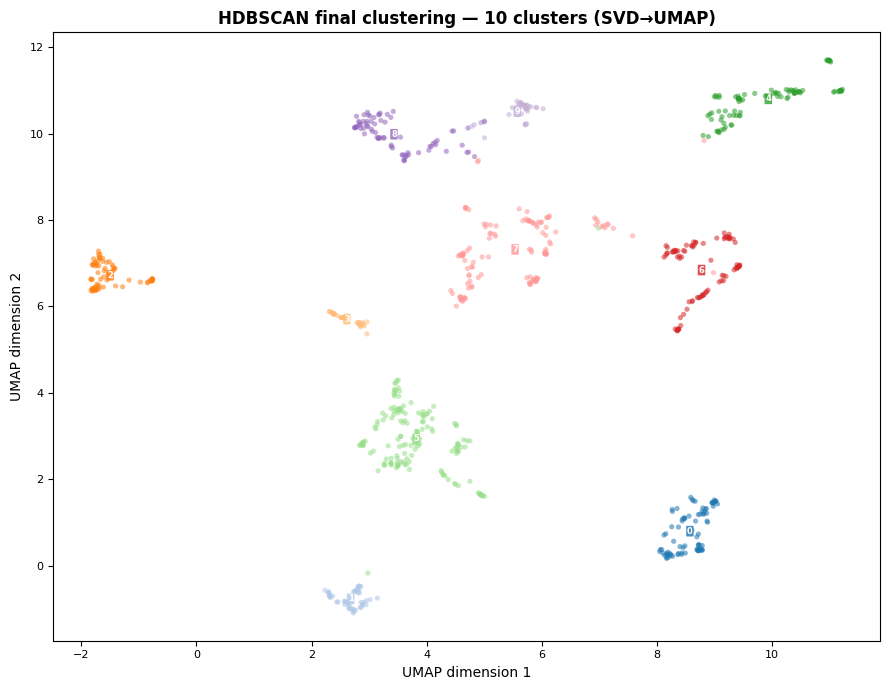

Saved figs/fig53_hdbscan_umap.png


In [29]:
# Depends on: cell 44 (cluster_labels, X_umap_on_svd_2d, df_clustered)


train_jts   = list(matrix_train_log.index)
n_train     = len(train_jts)
lbl_plot    = cluster_labels          # shape (n_train,)
X2d         = X_umap_on_svd_2d[:n_train]

unique_cl   = np.unique(lbl_plot)
K_hdb       = len(unique_cl)

# Colour palette — tab20 repeated if K > 20
np.random.seed(0)
cmap20      = plt.cm.get_cmap('tab20', 20)
colors      = [cmap20(i % 20) for i in range(K_hdb)]
color_map   = {c: colors[i] for i, c in enumerate(unique_cl)}
pt_colors   = [color_map[l] for l in lbl_plot]

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X2d[:, 0], X2d[:, 1],
           c=pt_colors, alpha=0.55, s=14, linewidths=0)

# Cluster ID labels at centroid
for c in unique_cl:
    mask = lbl_plot == c
    cx, cy = X2d[mask, 0].mean(), X2d[mask, 1].mean()
    ax.text(cx, cy, str(c), fontsize=6, ha='center', va='center',
            fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.1', fc=color_map[c], ec='none', alpha=0.8))

ax.set_title(f'HDBSCAN final clustering — {K_hdb} clusters (SVD→UMAP)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('UMAP dimension 1', fontsize=10)
ax.set_ylabel('UMAP dimension 2', fontsize=10)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig('figs/fig53_hdbscan_umap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/fig53_hdbscan_umap.png')


  K=  5  BIC=-87792.5
  K= 10  BIC=-101612.2
  K= 15  BIC=-103404.4
  K= 20  BIC=-103297.5
  K= 25  BIC=-102427.8
  K= 30  BIC=-101435.4
  K= 35  BIC=-100322.7
  K= 40  BIC=-99062.3
  K= 45  BIC=-97702.8
  K= 50  BIC=-96352.6
  K= 55  BIC=-94994.5
  K= 60  BIC=-93629.7

  Best K by BIC: 15


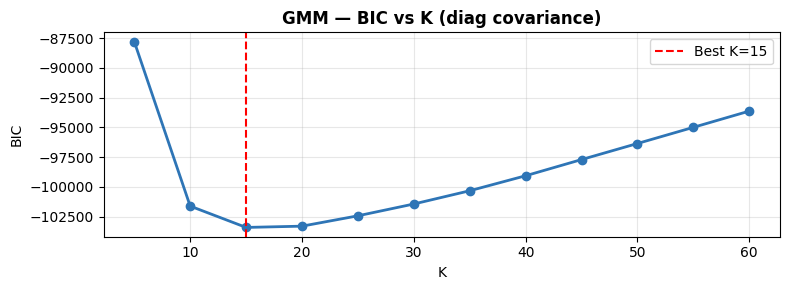

════════════════════════════════════════════════════════════
GMM — Final clustering  K=15  covariance=diag
════════════════════════════════════════════════════════════

Reassigning 70 sparse job titles...
  70 sparse job titles assigned

GMM Final Results:
  Clusters (BIC-selected K): 15
  Silhouette:                0.6302
  Cluster size mean:         57.7
  Cluster size min:          30
  Cluster size max:          92


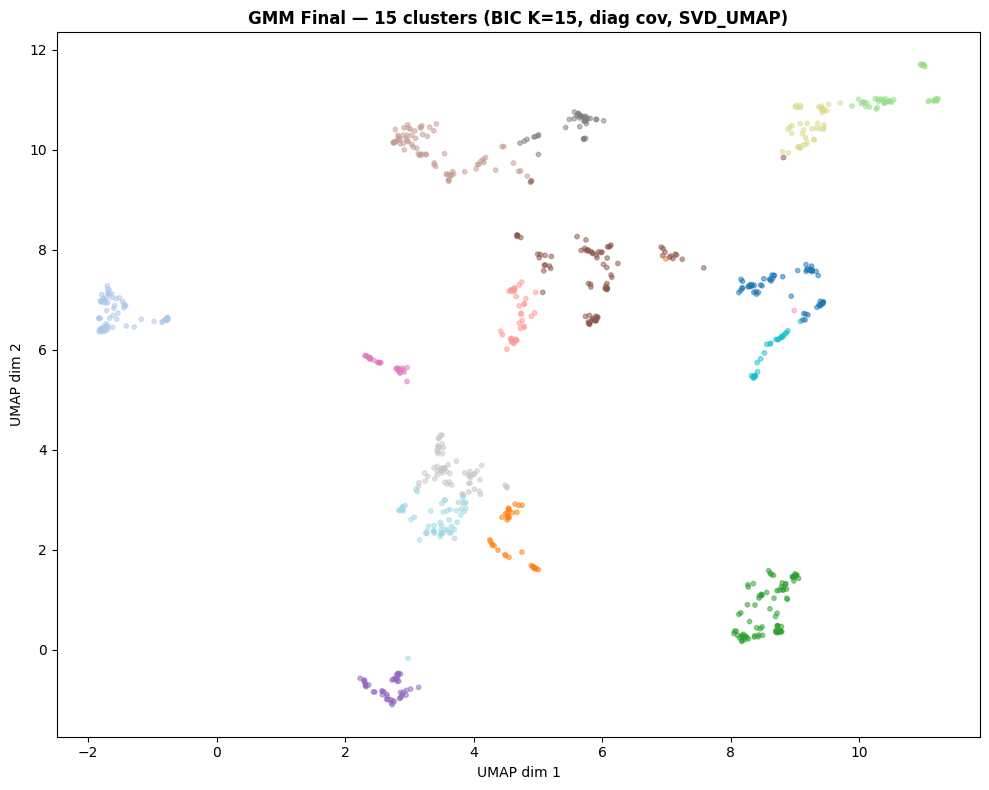


df_gmm: (866, 4)
                    JOB_TITLE  CLUSTER_ID  N_USERS       BUSINESS PROCESS
0           Account Assistant           0        9  FINANCE & CONTROLLING
1     Account Payable Analyst           4        2  FINANCE & CONTROLLING
2  Account Receivable Officer           0        1  FINANCE & CONTROLLING
3         Account Receivables           0        2  FINANCE & CONTROLLING
4                  Accountant           4        2  FINANCE & CONTROLLING


In [30]:
# GMM — Final clustering
# covariance_type='diag' — consistent with CV (cells above).
# Full covariance is infeasible with 20-dim UMAP + limited job titles
# (singular covariance matrices). Diag still captures per-dimension variance.
# K selected by BIC (lower = better fit-to-complexity tradeoff)


# Step 1: BIC-based K selection

K_RANGE_GMM = range(5, 61, 5)
bic_scores  = []

for k in K_RANGE_GMM:
    try:
        gmm_k = GaussianMixture(
            n_components    = k,
            random_state    = RANDOM_STATE,
            covariance_type = 'diag',
            max_iter        = 200,
            n_init          = 3,
            reg_covar       = 1e-4
        )
        with np.errstate(under='ignore'):
            gmm_k.fit(X_umap_on_svd_norm)
            bic = gmm_k.bic(X_umap_on_svd_norm)
        bic_scores.append({'K': k, 'BIC': bic})
        print(f'  K={k:3d}  BIC={bic:.1f}')
    except Exception as e:
        print(f'  K={k:3d}  failed: {e}')

df_bic = pd.DataFrame(bic_scores)
if df_bic.empty:
    raise RuntimeError('All GMM fits failed — check printed errors above. '
                       'Most likely cause: too few samples for selected K range.')
GMM_K_FINAL = int(df_bic.loc[df_bic['BIC'].idxmin(), 'K'])
print(f'\n  Best K by BIC: {GMM_K_FINAL}')

# BIC plot
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(df_bic['K'], df_bic['BIC'], 'o-', color='#2E75B6', linewidth=2)
ax.axvline(GMM_K_FINAL, color='red', linestyle='--', label=f'Best K={GMM_K_FINAL}')
ax.set_title('GMM — BIC vs K (diag covariance)', fontweight='bold')
ax.set_xlabel('K'); ax.set_ylabel('BIC'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Step 2: Final fit
print('═'*60)
print(f'GMM — Final clustering  K={GMM_K_FINAL}  covariance=diag')
print('═'*60)

gmm_final = GaussianMixture(
    n_components    = GMM_K_FINAL,
    random_state    = RANDOM_STATE,
    covariance_type = 'diag',
    max_iter        = 300,
    n_init          = 5,
    reg_covar       = 1e-4
)
with np.errstate(under='ignore'):
    gmm_final.fit(X_umap_on_svd_norm)
labels_gmm_final = gmm_final.predict(X_umap_on_svd_norm)

# Sparse job titles (same pipeline, no log1p)
if len(sparse_jt) > 0:
    print(f'\nReassigning {len(sparse_jt)} sparse job titles...')
    sparse_raw   = matrix_clean.loc[matrix_clean.index.isin(sparse_jt)]
    sparse_tfidf = tfidf.transform(csr_matrix(sparse_raw.values.astype(float)))
    # SVD_UMAP: project through SVD, assign via nearest centroid in SVD space
    sparse_svd = normalize(svd.transform(sparse_tfidf), norm='l2')
    X_svd_train = normalize(svd.transform(X_tfidf), norm='l2')
    svd_centroids_gmm = np.array([
        X_svd_train[labels_gmm_final == c].mean(axis=0)
        for c in np.unique(labels_gmm_final)
    ])
    dists_gmm = cosine_distances(sparse_svd, svd_centroids_gmm)
    sparse_labels = np.unique(labels_gmm_final)[dists_gmm.argmin(axis=1)]
    print(f'  {len(sparse_jt)} sparse job titles assigned')

    all_jts    = list(matrix_train_log.index) + list(sparse_jt)
    all_labels = list(labels_gmm_final) + list(sparse_labels)
else:
    all_jts    = list(matrix_train_log.index)
    all_labels = list(labels_gmm_final)

# Build df_gmm
df_gmm = pd.DataFrame({'JOB_TITLE': all_jts, 'CLUSTER_ID': all_labels})
df_gmm = df_gmm.merge(
    df_jt_metadata[['JOB_TITLE', 'N_USERS', 'BUSINESS PROCESS']],
    on='JOB_TITLE', how='left'
)

K_GMM_ACTUAL  = df_gmm['CLUSTER_ID'].nunique()
cluster_sizes = df_gmm['CLUSTER_ID'].value_counts().sort_index()
sil_gmm = float(silhouette_score(X_umap_on_svd_norm, labels_gmm_final))

print(f'\nGMM Final Results:')
print(f'  Clusters (BIC-selected K): {K_GMM_ACTUAL}')
print(f'  Silhouette:                {sil_gmm:.4f}')
print(f'  Cluster size mean:         {cluster_sizes.mean():.1f}')
print(f'  Cluster size min:          {cluster_sizes.min()}')
print(f'  Cluster size max:          {cluster_sizes.max()}')

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
unique_lbl   = np.unique(labels_gmm_final)
palette      = plt.cm.tab20(np.linspace(0, 1, max(len(unique_lbl), 1)))
cmap_plot    = {c: palette[i % len(palette)] for i, c in enumerate(unique_lbl)}
point_colors = [cmap_plot[l] for l in labels_gmm_final]
ax.scatter(X_umap_on_svd_2d[:len(matrix_train_log), 0],
           X_umap_on_svd_2d[:len(matrix_train_log), 1],
           c=point_colors, alpha=0.5, s=10)
ax.set_title(f'GMM Final — {K_GMM_ACTUAL} clusters (BIC K={GMM_K_FINAL}, diag cov, SVD_UMAP)',
             fontweight='bold')
ax.set_xlabel('UMAP dim 1'); ax.set_ylabel('UMAP dim 2')
plt.tight_layout(); plt.show()

print(f'\ndf_gmm: {df_gmm.shape}')
print(df_gmm.head())


### 5.1.3 Export Results

In [31]:
# EXPORT — HDBSCAN clusters: job titles + t-codes per cluster


os.makedirs('output phase2 JT', exist_ok=True)

# TF-IDF dataframe
tfidf_dense = X_tfidf.toarray()
df_tfidf = pd.DataFrame(
    tfidf_dense,
    index   = matrix_train_log.index,
    columns = matrix_train_log.columns
)

# Columnas comunes
common_tcodes = usage_matrix.columns.intersection(df_tfidf.columns)

# BP map
bp_map = df_jt_metadata.set_index('JOB_TITLE')['BUSINESS PROCESS'].to_dict()

output_rows = []

for cluster_id in sorted(df_clustered['CLUSTER_ID'].unique()):

    # Job titles en este cluster 
    jts_in_cluster = df_clustered[
        df_clustered['CLUSTER_ID'] == cluster_id
    ]['JOB_TITLE'].tolist()

    for jt in jts_in_cluster:
        row_data = df_clustered[df_clustered['JOB_TITLE'] == jt].iloc[0]
        n_users  = int(row_data['N_USERS']) if pd.notna(row_data['N_USERS']) else 0

        output_rows.append({
            'CLUSTER_ID':        cluster_id,
            'TYPE':              'JOB_TITLE',
            'NAME':              jt,
            'BUSINESS_PROCESS':  bp_map.get(jt, ''),
            'N_USERS':           n_users,
            'HDBSCAN_PROB':      round(float(row_data['HDBSCAN_PROB']), 4),
            'ASSIGNMENT_TYPE':   row_data['ASSIGNMENT_TYPE'],
            'PCT_JT_USING':      '',
            'AVG_FREQ':          '',
            'TFIDF_WEIGHT':      '',
            'JT_USING':          '',
        })

    # T-codes del cluster
    jts_in_usage = [jt for jt in jts_in_cluster if jt in usage_matrix.index]
    jts_in_tfidf = [jt for jt in jts_in_cluster if jt in df_tfidf.index]
    n_jts_total  = len(jts_in_usage)

    if n_jts_total > 0:
        X_cluster    = usage_matrix.loc[jts_in_usage, common_tcodes]
        tfidf_weight = (
            df_tfidf.loc[jts_in_tfidf, common_tcodes].mean(axis=0)
            if jts_in_tfidf
            else pd.Series(0, index=common_tcodes)
        )

        pct_using = (X_cluster > 0).sum(axis=0) / n_jts_total
        avg_freq  = X_cluster.mean(axis=0)

        # Job titles que usan cada tcode
        jt_using_tcode = {
            tcode: ', '.join([
                jt for jt in jts_in_usage
                if X_cluster.loc[jt, tcode] > 0
            ])
            for tcode in common_tcodes
        }

        df_tcodes = pd.DataFrame({
            'PCT_JT_USING': pct_using,
            'AVG_FREQ':     avg_freq,
            'TFIDF_WEIGHT': tfidf_weight,
        })
        df_tcodes = df_tcodes[df_tcodes['PCT_JT_USING'] > 0]
        df_tcodes = df_tcodes.sort_values('PCT_JT_USING', ascending=False)

        for tcode, row in df_tcodes.iterrows():
            output_rows.append({
                'CLUSTER_ID':       cluster_id,
                'TYPE':             'TCODE',
                'NAME':             tcode,
                'BUSINESS_PROCESS': '',
                'N_USERS':          '',
                'HDBSCAN_PROB':     '',
                'ASSIGNMENT_TYPE':  '',
                'PCT_JT_USING':     round(row['PCT_JT_USING'], 4),
                'AVG_FREQ':         round(row['AVG_FREQ'], 2),
                'TFIDF_WEIGHT':     round(row['TFIDF_WEIGHT'], 4),
                'JT_USING':         jt_using_tcode.get(tcode, ''),
            })

# Build dataframe
df_export_hdb = pd.DataFrame(output_rows)

# Export 
export_path = 'output phase2 JT/hdbscan_clusters_export.xlsx'

with pd.ExcelWriter(export_path, engine='openpyxl') as writer:
    df_export_hdb.to_excel(writer, sheet_name='Clusters', index=False)
    ws = writer.sheets['Clusters']
    for col in ws.columns:
        max_len = max(len(str(cell.value or '')) for cell in col)
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 2, 50)

print(f'Export done: {export_path}')
print(f'Total rows:      {len(df_export_hdb):,}')
print(f'JOB_TITLE rows:  {(df_export_hdb["TYPE"] == "JOB_TITLE").sum():,}')
print(f'TCODE rows:      {(df_export_hdb["TYPE"] == "TCODE").sum():,}')
print(f'Clusters:        {df_export_hdb["CLUSTER_ID"].nunique()}')
print(f'\nSample TCODE rows:')

Export done: output phase2 JT/hdbscan_clusters_export.xlsx
Total rows:      4,975
JOB_TITLE rows:  866
TCODE rows:      4,109
Clusters:        10

Sample TCODE rows:


In [32]:
# EXPORT — GMM clusters: job titles + t-codes per cluster


os.makedirs('output phase2 JT', exist_ok=True)

# TF-IDF dataframe
tfidf_dense = X_tfidf.toarray()
df_tfidf = pd.DataFrame(
    tfidf_dense,
    index   = matrix_train_log.index,
    columns = matrix_train_log.columns
)

# Columnas comunes
common_tcodes = usage_matrix.columns.intersection(df_tfidf.columns)

# Maps
bp_map_export = df_jt_metadata.set_index('JOB_TITLE')['BUSINESS PROCESS'].to_dict()
n_users_map   = df_jt_metadata.set_index('JOB_TITLE')['N_USERS'].to_dict()

output_rows = []

for cluster_id in sorted(np.unique(all_labels)):

    # Job titles en este cluster
    jts_in_cluster = [all_jts[i] for i in range(len(all_jts))
                      if all_labels[i] == cluster_id]

    for jt in jts_in_cluster:
        output_rows.append({
            'CLUSTER_ID':       cluster_id,
            'TYPE':             'JOB_TITLE',
            'NAME':             jt,
            'BUSINESS_PROCESS': bp_map_export.get(jt, ''),
            'N_USERS':          int(n_users_map.get(jt, 0)),
            'PCT_JT_USING':     '',
            'AVG_FREQ':         '',
            'TFIDF_WEIGHT':     '',
            'JT_USING':         '',
        })

    # T-codes del cluster
    jts_in_usage = [jt for jt in jts_in_cluster if jt in usage_matrix.index]
    jts_in_tfidf = [jt for jt in jts_in_cluster if jt in df_tfidf.index]
    n_jts_total  = len(jts_in_usage)

    if n_jts_total > 0:
        X_cluster    = usage_matrix.loc[jts_in_usage, common_tcodes]
        tfidf_weight = (
            df_tfidf.loc[jts_in_tfidf, common_tcodes].mean(axis=0)
            if jts_in_tfidf
            else pd.Series(0, index=common_tcodes)
        )

        pct_using = (X_cluster > 0).sum(axis=0) / n_jts_total
        avg_freq  = X_cluster.mean(axis=0)

        jt_using_tcode = {
            tcode: ', '.join([
                jt for jt in jts_in_usage
                if X_cluster.loc[jt, tcode] > 0
            ])
            for tcode in common_tcodes
        }

        df_tcodes = pd.DataFrame({
            'PCT_JT_USING': pct_using,
            'AVG_FREQ':     avg_freq,
            'TFIDF_WEIGHT': tfidf_weight,
        })
        df_tcodes = df_tcodes[df_tcodes['PCT_JT_USING'] > 0]
        df_tcodes = df_tcodes.sort_values('PCT_JT_USING', ascending=False)

        for tcode, row in df_tcodes.iterrows():
            output_rows.append({
                'CLUSTER_ID':       cluster_id,
                'TYPE':             'TCODE',
                'NAME':             tcode,
                'BUSINESS_PROCESS': '',
                'N_USERS':          '',
                'PCT_JT_USING':     round(row['PCT_JT_USING'], 4),
                'AVG_FREQ':         round(row['AVG_FREQ'], 2),
                'TFIDF_WEIGHT':     round(row['TFIDF_WEIGHT'], 4),
                'JT_USING':         jt_using_tcode.get(tcode, ''),
            })

# Build dataframe 
df_export_gmm = pd.DataFrame(output_rows)

# Export
export_path = 'output phase2 JT/gmm_clusters_export.xlsx'

with pd.ExcelWriter(export_path, engine='openpyxl') as writer:
    df_export_gmm.to_excel(writer, sheet_name='Clusters', index=False)
    ws = writer.sheets['Clusters']
    for col in ws.columns:
        max_len = max(len(str(cell.value or '')) for cell in col)
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 2, 50)

print(f'Export done: {export_path}')
print(f'Total rows:      {len(df_export_gmm):,}')
print(f'JOB_TITLE rows:  {(df_export_gmm["TYPE"] == "JOB_TITLE").sum():,}')
print(f'TCODE rows:      {(df_export_gmm["TYPE"] == "TCODE").sum():,}')
print(f'Clusters:        {df_export_gmm["CLUSTER_ID"].nunique()}')

Export done: output phase2 JT/gmm_clusters_export.xlsx
Total rows:      5,791
JOB_TITLE rows:  866
TCODE rows:      4,925
Clusters:        15


## 5.2 Overlapping Clustering

Methods:
1. Fuzzy C-Means (full membership matrix)
2. Local Fitness Method (Lancichinetti et al., 2009)
     

In [33]:
# Use best representation from CV
# Update this after CV results are final

BEST_REPRESENTATION = 'SVD_UMAP'     # Best from CV (Sil=0.714 for GMM / 0.750 for HDBSCAN)

rep_map = {
    'SVD':         X_svd,
    'UMAP_direct': X_umap_direct_norm,
    'SVD_UMAP':    X_umap_on_svd_norm
}

X_overlap = rep_map[BEST_REPRESENTATION]
user_index = list(matrix_train_log.index)  

print(f'Overlapping clustering on: {BEST_REPRESENTATION}')
print(f'Shape: {X_overlap.shape}')

Overlapping clustering on: SVD_UMAP
Shape: (796, 20)


### 5.2.1 Fuzzy C-mean

════════════════════════════════════════════════════════════
K-FOLD CV — Fuzzy C-Means (Job Titles)
Threshold: 0.2
Primary metric: Xie-Beni (lower = better)
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
Representation: SVD  shape: (796, 202)
════════════════════════════════════════════════════════════

  K = 10
    Fold 1: XB=90150691.7584  Sil=0.014  Coh=37.7%  Ovlp=0.0%
    Fold 2: XB=10676569.2742  Sil=-0.016  Coh=50.7%  Ovlp=0.0%
    Fold 3: XB=10832990.4158  Sil=0.004  Coh=44.2%  Ovlp=0.0%
    Fold 4: XB=5559731.2925  Sil=-0.009  Coh=51.3%  Ovlp=0.0%
    Fold 5: XB=31221541.0469  Sil=-0.047  Coh=50.4%  Ovlp=0.0%
  → [SVD] K=10  XB: 29688304.7576 ± 31487165.8866  Sil: -0.0109  Coh: 46.9%  Overlap: 0.0%

  K = 20
    Fold 1: XB=2871733.8013  Sil=-0.035  Coh=60.7%  Ovlp=0.0%
    Fold 2: XB=16625024.1934  Sil=-0.025  Coh=62.1%  Ovlp=0.0%
    Fold 3: XB=5143591.1677  Sil=0.050  Coh=54.8%  Ovlp=0.0%
    Fold 4:

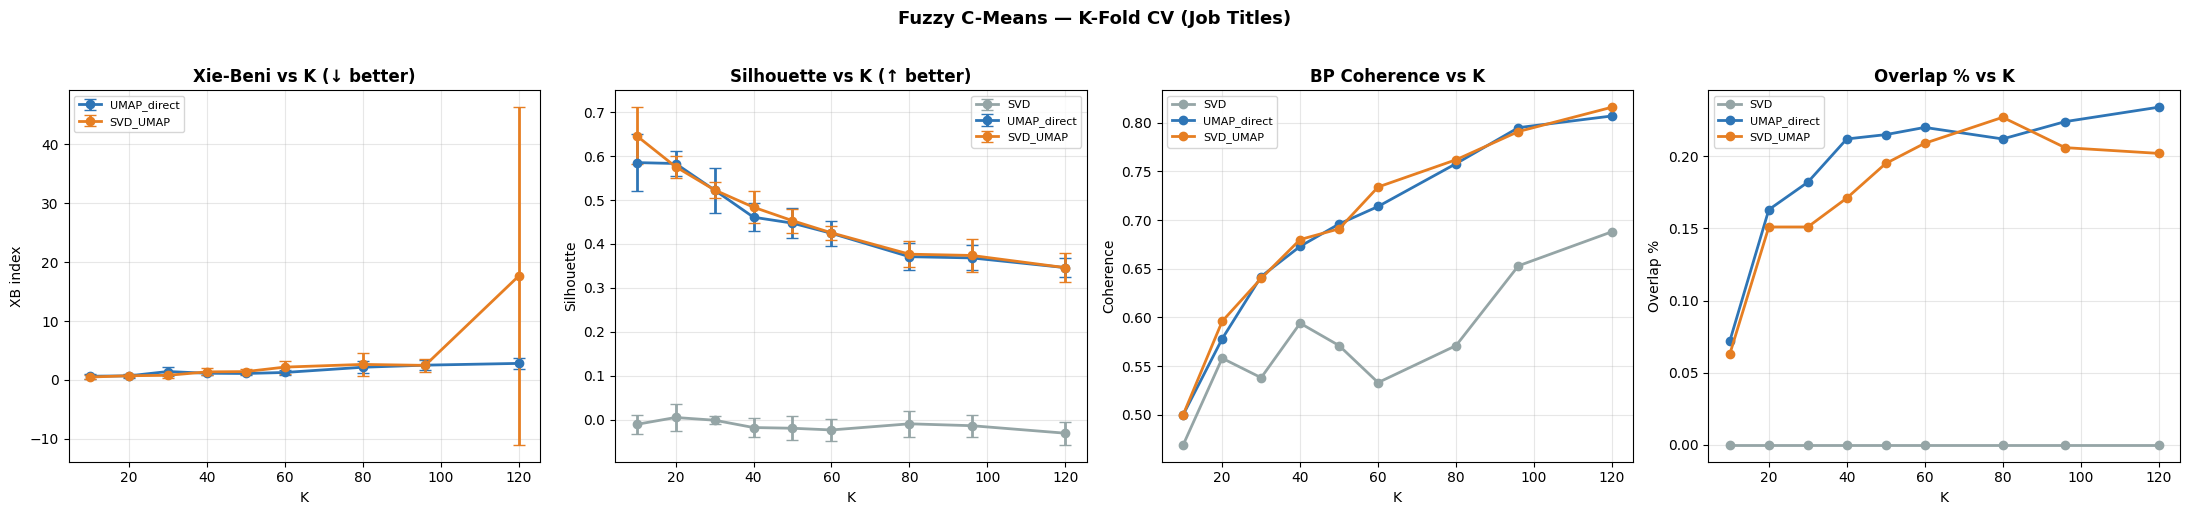


════════════════════════════════════════════════════════════
BEST K PER REPRESENTATION (by Xie-Beni, lower = better)
════════════════════════════════════════════════════════════
  UMAP_direct     → K= 10  XB=0.6292  Sil=0.5853  Coh=50.0%  Ovlp=7.2%
  SVD_UMAP        → K= 10  XB=0.4920  Sil=0.6465  Coh=50.0%  Ovlp=6.3%


In [34]:
# K-FOLD CV — Fuzzy C-Means K search (Job Titles)
# 3 representaciones × 9 K values × 5 folds
# Metrics: Xie-Beni (primary), Silhouette, Coherence, Overlap

bp_col = 'BUSINESS PROCESS'

K_RANGE_FUZZY   = [10, 20, 30, 40, 50, 60, 80, 96, 120]
FUZZY_THRESHOLD = 0.20

kf      = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
jt_list = list(matrix_train_log.index)

cv_fuzzy_results = []

representations_fuzzy = {
    'SVD':         X_svd,
    'UMAP_direct': X_umap_direct_norm,
    'SVD_UMAP':    X_umap_on_svd_norm
}

# Xie-Beni index
def xie_beni(X, u, centroids):
    """
    Xie-Beni validity index for fuzzy clustering.
    Lower = better (more compact and separated clusters).
    
    X:          data matrix (N x D)
    u:          membership matrix (K x N)
    centroids:  cluster centers (K x D)
    """
    # Compactness: weighted sum of squared distances to centroids
    compactness = 0.0
    for k in range(centroids.shape[0]):
        diff = X - centroids[k]
        compactness += np.sum((u[k] ** 2) * np.sum(diff ** 2, axis=1))

    # Separation: minimum squared distance between any two centroids
    min_sep = np.inf
    for k in range(len(centroids)):
        for l in range(len(centroids)):
            if k != l:
                d = np.sum((centroids[k] - centroids[l]) ** 2)
                if d < min_sep:
                    min_sep = d

    if min_sep == 0:
        return np.inf

    return compactness / (len(X) * min_sep)

print('═'*60)
print('K-FOLD CV — Fuzzy C-Means (Job Titles)')
print(f'Threshold: {FUZZY_THRESHOLD}')
print(f'Primary metric: Xie-Beni (lower = better)')
print('═'*60)

for rep_name, X_rep in representations_fuzzy.items():
    print(f'\n{"═"*60}')
    print(f'Representation: {rep_name}  shape: {X_rep.shape}')
    print(f'{"═"*60}')

    for K_TEST in K_RANGE_FUZZY:
        print(f'\n  K = {K_TEST}')

        fold_xbs   = []
        fold_sils  = []
        fold_cohs  = []
        fold_ovlps = []

        for fold_i, (tr_idx, te_idx) in enumerate(kf.split(X_rep)):
            X_tr = X_rep[tr_idx]
            X_te = X_rep[te_idx]

            try:
                cntr, u_tr, *_ = fuzz.cluster.cmeans(
                    X_tr.T, c=K_TEST, m=2,
                    error=0.005, maxiter=200, seed=RANDOM_STATE
                )

                # Xie-Beni on train set (native fuzzy metric)
                xb = xie_beni(X_tr, u_tr, cntr)
                fold_xbs.append(xb if np.isfinite(xb) else np.nan)

                # Predict test set
                u_te, *_ = fuzz.cluster.cmeans_predict(
                    X_te.T, cntr, m=2,
                    error=0.005, maxiter=200
                )

                # Silhouette on test set (hard labels via argmax)
                labels_te = u_te.argmax(axis=0)
                sil, db, _, _ = eval_on_test(X_te, labels_te)

                # Overlap % on test set
                jts_te   = [jt_list[i] for i in te_idx]
                n_ovlp   = sum(
                    1 for i in range(len(jts_te))
                    if (u_te[:, i] >= FUZZY_THRESHOLD).sum() > 1
                )
                pct_ovlp = n_ovlp / len(jts_te)

                # BP Coherence on test set
                df_te = pd.DataFrame({
                    'JOB_TITLE': jts_te,
                    'CLUSTER':   labels_te
                }).merge(
                    df_jt_metadata[['JOB_TITLE', bp_col]],
                    on='JOB_TITLE', how='left'
                )

                pureza_list = []
                for cl_id in np.unique(labels_te):
                    sub = df_te[
                        (df_te['CLUSTER'] == cl_id) &
                        (df_te[bp_col].notna())
                    ]
                    if len(sub) == 0:
                        continue
                    pureza_list.append(
                        sub[bp_col].value_counts().iloc[0] / len(sub)
                    )
                coherence = np.mean(pureza_list) if pureza_list else np.nan

                fold_sils.append(sil       if not np.isnan(sil)       else np.nan)
                fold_cohs.append(coherence if not np.isnan(coherence) else np.nan)
                fold_ovlps.append(pct_ovlp)

                print(f'    Fold {fold_i+1}: XB={xb:.4f}  Sil={sil:.3f}  '
                      f'Coh={coherence:.1%}  Ovlp={pct_ovlp:.1%}')

            except Exception as e:
                print(f'    Fold {fold_i+1} failed: {e}')
                fold_xbs.append(np.nan)
                fold_sils.append(np.nan)
                fold_cohs.append(np.nan)
                fold_ovlps.append(np.nan)

        row = {
            'Representation': rep_name,
            'K':              K_TEST,
            'XB mean':        round(np.nanmean(fold_xbs),  4),
            'XB std':         round(np.nanstd(fold_xbs),   4),
            'Sil mean':       round(np.nanmean(fold_sils),  4),
            'Sil std':        round(np.nanstd(fold_sils),   4),
            'Coherence':      f'{np.nanmean(fold_cohs):.1%}',
            'Overlap %':      f'{np.nanmean(fold_ovlps):.1%}',
            'Valid folds':    sum(1 for s in fold_xbs if not np.isnan(s))
        }
        cv_fuzzy_results.append(row)

        print(f'  → [{rep_name}] K={K_TEST}  '
              f'XB: {row["XB mean"]:.4f} ± {row["XB std"]:.4f}  '
              f'Sil: {row["Sil mean"]:.4f}  '
              f'Coh: {row["Coherence"]}  '
              f'Overlap: {row["Overlap %"]}')

# Tabla final
df_cv_fuzzy = pd.DataFrame(cv_fuzzy_results)
print('\n' + '═'*70)
print('FUZZY C-MEANS — CV RESULTS — UMAP_direct & SVD_UMAP only')
print('(SVD excluded from XB table: values in millions, not comparable)')
print('═'*70)
df_cv_fuzzy_nosvd = df_cv_fuzzy[df_cv_fuzzy['Representation'] != 'SVD']
print(df_cv_fuzzy_nosvd.sort_values('XB mean').to_string(index=False))

# Plot
rep_colors = {'SVD': '#95A5A6', 'UMAP_direct': '#2E75B6', 'SVD_UMAP': '#E67E22'}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for rep_name, color in rep_colors.items():
    sub = df_cv_fuzzy[df_cv_fuzzy['Representation'] == rep_name]
    if sub.empty:
        continue

    if rep_name != 'SVD':  # SVD XB values in millions — not comparable
        axes[0].errorbar(sub['K'], sub['XB mean'], yerr=sub['XB std'],
                         fmt='o-', color=color, capsize=4,
                         linewidth=2, label=rep_name)
    axes[1].errorbar(sub['K'], sub['Sil mean'], yerr=sub['Sil std'],
                     fmt='o-', color=color, capsize=4,
                     linewidth=2, label=rep_name)
    axes[2].plot(sub['K'],
                 [float(x.strip('%'))/100 for x in sub['Coherence']],
                 'o-', color=color, linewidth=2, label=rep_name)
    axes[3].plot(sub['K'],
                 [float(x.strip('%'))/100 for x in sub['Overlap %']],
                 'o-', color=color, linewidth=2, label=rep_name)

for ax, title, ylabel in zip(
    axes,
    ['Xie-Beni vs K (↓ better)', 'Silhouette vs K (↑ better)',
     'BP Coherence vs K', 'Overlap % vs K'],
    ['XB index', 'Silhouette', 'Coherence', 'Overlap %']
):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('K')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Fuzzy C-Means — K-Fold CV (Job Titles)',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Mejor K por representación
print('\n' + '═'*60)
print('BEST K PER REPRESENTATION (by Xie-Beni, lower = better)')
print('═'*60)
for rep_name in [r for r in representations_fuzzy.keys() if r != 'SVD']:
    sub = df_cv_fuzzy[df_cv_fuzzy['Representation'] == rep_name]
    best = sub.loc[sub['XB mean'].idxmin()]  # min XB = mejor (SVD excluded)
    print(f'  {rep_name:<15} → K={int(best["K"]):3d}  '
          f'XB={best["XB mean"]:.4f}  '
          f'Sil={best["Sil mean"]:.4f}  '
          f'Coh={best["Coherence"]}  '
          f'Ovlp={best["Overlap %"]}')

### 5.1.2 Result of the method

════════════════════════════════════════════════════════════
FUZZY C-MEANS — Final Clustering
  Representation: SVD_UMAP
  K:              30
  Threshold:      0.2
════════════════════════════════════════════════════════════

Results:
  Communities:            30
  Threshold:              0.2
  JTs in 1 community:     674
  JTs in 2 communities:   115
  JTs in 3+ communities:  7
  Mean communities/JT:    1.16
  Max communities/JT:     3


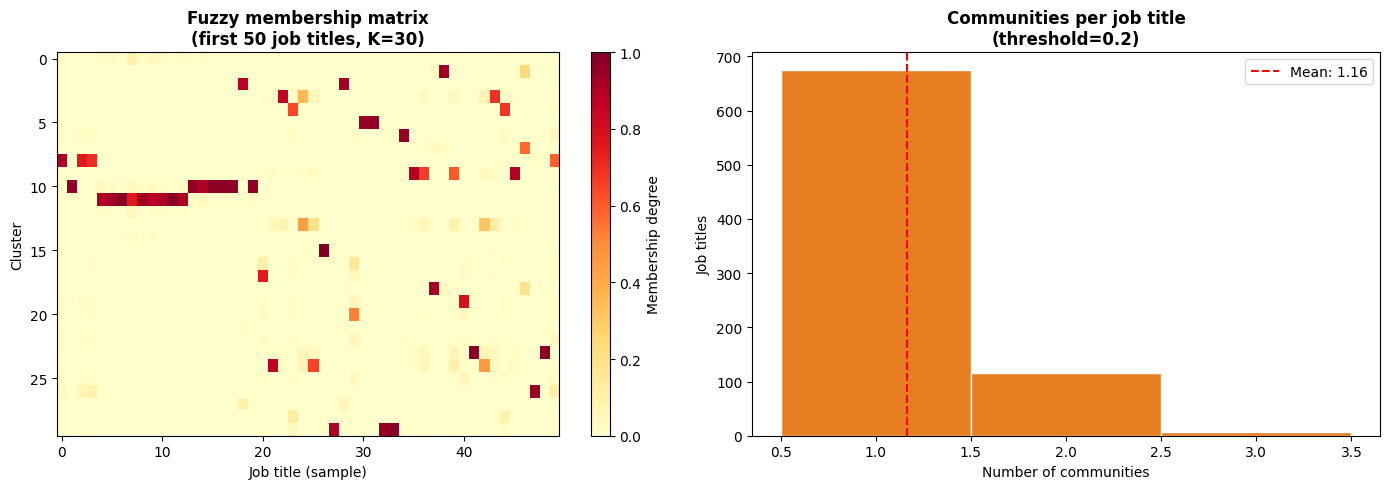


df_fuzzy_overlap: (796, 5)
                              JOB_TITLE COMMUNITIES  N_COMMUNITIES  \
0                     Account Assistant         [8]              1   
1               Account Payable Analyst        [10]              1   
2            Account Receivable Officer         [8]              1   
3                   Account Receivables         [8]              1   
4                            Accountant        [11]              1   
5                            Accounting        [11]              1   
6  Accounting & Einf Manager Human Food        [11]              1   
7     Accounting & Einf Manager Petfood        [11]              1   
8                Accounting Coordinator        [11]              1   
9      Accounting Interc & Fixed Assets        [11]              1   

   PRIMARY_CLUSTER  MAX_MEMBERSHIP  
0                8        0.909407  
1               10        0.961687  
2                8        0.758741  
3                8        0.699234  
4               

In [35]:
# FUZZY C-MEANS — Final execution with optimal K
# Representation: SVD_UMAP  |  K=30 (selected by Xie-Beni CV)


FUZZY_K_FINAL     = 30
FUZZY_M           = 2       # fuzziness exponent, standard value (Bezdek 1981)
FUZZY_THRESHOLD   = 0.20    # membership threshold for overlapping assignment

X_fuzzy = X_umap_on_svd_norm
jt_list = list(matrix_train_log.index)

print('═'*60)
print('FUZZY C-MEANS — Final Clustering')
print(f'  Representation: SVD_UMAP')
print(f'  K:              {FUZZY_K_FINAL}')
print(f'  Threshold:      {FUZZY_THRESHOLD}')
print('═'*60)

cntr_final, u_fuzzy, *_ = fuzz.cluster.cmeans(
    X_fuzzy.T,
    c       = FUZZY_K_FINAL,
    m       = FUZZY_M,
    error   = 0.005,
    maxiter = 500,
    seed    = RANDOM_STATE
)

# u_fuzzy shape: (K x N_job_titles)
# u_fuzzy[k, i] = membership degree of job title i to cluster k

# Build overlapping assignments 
# A job title belongs to a cluster if membership > FUZZY_THRESHOLD
# If no cluster exceeds threshold → assign to primary (argmax)
fuzzy_communities = {}
for i, jt in enumerate(jt_list):
    memberships = u_fuzzy[:, i]
    clusters    = [k for k, m in enumerate(memberships)
                   if m >= FUZZY_THRESHOLD]
    if not clusters:
        clusters = [int(memberships.argmax())]
    fuzzy_communities[jt] = clusters

# Stats
n_memberships = [len(v) for v in fuzzy_communities.values()]

print(f'\nResults:')
print(f'  Communities:            {FUZZY_K_FINAL}')
print(f'  Threshold:              {FUZZY_THRESHOLD}')
print(f'  JTs in 1 community:     {sum(1 for v in fuzzy_communities.values() if len(v) == 1):,}')
print(f'  JTs in 2 communities:   {sum(1 for v in fuzzy_communities.values() if len(v) == 2):,}')
print(f'  JTs in 3+ communities:  {sum(1 for v in fuzzy_communities.values() if len(v) >= 3):,}')
print(f'  Mean communities/JT:    {np.mean(n_memberships):.2f}')
print(f'  Max communities/JT:     {max(n_memberships)}')

# Build df_fuzzy_overlap
df_fuzzy_overlap = pd.DataFrame({
    'JOB_TITLE':       jt_list,
    'COMMUNITIES':     [fuzzy_communities[jt] for jt in jt_list],
    'N_COMMUNITIES':   [len(fuzzy_communities[jt]) for jt in jt_list],
    'PRIMARY_CLUSTER': [int(u_fuzzy[:, i].argmax()) for i, jt in enumerate(jt_list)],
    'MAX_MEMBERSHIP':  [float(u_fuzzy[:, i].max()) for i, jt in enumerate(jt_list)]
})

# Plot 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Membership matrix sample
sample_idx = list(range(min(50, len(jt_list))))
im = axes[0].imshow(
    u_fuzzy[:, sample_idx],
    aspect='auto', cmap='YlOrRd', vmin=0, vmax=1
)
axes[0].set_title(f'Fuzzy membership matrix\n(first 50 job titles, K={FUZZY_K_FINAL})',
                  fontweight='bold')
axes[0].set_xlabel('Job title (sample)')
axes[0].set_ylabel('Cluster')
plt.colorbar(im, ax=axes[0], label='Membership degree')

# Communities per JT distribution
axes[1].hist(n_memberships, bins=range(1, max(n_memberships)+2),
             color='#E67E22', edgecolor='white', align='left')
axes[1].set_title(f'Communities per job title\n(threshold={FUZZY_THRESHOLD})',
                  fontweight='bold')
axes[1].set_xlabel('Number of communities')
axes[1].set_ylabel('Job titles')
axes[1].axvline(np.mean(n_memberships), color='red', linestyle='--',
                label=f'Mean: {np.mean(n_memberships):.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\ndf_fuzzy_overlap: {df_fuzzy_overlap.shape}')
print(df_fuzzy_overlap.head(10))

### 5.1.3 Export of the results

In [36]:
# EXPORT — Fuzzy clusters: job titles + t-codes per cluster


os.makedirs('output phase2 JT', exist_ok=True)

# TF-IDF dataframe
tfidf_dense = X_tfidf.toarray()
df_tfidf = pd.DataFrame(
    tfidf_dense,
    index   = matrix_train_log.index,
    columns = matrix_train_log.columns
)

# Columnas comunes
common_tcodes = usage_matrix.columns.intersection(df_tfidf.columns)

# BP map
bp_map = df_jt_metadata.set_index('JOB_TITLE')['BUSINESS PROCESS'].to_dict()

output_rows = []

for cluster_id in sorted(set(
    c for communities in fuzzy_communities.values() for c in communities
)):
    # Job titles en este cluster
    jts_in_cluster = [
        jt for jt in jt_list
        if cluster_id in fuzzy_communities[jt]
    ]

    for jt in jts_in_cluster:
        n_communities = len(fuzzy_communities[jt])
        membership    = float(u_fuzzy[cluster_id, jt_list.index(jt)])
        n_users_vals  = df_jt_metadata.loc[
            df_jt_metadata['JOB_TITLE'] == jt, 'N_USERS'
        ].values
        n_users = int(n_users_vals[0]) if len(n_users_vals) > 0 else 0

        output_rows.append({
            'CLUSTER_ID':       cluster_id,
            'TYPE':             'JOB_TITLE',
            'NAME':             jt,
            'BUSINESS_PROCESS': bp_map.get(jt, ''),
            'N_USERS':          n_users,
            'MEMBERSHIP':       round(membership, 4),
            'OVERLAPPING':      1 if n_communities > 1 else 0,
            'N_COMMUNITIES':    n_communities,
            'PCT_JT_USING':     '',
            'AVG_FREQ':         '',
            'TFIDF_WEIGHT':     '',
            'JT_USING':         '',
        })

    # T-codes del cluster
    jts_in_usage = [jt for jt in jts_in_cluster if jt in usage_matrix.index]
    jts_in_tfidf = [jt for jt in jts_in_cluster if jt in df_tfidf.index]
    n_jts_total  = len(jts_in_usage)

    if n_jts_total > 0:
        X_cluster    = usage_matrix.loc[jts_in_usage, common_tcodes]
        tfidf_weight = (
            df_tfidf.loc[jts_in_tfidf, common_tcodes].mean(axis=0)
            if jts_in_tfidf
            else pd.Series(0, index=common_tcodes)
        )

        pct_using = (X_cluster > 0).sum(axis=0) / n_jts_total
        avg_freq  = X_cluster.mean(axis=0)

        # Job titles que usan cada tcode
        jt_using_tcode = {
            tcode: ', '.join([
                jt for jt in jts_in_usage
                if X_cluster.loc[jt, tcode] > 0
            ])
            for tcode in common_tcodes
        }

        df_tcodes = pd.DataFrame({
            'PCT_JT_USING': pct_using,
            'AVG_FREQ':     avg_freq,
            'TFIDF_WEIGHT': tfidf_weight,
        })
        df_tcodes = df_tcodes[df_tcodes['PCT_JT_USING'] > 0]
        df_tcodes = df_tcodes.sort_values('PCT_JT_USING', ascending=False)

        for tcode, row in df_tcodes.iterrows():
            output_rows.append({
                'CLUSTER_ID':       cluster_id,
                'TYPE':             'TCODE',
                'NAME':             tcode,
                'BUSINESS_PROCESS': '',
                'N_USERS':          '',
                'MEMBERSHIP':       '',
                'OVERLAPPING':      '',
                'N_COMMUNITIES':    '',
                'PCT_JT_USING':     round(row['PCT_JT_USING'], 4),
                'AVG_FREQ':         round(row['AVG_FREQ'], 2),
                'TFIDF_WEIGHT':     round(row['TFIDF_WEIGHT'], 4),
                'JT_USING':         jt_using_tcode.get(tcode, ''),
            })

# Build dataframe
df_export = pd.DataFrame(output_rows)

# Export
export_path = 'output phase2 JT/fuzzy_clusters_export.xlsx'

with pd.ExcelWriter(export_path, engine='openpyxl') as writer:
    df_export.to_excel(writer, sheet_name='Clusters', index=False)
    ws = writer.sheets['Clusters']
    for col in ws.columns:
        max_len = max(len(str(cell.value or '')) for cell in col)
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 2, 50)

print(f'Export done: {export_path}')
print(f'Total rows:      {len(df_export):,}')
print(f'JOB_TITLE rows:  {(df_export["TYPE"] == "JOB_TITLE").sum():,}')
print(f'TCODE rows:      {(df_export["TYPE"] == "TCODE").sum():,}')
print(f'Clusters:        {df_export["CLUSTER_ID"].nunique()}')

Export done: output phase2 JT/fuzzy_clusters_export.xlsx
Total rows:      8,445
JOB_TITLE rows:  925
TCODE rows:      7,520
Clusters:        30


### 5.2.2 Local Fitness Method

### LFM - Threshold calibration

In [37]:
# Build binary matrix from TF-IDF
X_tfidf_train = X_tfidf[:len(jt_list)]
X_dense_train = X_tfidf_train.toarray() if issparse(X_tfidf_train) else X_tfidf_train
binary_matrix = (X_dense_train > 0).astype(float)

print(f'Matrix shape: {binary_matrix.shape}')
print(f'Computing Jaccard distances...')

t0         = time.time()
sim_matrix = 1 - pairwise_distances(binary_matrix, metric='jaccard')
np.fill_diagonal(sim_matrix, 0)
print(f'Done in {time.time()-t0:.0f}s')

# Threshold calibration
print(f'\n{"Threshold":>10}  {"Edges":>10}  {"Density":>8}  {"Isolated":>9}')
print(f'  {"─"*10}  {"─"*10}  {"─"*8}  {"─"*9}')

for thresh in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    n_edges  = int((sim_matrix > thresh).sum() / 2)
    density  = n_edges / (len(jt_list) * (len(jt_list)-1) / 2)
    isolated = int(((sim_matrix > thresh).sum(axis=1) == 0).sum())
    print(f'  {thresh:>10.1f}  {n_edges:>10,}  {density:>8.4f}  {isolated:>9}')

Matrix shape: (796, 1626)
Computing Jaccard distances...
Done in 2s

 Threshold       Edges   Density   Isolated
  ──────────  ──────────  ────────  ─────────
         0.1     105,274    0.3327          0
         0.2      30,312    0.0958          3
         0.3      11,116    0.0351         35
         0.4       3,998    0.0126        167
         0.5       1,314    0.0042        448
         0.6         568    0.0018        590
         0.7         209    0.0007        692
         0.8          63    0.0002        739


# LFM — Alpha calibration (threshold=0.3)
# ============================================================

THRESHOLDS = [0.3]
ALPHAS     = [0.5, 0.8, 1.0, 1.5]
bp_col     = 'BUSINESS PROCESS'

# Build graph with threshold=0.3
G = nx.Graph()
G.add_nodes_from(range(len(jt_list)))
rows, cols = np.where(sim_matrix > 0.3)
edges = [(r, c, float(sim_matrix[r, c])) for r, c in zip(rows, cols) if r < c]
G.add_weighted_edges_from(edges)

isolated_nodes = [n for n in G.nodes() if G.degree(n) == 0]
n_isolated     = len(isolated_nodes)
G_connected    = G.copy()
G_connected.remove_nodes_from(isolated_nodes)

print(f'Graph: {G_connected.number_of_nodes()} nodes, {G_connected.number_of_edges()} edges')
print(f'Isolated: {n_isolated}')
print()

print(f'{"Alpha":>6}  {"Comms":>6}  {"Mean sz":>8}  {"Min":>5}  {"Max":>5}  {"Ovlp%":>7}  {"BP Coh":>8}  {"Time":>6}')
print('─'*60)

results = []

for alpha in ALPHAS:
    try:
        t0         = time.time()
        lfm_result = cdlib_alg.lfm(G_connected, alpha=alpha)
        elapsed    = time.time() - t0

        communities_list = lfm_result.communities
        n_comm     = len(communities_list)
        comm_sizes = [len(c) for c in communities_list]

        # Overlap %
        node_counts = {}
        for comm in communities_list:
            for node in comm:
                node_counts[node] = node_counts.get(node, 0) + 1
        n_overlap   = sum(1 for v in node_counts.values() if v > 1)
        pct_overlap = n_overlap / G_connected.number_of_nodes()

        # BP Coherence
        lfm_temp = {jt_list[node_id]: [] for node_id in range(len(jt_list))}
        for comm_id, community in enumerate(communities_list):
            for node_id in community:
                if node_id < len(jt_list):
                    lfm_temp[jt_list[node_id]].append(comm_id)

        df_temp = pd.DataFrame({
            'JOB_TITLE': jt_list,
            'CLUSTER':   [lfm_temp[jt][0] if lfm_temp[jt] else -1 for jt in jt_list]
        }).merge(df_jt_metadata[['JOB_TITLE', bp_col]], on='JOB_TITLE', how='left')

        pureza_list = []
        for cl_id in df_temp['CLUSTER'].unique():
            if cl_id == -1:
                continue
            sub = df_temp[(df_temp['CLUSTER'] == cl_id) & (df_temp[bp_col].notna())]
            if len(sub) == 0:
                continue
            pureza_list.append(sub[bp_col].value_counts().iloc[0] / len(sub))
        coherence = np.mean(pureza_list) if pureza_list else np.nan

        print(f'{alpha:>6.1f}  {n_comm:>6}  {np.mean(comm_sizes):>8.1f}  '
              f'{min(comm_sizes):>5}  {max(comm_sizes):>5}  '
              f'{pct_overlap:>7.1%}  {coherence:>7.1%}  {elapsed:>5.1f}s')

        results.append({
            'alpha':        alpha,
            'n_comm':       n_comm,
            'mean_size':    round(np.mean(comm_sizes), 1),
            'min_size':     min(comm_sizes),
            'max_size':     max(comm_sizes),
            'pct_overlap':  round(pct_overlap, 4),
            'bp_coherence': round(coherence, 4),
        })

    except Exception as e:
        print(f'{alpha:>6.1f}  failed: {e}')

print()
df_lfm_cal = pd.DataFrame(results)
print(df_lfm_cal.to_string(index=False))
print('\nChoose alpha with: max_size < 100, overlap > 10%, high BP coherence')

In [38]:
# LFM — Local Fitness Method
# Lancichinetti et al. (2009) via cdlib
# threshold=0.3, alpha=0.8

print('═'*60)
print('LFM — Final execution')
print('threshold=0.3  |  alpha=0.8')
print('═'*60)

# Step 1: Similarity matrix
print('\nStep 1 — Building similarity matrix...')
X_tfidf_train = X_tfidf[:len(jt_list)]
X_dense_train = X_tfidf_train.toarray() if issparse(X_tfidf_train) else X_tfidf_train
binary_matrix = (X_dense_train > 0).astype(float)

t0         = time.time()
sim_matrix = 1 - pairwise_distances(binary_matrix, metric='jaccard')
np.fill_diagonal(sim_matrix, 0)
print(f'  Done in {time.time()-t0:.0f}s')

# Step 2: Build graph
print('\nStep 2 — Building graph (threshold=0.3)...')
G = nx.Graph()
G.add_nodes_from(range(len(jt_list)))
rows, cols = np.where(sim_matrix > 0.3)
edges      = [(r, c, float(sim_matrix[r, c]))
              for r, c in zip(rows, cols) if r < c]
G.add_weighted_edges_from(edges)

isolated_nodes = [n for n in G.nodes() if G.degree(n) == 0]
n_isolated     = len(isolated_nodes)
G_connected    = G.copy()
G_connected.remove_nodes_from(isolated_nodes)

print(f'  Nodes:    {G_connected.number_of_nodes()}')
print(f'  Edges:    {G_connected.number_of_edges()}')
print(f'  Isolated: {n_isolated}')

# Step 3: LFM
print('\nStep 3 — Running LFM (alpha=0.8)...')
t0         = time.time()
lfm_result = cdlib_alg.lfm(G_connected, alpha=0.8)
elapsed    = time.time() - t0
print(f'  Done in {elapsed:.1f}s')

communities_list = lfm_result.communities
n_comm           = len(communities_list)
print(f'  Communities found: {n_comm}')

# Step 4: Parse results
print('\nStep 4 — Parsing results...')
lfm_jt_communities = {jt: [] for jt in jt_list}
for comm_id, community in enumerate(communities_list):
    for node_id in community:
        if node_id < len(jt_list):
            lfm_jt_communities[jt_list[node_id]].append(comm_id)

# Step 5: Assign isolated nodes
if isolated_nodes:
    print(f'\nStep 5 — Assigning {len(isolated_nodes)} isolated nodes...')
    comm_centroids = np.array([
        binary_matrix[list(c)].mean(axis=0)
        for c in communities_list if c
    ])
    for node_id in isolated_nodes:
        if node_id < len(jt_list):
            jt   = jt_list[node_id]
            dist = pairwise_distances(
                binary_matrix[node_id].reshape(1, -1),
                comm_centroids, metric='jaccard'
            )
            lfm_jt_communities[jt].append(int(dist.argmin()))
    print(f'  {len(isolated_nodes)} nodes assigned')

# Step 6: Metrics
print('\nStep 6 — Computing metrics...')
n_memberships = [len(v) for v in lfm_jt_communities.values()]
comm_sizes    = pd.Series([len(c) for c in communities_list])

labels_lfm = np.array([
    lfm_jt_communities[jt][0] if lfm_jt_communities[jt] else -1
    for jt in jt_list
])

# BP Coherence
df_lfm_eval = pd.DataFrame({
    'JOB_TITLE': jt_list,
    'CLUSTER':   labels_lfm
}).merge(df_jt_metadata[['JOB_TITLE', bp_col]], on='JOB_TITLE', how='left')

pureza_list = []
for cl_id in np.unique(labels_lfm[labels_lfm != -1]):
    sub = df_lfm_eval[
        (df_lfm_eval['CLUSTER'] == cl_id) &
        (df_lfm_eval[bp_col].notna())
    ]
    if len(sub) == 0:
        continue
    pureza_list.append(sub[bp_col].value_counts().iloc[0] / len(sub))
coherence_lfm = np.mean(pureza_list) if pureza_list else np.nan

print(f'\nOverlapping results:')
print(f'  Communities:          {n_comm}')
print(f'  BP Coherence:         {coherence_lfm:.1%}')
print(f'  Community size mean:  {comm_sizes.mean():.1f}')
print(f'  Community size min:   {comm_sizes.min()}')
print(f'  Community size max:   {comm_sizes.max()}')
print(f'  JTs in 1 community:   {sum(1 for v in n_memberships if v == 1):,}')
print(f'  JTs in 2 communities: {sum(1 for v in n_memberships if v == 2):,}')
print(f'  JTs in 3+ communities:{sum(1 for v in n_memberships if v >= 3):,}')
print(f'  Mean communities/JT:  {np.mean(n_memberships):.2f}')

print('\nGraph-based metrics (native evaluation space for LFM):')
for name, fn, direction in [
    ('Newman-Girvan Modularity', cdlib_eval.newman_girvan_modularity, '> 0.3 = good'),
    ('Conductance',              cdlib_eval.conductance,              '< 0.5 = good'),
    ('Internal edge density',    cdlib_eval.internal_edge_density,    '> 0.3 = good'),
    ('Avg embeddedness',         cdlib_eval.avg_embeddedness,         '> 0.5 = good'),
    ('Modularity overlap',       cdlib_eval.modularity_overlap,       '> 0.3 = good'),
]:
    try:
        result = fn(G_connected, lfm_result)
        print(f'  {name:<30} {result.score:.4f}  ({direction})')
    except Exception as e:
        print(f'  {name:<30} failed: {e}')

# Step 7: Save 
print('\nStep 7 — Saving...')
os.makedirs('output phase2', exist_ok=True)

df_lfm_overlap = pd.DataFrame({
    'JOB_TITLE':         jt_list,
    'COMMUNITIES':       [lfm_jt_communities[jt] for jt in jt_list],
    'N_COMMUNITIES':     [len(lfm_jt_communities[jt]) for jt in jt_list],
    'PRIMARY_COMMUNITY': [
        lfm_jt_communities[jt][0] if lfm_jt_communities[jt] else -1
        for jt in jt_list
    ]
})

df_lfm_overlap.to_csv('output phase2/LFM_overlap_results.csv', index=False)

with open('output phase2/lfm_communities.pkl', 'wb') as f:
    pickle.dump(lfm_jt_communities, f)

print('  CSV saved')
print('  Pickle saved')
print(f'\nDone in {elapsed:.1f}s total')

════════════════════════════════════════════════════════════
LFM — Final execution
threshold=0.3  |  alpha=0.8
════════════════════════════════════════════════════════════

Step 1 — Building similarity matrix...
  Done in 2s

Step 2 — Building graph (threshold=0.3)...
  Nodes:    761
  Edges:    11116
  Isolated: 35

Step 3 — Running LFM (alpha=0.8)...
  Done in 1.8s
  Communities found: 38

Step 4 — Parsing results...

Step 5 — Assigning 35 isolated nodes...
  35 nodes assigned

Step 6 — Computing metrics...

Overlapping results:
  Communities:          38
  BP Coherence:         62.4%
  Community size mean:  28.2
  Community size min:   2
  Community size max:   233
  JTs in 1 community:   595
  JTs in 2 communities: 151
  JTs in 3+ communities:50
  Mean communities/JT:  1.39

Graph-based metrics (native evaluation space for LFM):
  Newman-Girvan Modularity       0.5994  (> 0.3 = good)
  Conductance                    0.1969  (< 0.5 = good)
  Internal edge density          0.5381  (>

### See the constructed graph

Building visualization...
Computing layout (this may take ~30s)...


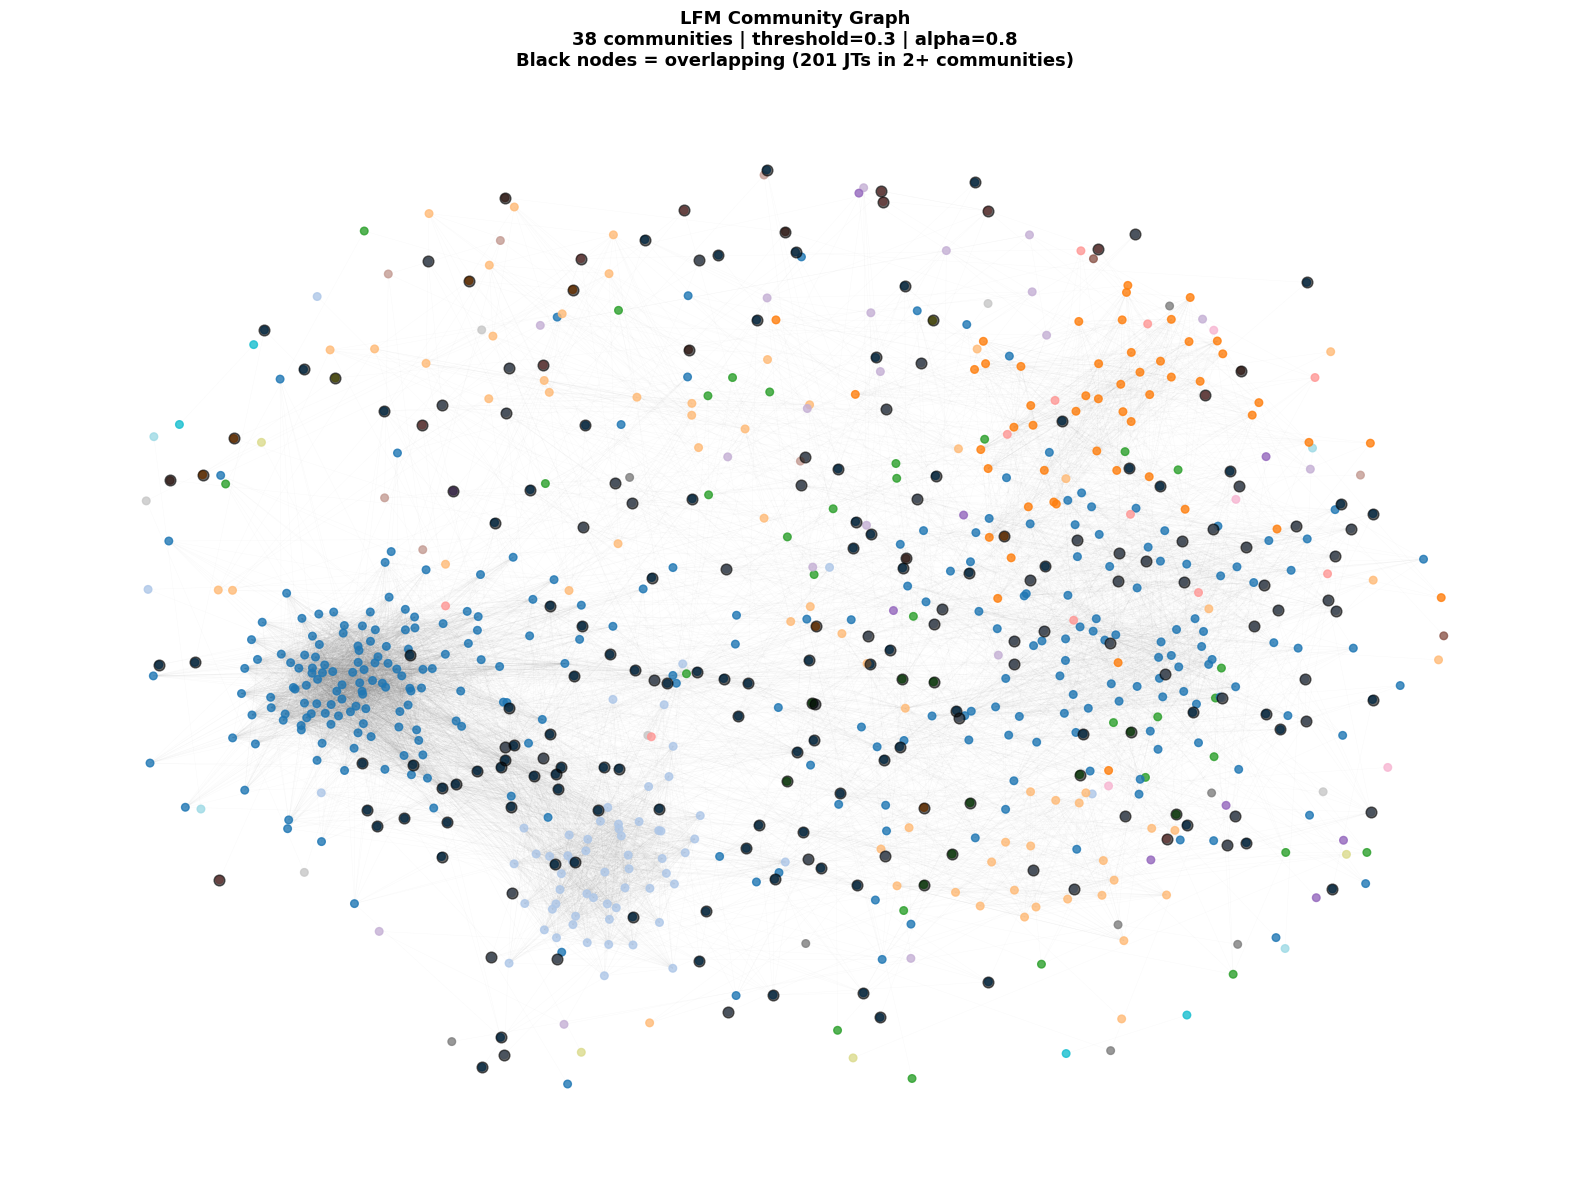

In [39]:
# LFM — Graph visualization

print('Building visualization...')

# Color nodes by primary community 
n_colors     = len(communities_list)
color_map    = cm.tab20(np.linspace(0, 1, max(n_colors, 1)))
node_colors  = []

for node_id in G_connected.nodes():
    jt = jt_list[node_id] if node_id < len(jt_list) else None
    if jt and lfm_jt_communities.get(jt):
        primary_comm = lfm_jt_communities[jt][0]
        node_colors.append(color_map[primary_comm % len(color_map)])
    else:
        node_colors.append([0.7, 0.7, 0.7, 1.0])

# Layout 
print('Computing layout (this may take ~30s)...')
pos = nx.spring_layout(G_connected, k=0.3, seed=42, iterations=50)

# Plot
fig, ax = plt.subplots(figsize=(16, 12))

# Draw edges
nx.draw_networkx_edges(
    G_connected, pos,
    alpha=0.05, width=0.3,
    edge_color='grey', ax=ax
)

# Draw nodes
nx.draw_networkx_nodes(
    G_connected, pos,
    node_color=node_colors,
    node_size=30, alpha=0.8, ax=ax
)

# Highlight overlapping nodes (in 2+ communities)
overlapping_nodes = [
    node_id for node_id in G_connected.nodes()
    if node_id < len(jt_list) and
    len(lfm_jt_communities.get(jt_list[node_id], [])) > 1
]
if overlapping_nodes:
    nx.draw_networkx_nodes(
        G_connected, pos,
        nodelist=overlapping_nodes,
        node_color='black',
        node_size=60, alpha=0.6, ax=ax
    )

ax.set_title(
    f'LFM Community Graph\n'
    f'{n_comm} communities | threshold=0.3 | alpha=0.8\n'
    f'Black nodes = overlapping ({len(overlapping_nodes)} JTs in 2+ communities)',
    fontweight='bold', fontsize=13
)
ax.axis('off')
plt.tight_layout()
plt.show()

In [40]:
for comm_id, community in enumerate(communities_list):
    jts = [jt_list[n] for n in community if n < len(jt_list)]
    bps = [bp_map.get(jt, 'Unknown') for jt in jts]
    dominant_bp = pd.Series(bps).value_counts().index[0] if bps else 'Unknown'
    print(f'Community {comm_id:>3}: {len(community):>4} JTs | dominant BP: {dominant_bp}')

Community   0:  233 JTs | dominant BP: SALES & MARKETING
Community   1:  156 JTs | dominant BP: SUPPLY CHAIN & LOGISTICS
Community   2:   91 JTs | dominant BP: SALES & MARKETING
Community   3:   65 JTs | dominant BP: SUPPLY CHAIN & LOGISTICS
Community   4:   65 JTs | dominant BP: SUPPLY CHAIN & LOGISTICS
Community   5:   59 JTs | dominant BP: QUALITY & REGULATORY
Community   6:   39 JTs | dominant BP: MAINTENANCE & ENGINEERING
Community   7:   39 JTs | dominant BP: PROCUREMENT & SOURCING
Community   8:   36 JTs | dominant BP: FINANCE & CONTROLLING
Community   9:   30 JTs | dominant BP: R&D & INNOVATION
Community  10:   30 JTs | dominant BP: R&D & INNOVATION
Community  11:   30 JTs | dominant BP: R&D & INNOVATION
Community  12:   30 JTs | dominant BP: R&D & INNOVATION
Community  13:   18 JTs | dominant BP: FINANCE & CONTROLLING
Community  14:   17 JTs | dominant BP: SALES & MARKETING
Community  15:   16 JTs | dominant BP: SUPPLY CHAIN & LOGISTICS
Community  16:   16 JTs | dominant BP: S

In [41]:
# LFM Silhouette — run immediately after LFM cell 
# communities_list must be in memory

X_lfm = X_umap_on_svd_norm  # SVD_UMAP representation

# Build hard labels: assign each JT to its first (dominant) community
lfm_hard_labels = np.full(len(jt_list), -1)
for comm_id, community in enumerate(communities_list):
    for node in community:
        if node < len(jt_list) and lfm_hard_labels[node] == -1:
            lfm_hard_labels[node] = comm_id

# Assign unassigned JTs (isolated nodes) to nearest centroid
unassigned = np.where(lfm_hard_labels == -1)[0]
if len(unassigned) > 0:
    unique_comms = [c for c in set(lfm_hard_labels) if c != -1]
    centroids = np.array([X_lfm[lfm_hard_labels == c].mean(0) for c in unique_comms])
    for i in unassigned:
        lfm_hard_labels[i] = unique_comms[np.argmin(np.linalg.norm(X_lfm[i] - centroids, axis=1))]
    print(f"Assigned {len(unassigned)} isolated JTs to nearest centroid")

valid = lfm_hard_labels != -1
sil_lfm = silhouette_score(X_lfm[valid], lfm_hard_labels[valid])
print(f"LFM Silhouette (hard assignment, dominant community): {sil_lfm:.3f}")
print(f"LFM clusters used: {len(set(lfm_hard_labels[valid]))}")


Assigned 35 isolated JTs to nearest centroid
LFM Silhouette (hard assignment, dominant community): -0.309
LFM clusters used: 28


# Constrained Clustering 
BP that are incompatible are being mixed in the same cluster, so we need a solution --> contrained clustering
- HHBSCAN WITH DISTANCE PENALTY BY BP
- COP-KMEANS , MPCKMeans, AND MPCKMeans guide of HDBSCAN (BP)
- HIERARCHICAL CLUSTERING BY BP

### Set up

In [42]:
# BP mapping
jt_list  = list(matrix_train_log.index)
bp_col   = 'BUSINESS PROCESS'
bp_map   = df_jt_metadata.set_index('JOB_TITLE')[bp_col].to_dict()
bp_array = [bp_map.get(jt) for jt in jt_list]
n        = len(jt_list)

# BP indices for each BP which position has in jt_list
bp_indices = {}
for i, bp in enumerate(bp_array):
    if bp is not None and pd.notna(bp):
        bp_indices.setdefault(bp, []).append(i)

mapped = sum(1 for bp in bp_array if bp is not None and pd.notna(bp))
print(f'Job titles in training: {n}')
print(f'With BP mapping:        {mapped} ({mapped/n:.1%})')
print(f'Business Processes:     {len(bp_indices)}')
print()
for bp, idx in sorted(bp_indices.items(), key=lambda x: -len(x[1])):
    print(f'  {bp:<40} {len(idx):>4} job titles')

Job titles in training: 796
With BP mapping:        770 (96.7%)
Business Processes:     13

  SUPPLY CHAIN & LOGISTICS                  150 job titles
  FINANCE & CONTROLLING                      99 job titles
  SALES & MARKETING                          90 job titles
  MANUFACTURING & PRODUCTION                 71 job titles
  QUALITY & REGULATORY                       68 job titles
  MAINTENANCE & ENGINEERING                  58 job titles
  PROCUREMENT & SOURCING                     46 job titles
  IT & DIGITAL                               44 job titles
  CUSTOMER SERVICE                           38 job titles
  HUMAN RESOURCES                            31 job titles
  EXECUTIVE & PROJECT MANAGEMENT             30 job titles
  ADMINISTRATION & GENERAL                   26 job titles
  R&D & INNOVATION                           19 job titles


### Construction of Cannot-links (2 types)

In [43]:
# All-pairs cannot-links
# Every pair of job titles from different BPs cannot be in same cluster.
# Strictest possible constraint — used to understand the upper bound.
bp_list_keys = list(bp_indices.keys())
cl_all = []
for i in range(len(bp_list_keys)):
    for j in range(i+1, len(bp_list_keys)):
        pairs = [(a, b)
                 for a in bp_indices[bp_list_keys[i]]
                 for b in bp_indices[bp_list_keys[j]]]
        cl_all.extend(pairs)

print(f'All-pairs cannot-links: {len(cl_all):,}')

# Smart cannot-links
# Only BP pairs incompatible from SAP SoD perspective.
# Rationale: separation between financial/administrative roles
# and operational roles (manufacturing, maintenance, supply chain).
INCOMPATIBLE_BPS = [
    ('FINANCE & CONTROLLING',        'MANUFACTURING & PRODUCTION'),
    ('FINANCE & CONTROLLING',        'MAINTENANCE & ENGINEERING'),
    ('FINANCE & CONTROLLING',        'SUPPLY CHAIN & LOGISTICS'),
    ('FINANCE & CONTROLLING',        'QUALITY & REGULATORY'),
    ('IT & DIGITAL',                 'MANUFACTURING & PRODUCTION'),
    ('IT & DIGITAL',                 'SUPPLY CHAIN & LOGISTICS'),
    ('IT & DIGITAL',                 'MAINTENANCE & ENGINEERING'),
    ('HUMAN RESOURCES',              'MANUFACTURING & PRODUCTION'),
    ('HUMAN RESOURCES',              'SUPPLY CHAIN & LOGISTICS'),
    ('HUMAN RESOURCES',              'MAINTENANCE & ENGINEERING'),
    ('PROCUREMENT & SOURCING',       'MANUFACTURING & PRODUCTION'),
    ('PROCUREMENT & SOURCING',       'MAINTENANCE & ENGINEERING'),
    ('R&D & INNOVATION',             'FINANCE & CONTROLLING'),
    ('R&D & INNOVATION',             'SUPPLY CHAIN & LOGISTICS'),
    ('ADMINISTRATION & GENERAL',     'MANUFACTURING & PRODUCTION'),
    ('ADMINISTRATION & GENERAL',     'MAINTENANCE & ENGINEERING'),
    ('SALES & MARKETING',            'MANUFACTURING & PRODUCTION'),
    ('SALES & MARKETING',            'MAINTENANCE & ENGINEERING'),
    ('CUSTOMER SERVICE',             'MANUFACTURING & PRODUCTION'),
    ('CUSTOMER SERVICE',             'MAINTENANCE & ENGINEERING'),
]

cl_smart = []
for bp_a, bp_b in INCOMPATIBLE_BPS:
    idx_a = bp_indices.get(bp_a, [])
    idx_b = bp_indices.get(bp_b, [])
    if not idx_a or not idx_b:
        print(f'  WARNING: {bp_a} or {bp_b} not found')
        continue
    pairs = [(a, b) for a in idx_a for b in idx_b]
    cl_smart.extend(pairs)
    print(f'  {bp_a[:30]:<30} ↔ {bp_b[:30]:<30} → {len(pairs):,} pairs')

print(f'\nSmart cannot-links:     {len(cl_smart):,}')
print(f'All-pairs cannot-links: {len(cl_all):,}')
print(f'Reduction:              {(1 - len(cl_smart)/len(cl_all)):.1%} fewer constraints')

All-pairs cannot-links: 265,538
  FINANCE & CONTROLLING          ↔ MANUFACTURING & PRODUCTION     → 7,029 pairs
  FINANCE & CONTROLLING          ↔ MAINTENANCE & ENGINEERING      → 5,742 pairs
  FINANCE & CONTROLLING          ↔ SUPPLY CHAIN & LOGISTICS       → 14,850 pairs
  FINANCE & CONTROLLING          ↔ QUALITY & REGULATORY           → 6,732 pairs
  IT & DIGITAL                   ↔ MANUFACTURING & PRODUCTION     → 3,124 pairs
  IT & DIGITAL                   ↔ SUPPLY CHAIN & LOGISTICS       → 6,600 pairs
  IT & DIGITAL                   ↔ MAINTENANCE & ENGINEERING      → 2,552 pairs
  HUMAN RESOURCES                ↔ MANUFACTURING & PRODUCTION     → 2,201 pairs
  HUMAN RESOURCES                ↔ SUPPLY CHAIN & LOGISTICS       → 4,650 pairs
  HUMAN RESOURCES                ↔ MAINTENANCE & ENGINEERING      → 1,798 pairs
  PROCUREMENT & SOURCING         ↔ MANUFACTURING & PRODUCTION     → 3,266 pairs
  PROCUREMENT & SOURCING         ↔ MAINTENANCE & ENGINEERING      → 2,668 pairs
  R&D &

### CONSTRAINED CLUSTERING - Method 1: All-pairs cannot-links
1. COP-KMeans
2. MPCKMeans

In [44]:
# CONSTRAINED CLUSTERING - Metrics helper

def eval_constrained(labels, X, name):
    labels  = np.array(labels)
    mask    = labels != -1
    n_cl    = len(np.unique(labels[mask]))
    n_out   = int((labels == -1).sum())
    pct_out = n_out / len(labels)

    sil = float(silhouette_score(X[mask], labels[mask])) \
          if n_cl > 1 and pct_out < 0.30 else np.nan
    db  = float(davies_bouldin_score(X[mask], labels[mask])) \
          if n_cl > 1 and pct_out < 0.30 else np.nan

    df_tmp = pd.DataFrame({
        'JOB_TITLE': [jt_list[i] for i in range(len(labels)) if mask[i]],
        'CLUSTER':   labels[mask]
    }).merge(df_jt_metadata[['JOB_TITLE', bp_col]], on='JOB_TITLE', how='left')

    pureza_list = []
    for cl in np.unique(labels[mask]):
        sub = df_tmp[(df_tmp['CLUSTER'] == cl) & (df_tmp[bp_col].notna())]
        if len(sub) == 0:
            continue
        pureza_list.append(sub[bp_col].value_counts().iloc[0] / len(sub))
    coherence = np.mean(pureza_list) if pureza_list else np.nan

    df_val = df_tmp[df_tmp[bp_col].notna()]
    ari    = adjusted_rand_score(
        df_val[bp_col].factorize()[0], df_val['CLUSTER'].values
    ) if len(df_val) > 0 else np.nan

    print(f'\n  [{name}]')
    print(f'    Clusters:   {n_cl}')
    print(f'    Outliers:   {n_out} ({pct_out:.1%})')
    print(f'    Silhouette: {sil:.4f}' if not np.isnan(sil) else '    Silhouette: n/a')
    print(f'    DB score:   {db:.4f}'  if not np.isnan(db)  else '    DB score:   n/a')
    print(f'    ARI vs BP:  {ari:.4f}' if not np.isnan(ari) else '    ARI vs BP:  n/a')
    print(f'    Coherence:  {coherence:.1%}' if not np.isnan(coherence) else '    Coherence:  n/a')

    return {
        'method':     name,
        'n_clusters': n_cl,
        'n_outliers': n_out,
        'silhouette': round(sil, 4) if not np.isnan(sil) else np.nan,
        'db':         round(db,  4) if not np.isnan(db)  else np.nan,
        'ari_bp':     round(ari, 4) if not np.isnan(ari) else np.nan,
        'coherence':  round(coherence, 4) if not np.isnan(coherence) else np.nan,
        'labels':     labels
    }

print('eval_constrained OK')

eval_constrained OK


Checkpoint loaded: 20 combinations already done.
════════════════════════════════════════════════════════════
All-pairs cannot-links — COP-KMeans + MPCKMeans
Total cannot-links: 265,538
════════════════════════════════════════════════════════════
Method: COP-KMeans
  K=40... skipped (checkpoint)
  K=50... skipped (checkpoint)
  K=60... skipped (checkpoint)
  K=70... skipped (checkpoint)
  K=80... skipped (checkpoint)
  K=90... skipped (checkpoint)
  K=100... skipped (checkpoint)
  K=110... skipped (checkpoint)
  K=120... skipped (checkpoint)
  K=130... skipped (checkpoint)
Method: MPCKMeans
  K=40... skipped (checkpoint)
  K=50... skipped (checkpoint)
  K=60... skipped (checkpoint)
  K=70... skipped (checkpoint)
  K=80... skipped (checkpoint)
  K=90... skipped (checkpoint)
  K=100... skipped (checkpoint)
  K=110... skipped (checkpoint)
  K=120... skipped (checkpoint)
  K=130... skipped (checkpoint)

════════════════════════════════════════════════════════════════════════════════
ALL PA

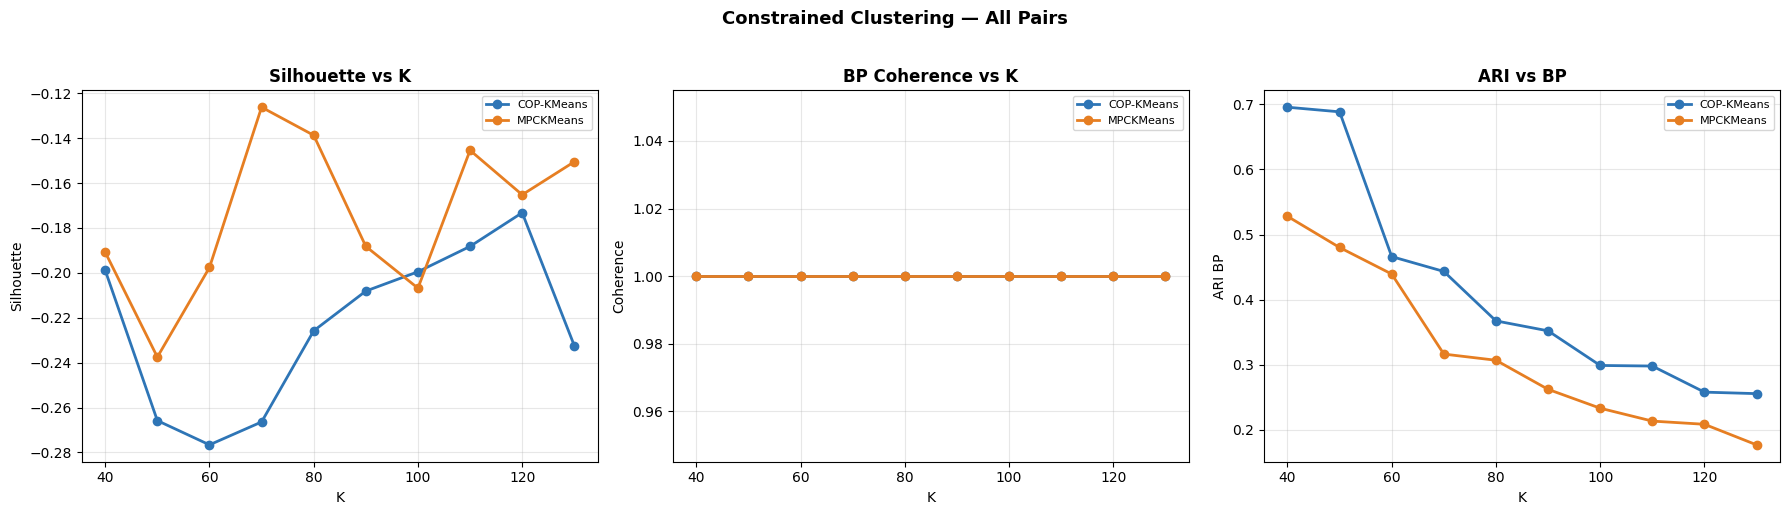

In [45]:
# CONSTRAINED CLUSTERING — Method 1: All-pairs cannot-links
# COP-KMeans + MPCKMeans  — WITH CHECKPOINT


_cp_allpairs = f'{CHECKPOINT_DIR}/cv_cop_allpairs.json'

def _save_allpairs(data):
    with open(_cp_allpairs, 'w') as _f:
        _json.dump(data, _f)

# Load existing checkpoint
if os.path.exists(_cp_allpairs):
    with open(_cp_allpairs) as _f:
        _cp_data = _json.load(_f)
    print(f'Checkpoint loaded: {len(_cp_data)} combinations already done.')
else:
    _cp_data = {}
    print('No checkpoint found — starting from scratch.')

print('\u2550'*60)
print('All-pairs cannot-links \u2014 COP-KMeans + MPCKMeans')
print(f'Total cannot-links: {len(cl_all):,}')
print('\u2550'*60)

# Re-populate results from checkpoint
results_all_pairs = []
for _key, _r in _cp_data.items():
    _r['labels'] = None  # labels not stored in checkpoint
    results_all_pairs.append(_r)

K_RANGE = range(40, 131, 10)

for method_name, use_mpc in [('COP-KMeans', False), ('MPCKMeans', True)]:
    print(f'Method: {method_name}')

    for k in K_RANGE:
        _key = f'{method_name}_K{k}'
        if _key in _cp_data:
            print(f'  K={k}... skipped (checkpoint)')
            continue

        try:
            print(f'  K={k}...', end=' ')
            t0 = time.time()

            if use_mpc:
                model  = MPCKMeans(n_clusters=k)
                model.fit(X_final, ml=[], cl=cl_all)
                labels = model.labels_
            else:
                labels, _ = cop_kmeans(
                    dataset = X_final,
                    k       = k,
                    ml      = [],
                    cl      = cl_all
                )
                if labels is None:
                    raise Exception('None result')
                labels = np.array(labels)

            elapsed = time.time() - t0
            r = eval_constrained(labels, X_final,
                                 f'{method_name} all-pairs K={k}')
            r['group'] = 'All pairs'
            r['time']  = round(elapsed, 1)
            results_all_pairs.append(r)
            print(f'({elapsed:.0f}s)')

            # Save checkpoint (without labels array)
            _cp_data[_key] = {k2: v for k2, v in r.items() if k2 != 'labels'}
            _save_allpairs(_cp_data)

        except Exception as e:
            print(f'failed: {e}')
            _r_fail = {
                'method':     f'{method_name} all-pairs K={k}',
                'group':      'All pairs',
                'n_clusters': k,
                'silhouette': float('nan'),
                'db':         float('nan'),
                'ari_bp':     float('nan'),
                'coherence':  float('nan'),
                'n_outliers': 0,
                'time':       float('nan'),
            }
            results_all_pairs.append({**_r_fail, 'labels': None})
            _cp_data[_key] = _r_fail
            _save_allpairs(_cp_data)

df_all_pairs = pd.DataFrame([{
    'Method':     r['method'],
    'K':          r['n_clusters'],
    'Silhouette': r['silhouette'],
    'Coherence':  r['coherence'],
    'ARI BP':     r['ari_bp'],
    'DB':         r['db'],
    'Time':       r.get('time', float('nan'))
} for r in results_all_pairs])

print('\n' + '\u2550'*80)
print('ALL PAIRS \u2014 RESULTS')
print('\u2550'*80)
print(df_all_pairs.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'COP-KMeans': '#2E75B6', 'MPCKMeans': '#E67E22'}

for method_name in ['COP-KMeans', 'MPCKMeans']:
    sub = df_all_pairs[
        df_all_pairs['Method'].str.startswith(method_name) &
        df_all_pairs['Silhouette'].notna()
    ]
    if sub.empty:
        continue
    axes[0].plot(sub['K'], sub['Silhouette'], 'o-',
                 color=colors[method_name], label=method_name, linewidth=2)
    axes[1].plot(sub['K'], sub['Coherence'], 'o-',
                 color=colors[method_name], label=method_name, linewidth=2)
    axes[2].plot(sub['K'], sub['ARI BP'], 'o-',
                 color=colors[method_name], label=method_name, linewidth=2)

for ax, title, ylabel in zip(
    axes,
    ['Silhouette vs K', 'BP Coherence vs K', 'ARI vs BP'],
    ['Silhouette', 'Coherence', 'ARI BP']
):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('K')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Constrained Clustering \u2014 All Pairs',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### CONSTRAINED CLUSTERING - Method 2: Smart cannot-links

COP-KMeans + MPCKMeans

Checkpoint loaded: 20 combinations already done.
════════════════════════════════════════════════════════════
Smart cannot-links — COP-KMeans + MPCKMeans
Total cannot-links: 85,809
════════════════════════════════════════════════════════════
Method: COP-KMeans
  K=40... skipped (checkpoint)
  K=50... skipped (checkpoint)
  K=60... skipped (checkpoint)
  K=70... skipped (checkpoint)
  K=80... skipped (checkpoint)
  K=90... skipped (checkpoint)
  K=100... skipped (checkpoint)
  K=110... skipped (checkpoint)
  K=120... skipped (checkpoint)
  K=130... skipped (checkpoint)
Method: MPCKMeans
  K=40... skipped (checkpoint)
  K=50... skipped (checkpoint)
  K=60... skipped (checkpoint)
  K=70... skipped (checkpoint)
  K=80... skipped (checkpoint)
  K=90... skipped (checkpoint)
  K=100... skipped (checkpoint)
  K=110... skipped (checkpoint)
  K=120... skipped (checkpoint)
  K=130... skipped (checkpoint)

════════════════════════════════════════════════════════════════════════════════
SMART CL — 

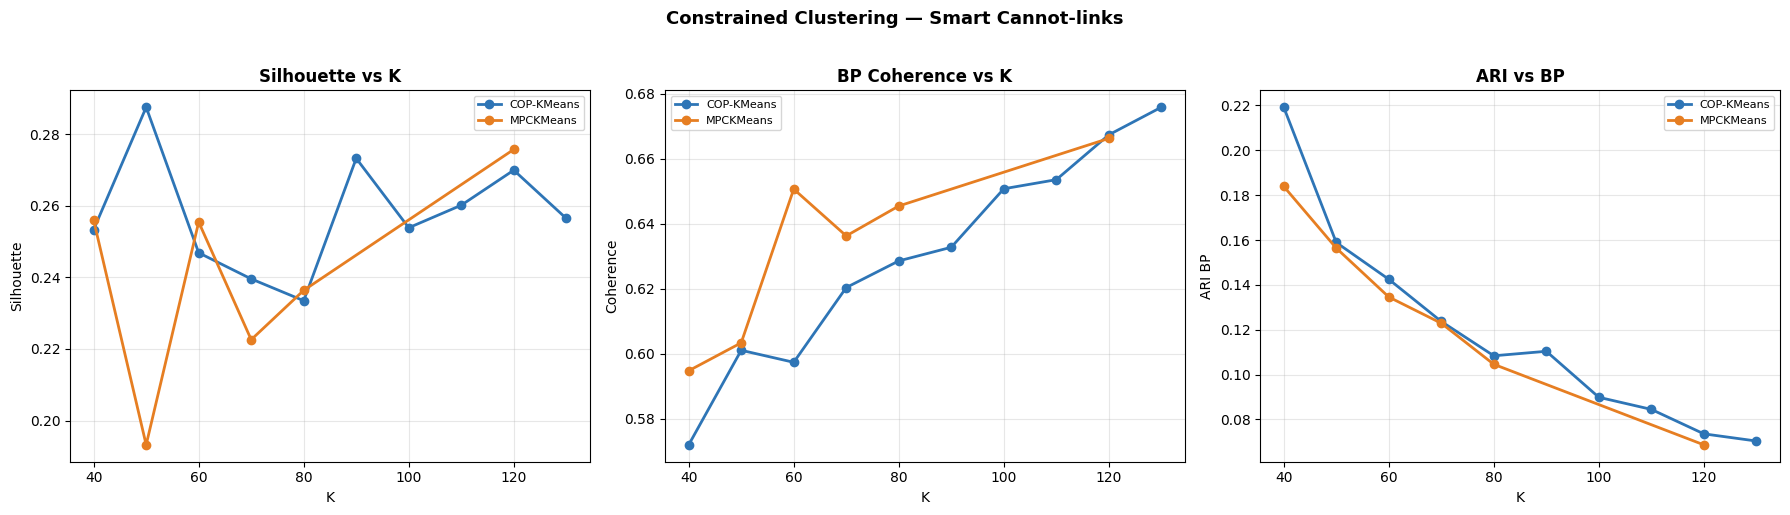

In [46]:
# CONSTRAINED CLUSTERING - Method 2: Smart cannot-links
# COP-KMeans + MPCKMeans  - WITH CHECKPOINT
# Only incompatible BP pairs - best balance between
# geometry quality and BP separation


_cp_smart = f'{CHECKPOINT_DIR}/cv_cop_smart.json'

def _save_smart(data):
    with open(_cp_smart, 'w') as _f:
        _json.dump(data, _f)

# Load existing checkpoint
if os.path.exists(_cp_smart):
    with open(_cp_smart) as _f:
        _cp_data_s = _json.load(_f)
    print(f'Checkpoint loaded: {len(_cp_data_s)} combinations already done.')
else:
    _cp_data_s = {}
    print('No checkpoint found — starting from scratch.')

print('\u2550'*60)
print('Smart cannot-links \u2014 COP-KMeans + MPCKMeans')
print(f'Total cannot-links: {len(cl_smart):,}')
print('\u2550'*60)

# Re-populate results from checkpoint
results_smart = []
for _key, _r in _cp_data_s.items():
    _r['labels'] = None
    results_smart.append(_r)

K_RANGE = range(40, 131, 10)

for method_name, use_mpc in [('COP-KMeans', False), ('MPCKMeans', True)]:
    print(f'Method: {method_name}')

    for k in K_RANGE:
        _key = f'{method_name}_K{k}'
        if _key in _cp_data_s:
            print(f'  K={k}... skipped (checkpoint)')
            continue

        try:
            print(f'  K={k}...', end=' ')
            t0 = time.time()

            if use_mpc:
                model = MPCKMeans(n_clusters=k)
                model.fit(X_final, ml=[], cl=cl_smart)
                labels = model.labels_
            else:
                labels, _ = cop_kmeans(
                    dataset = X_final,
                    k       = k,
                    ml      = [],
                    cl      = cl_smart
                )
                if labels is None:
                    raise Exception('None result')
                labels = np.array(labels)

            elapsed = time.time() - t0
            r = eval_constrained(labels, X_final,
                                 f'{method_name} smart K={k}')
            r['group'] = 'Smart CL'
            r['time']  = round(elapsed, 1)
            results_smart.append(r)
            print(f'({elapsed:.0f}s)')

            _cp_data_s[_key] = {k2: v for k2, v in r.items() if k2 != 'labels'}
            _save_smart(_cp_data_s)

        except Exception as e:
            print(f'failed: {e}')
            _r_fail = {
                'method':     f'{method_name} smart K={k}',
                'group':      'Smart CL',
                'n_clusters': k,
                'silhouette': float('nan'),
                'db':         float('nan'),
                'ari_bp':     float('nan'),
                'coherence':  float('nan'),
                'n_outliers': 0,
                'time':       float('nan'),
            }
            results_smart.append({**_r_fail, 'labels': None})
            _cp_data_s[_key] = _r_fail
            _save_smart(_cp_data_s)

# \u2500\u2500 Results table
df_smart = pd.DataFrame([{
    'Method':     r['method'],
    'K':          r['n_clusters'],
    'Silhouette': r['silhouette'],
    'Coherence':  r['coherence'],
    'ARI BP':     r['ari_bp'],
    'DB':         r['db'],
    'Time':       r.get('time', float('nan'))
} for r in results_smart])

print('\n' + '\u2550'*80)
print('SMART CL \u2014 RESULTS')
print('\u2550'*80)
print(df_smart.to_string(index=False))

# \u2500\u2500 Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'COP-KMeans': '#2E75B6', 'MPCKMeans': '#E67E22'}

for method_name in ['COP-KMeans', 'MPCKMeans']:
    sub = df_smart[
        df_smart['Method'].str.startswith(method_name) &
        df_smart['Silhouette'].notna()
    ]
    if sub.empty:
        continue
    axes[0].plot(sub['K'], sub['Silhouette'], 'o-',
                 color=colors[method_name], label=method_name, linewidth=2)
    axes[1].plot(sub['K'], sub['Coherence'], 'o-',
                 color=colors[method_name], label=method_name, linewidth=2)
    axes[2].plot(sub['K'], sub['ARI BP'], 'o-',
                 color=colors[method_name], label=method_name, linewidth=2)

for ax, title, ylabel in zip(
    axes,
    ['Silhouette vs K', 'BP Coherence vs K', 'ARI vs BP'],
    ['Silhouette', 'Coherence', 'ARI BP']
):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('K')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Constrained Clustering \u2014 Smart Cannot-links',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### COP-KMeans smart — Final clustering K=50

In [47]:
COP_K_FINAL = 50

print(f'Running COP-KMeans smart K={COP_K_FINAL}...')
t0 = time.time()

labels_cop_final, _ = cop_kmeans(
    dataset = X_final,
    k       = COP_K_FINAL,
    ml      = [],
    cl      = cl_smart
)
labels_cop_final = np.array(labels_cop_final)

print(f'Done in {time.time()-t0:.0f}s')
r_cop_final = eval_constrained(labels_cop_final, X_final, f'COP-KMeans smart K={COP_K_FINAL}')

Running COP-KMeans smart K=50...
Done in 125s

  [COP-KMeans smart K=50]
    Clusters:   50
    Outliers:   0 (0.0%)
    Silhouette: 0.2989
    DB score:   2.1713
    ARI vs BP:  0.1692
    Coherence:  60.7%


In [48]:
# EXPORT — COP-KMeans smart clusters: job titles + t-codes

os.makedirs('output phase2 JT', exist_ok=True)

# TF-IDF dataframe
tfidf_dense = X_tfidf.toarray()
df_tfidf = pd.DataFrame(
    tfidf_dense,
    index   = matrix_train_log.index,
    columns = matrix_train_log.columns
)

# Columnas comunes
common_tcodes = usage_matrix.columns.intersection(df_tfidf.columns)

# BP map
bp_map_export = df_jt_metadata.set_index('JOB_TITLE')['BUSINESS PROCESS'].to_dict()
n_users_map   = df_jt_metadata.set_index('JOB_TITLE')['N_USERS'].to_dict()

output_rows = []

for cluster_id in sorted(np.unique(labels_cop_final)):

    # Job titles en este cluster
    jts_in_cluster = [jt_list[i] for i in range(len(jt_list))
                      if labels_cop_final[i] == cluster_id]

    for jt in jts_in_cluster:
        output_rows.append({
            'CLUSTER_ID':        cluster_id,
            'TYPE':              'JOB_TITLE',
            'NAME':              jt,
            'BUSINESS_PROCESS':  bp_map_export.get(jt, ''),
            'N_USERS':           int(n_users_map.get(jt, 0)),
            'PCT_JT_USING':      '',
            'AVG_FREQ':          '',
            'TFIDF_WEIGHT':      '',
            'JT_USING':          '',
        })

    # T-codes del cluster
    jts_in_usage = [jt for jt in jts_in_cluster if jt in usage_matrix.index]
    jts_in_tfidf = [jt for jt in jts_in_cluster if jt in df_tfidf.index]
    n_jts_total  = len(jts_in_usage)

    if n_jts_total > 0:
        X_cluster    = usage_matrix.loc[jts_in_usage, common_tcodes]
        tfidf_weight = (
            df_tfidf.loc[jts_in_tfidf, common_tcodes].mean(axis=0)
            if jts_in_tfidf
            else pd.Series(0, index=common_tcodes)
        )

        pct_using = (X_cluster > 0).sum(axis=0) / n_jts_total
        avg_freq  = X_cluster.mean(axis=0)

        jt_using_tcode = {
            tcode: ', '.join([
                jt for jt in jts_in_usage
                if X_cluster.loc[jt, tcode] > 0
            ])
            for tcode in common_tcodes
        }

        df_tcodes = pd.DataFrame({
            'PCT_JT_USING': pct_using,
            'AVG_FREQ':     avg_freq,
            'TFIDF_WEIGHT': tfidf_weight,
        })
        df_tcodes = df_tcodes[df_tcodes['PCT_JT_USING'] > 0]
        df_tcodes = df_tcodes.sort_values('PCT_JT_USING', ascending=False)

        for tcode, row in df_tcodes.iterrows():
            output_rows.append({
                'CLUSTER_ID':        cluster_id,
                'TYPE':              'TCODE',
                'NAME':              tcode,
                'BUSINESS_PROCESS':  '',
                'N_USERS':           '',
                'PCT_JT_USING':      round(row['PCT_JT_USING'], 4),
                'AVG_FREQ':          round(row['AVG_FREQ'], 2),
                'TFIDF_WEIGHT':      round(row['TFIDF_WEIGHT'], 4),
                'JT_USING':          jt_using_tcode.get(tcode, ''),
            })

# Build dataframe
df_export_cop = pd.DataFrame(output_rows)

# Export
export_path = 'output phase2 JT/cop_smart_clusters_export.xlsx'

with pd.ExcelWriter(export_path, engine='openpyxl') as writer:
    df_export_cop.to_excel(writer, sheet_name='Clusters', index=False)
    ws = writer.sheets['Clusters']
    for col in ws.columns:
        max_len = max(len(str(cell.value or '')) for cell in col)
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 2, 50)

print(f'Export done: {export_path}')
print(f'Total rows:      {len(df_export_cop):,}')
print(f'JOB_TITLE rows:  {(df_export_cop["TYPE"] == "JOB_TITLE").sum():,}')
print(f'TCODE rows:      {(df_export_cop["TYPE"] == "TCODE").sum():,}')
print(f'Clusters:        {df_export_cop["CLUSTER_ID"].nunique()}')

Export done: output phase2 JT/cop_smart_clusters_export.xlsx
Total rows:      8,833
JOB_TITLE rows:  796
TCODE rows:      8,037
Clusters:        50


### CONSTRAINED CLUSTERING - Method 3: Hierarchical

In [49]:
labels_hier     = np.full(n, -1)
cluster_counter = 0

for bp in sorted(set(b for b in bp_array if b is not None and not pd.isna(b))):
    idx = [i for i, b in enumerate(bp_array) if b == bp]
    n_bp = len(idx)

    if n_bp <= 3:
        # Too few — single cluster
        for i in idx:
            labels_hier[i] = cluster_counter
        cluster_counter += 1
        print(f'  {bp:<40} {n_bp:>4} JTs → 1 cluster')
    else:
        k_bp    = max(2, n_bp // 6)
        sub_lbl = KMeans(n_clusters=k_bp, random_state=RANDOM_STATE,
                         n_init=5, max_iter=200).fit_predict(X_final[idx])
        for i, lbl in zip(idx, sub_lbl):
            labels_hier[i] = cluster_counter + lbl
        cluster_counter += k_bp
        print(f'  {bp:<40} {n_bp:>4} JTs → {k_bp} clusters')

# Assign job titles without BP to nearest centroid
no_bp_idx = [i for i, b in enumerate(bp_array) if b is None or pd.isna(b)]
if no_bp_idx:
    valid_mask = labels_hier != -1
    unique_cl  = np.unique(labels_hier[valid_mask])
    centroids  = np.array([X_final[labels_hier == c].mean(axis=0)
                           for c in unique_cl])
    dists      = cosine_distances(X_final[no_bp_idx], centroids)
    for i, cl_id in zip(no_bp_idx, unique_cl[dists.argmin(axis=1)]):
        labels_hier[i] = cl_id
    print(f'\n  {len(no_bp_idx)} JTs without BP assigned to nearest centroid')

results_hier = eval_constrained(labels_hier, X_final, 'Hierarchical by BP')
results_hier['group'] = 'Hierarchical'

  ADMINISTRATION & GENERAL                   26 JTs → 4 clusters
  CUSTOMER SERVICE                           38 JTs → 6 clusters
  EXECUTIVE & PROJECT MANAGEMENT             30 JTs → 5 clusters
  FINANCE & CONTROLLING                      99 JTs → 16 clusters
  HUMAN RESOURCES                            31 JTs → 5 clusters
  IT & DIGITAL                               44 JTs → 7 clusters
  MAINTENANCE & ENGINEERING                  58 JTs → 9 clusters
  MANUFACTURING & PRODUCTION                 71 JTs → 11 clusters
  PROCUREMENT & SOURCING                     46 JTs → 7 clusters
  QUALITY & REGULATORY                       68 JTs → 11 clusters
  R&D & INNOVATION                           19 JTs → 3 clusters
  SALES & MARKETING                          90 JTs → 15 clusters
  SUPPLY CHAIN & LOGISTICS                  150 JTs → 25 clusters

  26 JTs without BP assigned to nearest centroid

  [Hierarchical by BP]
    Clusters:   124
    Outliers:   0 (0.0%)
    Silhouette: -0.1729
    DB 

### CONSTRAINED CLUSTERING — Method 4: HDBSCAN guided by smart CL

### CV for HDBSCAN guided by smart CL

### HDBSCAN GUIDED — Final clustering

mcs=5 ms=3  K=60±2  Sil=0.5253±0.0137  Coh=60.3%  Outliers=124  Seeds=3/3

In [50]:
# Hyperparameters
GUIDE_K_FINAL    = 40    # MPCKMeans guide clusters--< optimal for K-means
BOOST_FINAL      = 0.5  
MCS_FINAL        = 5    
MS_FINAL         = 4     

print('═'*60)
print('HDBSCAN GUIDED — Final clustering')
print(f'  Guide K:          {GUIDE_K_FINAL}')
print(f'  Boost:            {BOOST_FINAL}')
print(f'  min_cluster_size: {MCS_FINAL}')
print(f'  min_samples:      {MS_FINAL}')
print('═'*60)
from active_semi_clustering.exceptions import EmptyClustersException

max_retries = 20
for attempt in range(max_retries):
    np.random.seed(attempt * 7)
    try:
        model_guide_final = MPCKMeans(n_clusters=GUIDE_K_FINAL)
        model_guide_final.fit(X_final, ml=[], cl=cl_smart)
        labels_guide_final = model_guide_final.labels_
        print(f'OK en intento {attempt+1} — Groups: {len(np.unique(labels_guide_final))}')
        break
    except EmptyClustersException:
        print(f'Intento {attempt+1} falló, reintentando...')
else:
    print('Todos los intentos fallaron - prueba reducir GUIDE_K_FINAL')
# Step 1 — MPCKMeans guide
print('\nStep 1 — MPCKMeans guide...')
model_guide_final = MPCKMeans(n_clusters=GUIDE_K_FINAL)
model_guide_final.fit(X_final, ml=[], cl=cl_smart)
labels_guide_final = model_guide_final.labels_
print(f'  Groups: {len(np.unique(labels_guide_final))}')

# Step 2 — Guided distance matrix
print('Step 2 — Building guided distance matrix...')
dist_guided_final = cosine_distances(X_final).astype(np.float64)
for i in range(len(labels_guide_final)):
    for j in range(i+1, len(labels_guide_final)):
        if labels_guide_final[i] == labels_guide_final[j]:
            dist_guided_final[i,j] *= BOOST_FINAL
            dist_guided_final[j,i] *= BOOST_FINAL

# Step 3 — HDBSCAN
print('Step 3 — HDBSCAN...')
hdb_guided_final = hdbscan_lib.HDBSCAN(
    min_cluster_size         = MCS_FINAL,
    min_samples              = MS_FINAL,
    metric                   = 'precomputed',
    cluster_selection_method = 'eom'
)
labels_guided_final = hdb_guided_final.fit_predict(dist_guided_final)

# Reassign outliers
n_out = int((labels_guided_final == -1).sum())
if n_out > 0:
    valid_mask  = labels_guided_final != -1
    unique_cl   = np.unique(labels_guided_final[valid_mask])
    centroids   = np.array([X_final[labels_guided_final == c].mean(axis=0)
                             for c in unique_cl])
    outlier_idx = np.where(~valid_mask)[0]
    dists       = cosine_distances(X_final[outlier_idx], centroids)
    labels_guided_final[outlier_idx] = unique_cl[dists.argmin(axis=1)]
    print(f'  {n_out} outliers reassigned')

n_clusters_guided = len(np.unique(labels_guided_final))
print(f'\nClusters: {n_clusters_guided}')

# Evaluate
r_guided_final = eval_constrained(labels_guided_final, X_final, 'HDBSCAN guided final')

════════════════════════════════════════════════════════════
HDBSCAN GUIDED — Final clustering
  Guide K:          40
  Boost:            0.5
  min_cluster_size: 5
  min_samples:      4
════════════════════════════════════════════════════════════
OK en intento 1 — Groups: 40

Step 1 — MPCKMeans guide...
  Groups: 40
Step 2 — Building guided distance matrix...
Step 3 — HDBSCAN...
  155 outliers reassigned

Clusters: 51

  [HDBSCAN guided final]
    Clusters:   51
    Outliers:   0 (0.0%)
    Silhouette: 0.5318
    DB score:   0.6626
    ARI vs BP:  0.1094
    Coherence:  58.1%


### Export Final clustering

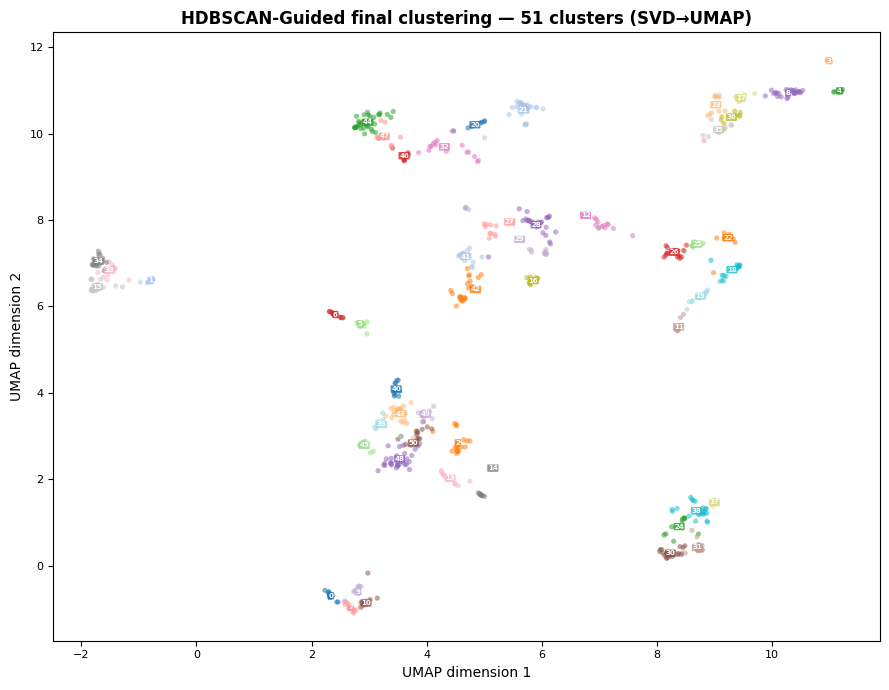

Saved figs/fig53_guided_umap.png


In [51]:
# FIG  UMAP scatter coloured by HDBSCAN-Guided clusters 

train_jts   = list(matrix_train_log.index)
n_train     = len(train_jts)
lbl_plot_g  = labels_guided_final          # shape (n_train,)
X2d         = X_umap_on_svd_2d[:n_train]

unique_cl_g = np.unique(lbl_plot_g)
K_guided    = len(unique_cl_g)

cmap20      = plt.cm.get_cmap('tab20', 20)
colors_g    = [cmap20(i % 20) for i in range(K_guided)]
color_map_g = {c: colors_g[i] for i, c in enumerate(unique_cl_g)}
pt_colors_g = [color_map_g[l] for l in lbl_plot_g]

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X2d[:, 0], X2d[:, 1],
           c=pt_colors_g, alpha=0.55, s=14, linewidths=0)

for c in unique_cl_g:
    mask = lbl_plot_g == c
    cx, cy = X2d[mask, 0].mean(), X2d[mask, 1].mean()
    ax.text(cx, cy, str(c), fontsize=5, ha='center', va='center',
            fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.1', fc=color_map_g[c], ec='none', alpha=0.8))

ax.set_title(f'HDBSCAN-Guided final clustering — {K_guided} clusters (SVD→UMAP)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('UMAP dimension 1', fontsize=10)
ax.set_ylabel('UMAP dimension 2', fontsize=10)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig('figs/fig53_guided_umap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/fig53_guided_umap.png')


In [52]:
# EXPORT — HDBSCAN Guided clusters: job titles + t-codes


os.makedirs('output phase2 JT', exist_ok=True)

# TF-IDF dataframe
tfidf_dense = X_tfidf.toarray()
df_tfidf = pd.DataFrame(
    tfidf_dense,
    index   = matrix_train_log.index,
    columns = matrix_train_log.columns
)

# Columnas comunes
common_tcodes = usage_matrix.columns.intersection(df_tfidf.columns)

# Maps
bp_map_export = df_jt_metadata.set_index('JOB_TITLE')['BUSINESS PROCESS'].to_dict()
n_users_map   = df_jt_metadata.set_index('JOB_TITLE')['N_USERS'].to_dict()

output_rows = []

for cluster_id in sorted(np.unique(labels_guided_final)):

    # Job titles en este cluster
    jts_in_cluster = [jt_list[i] for i in range(len(jt_list))
                      if labels_guided_final[i] == cluster_id]

    for jt in jts_in_cluster:
        output_rows.append({
            'CLUSTER_ID':       cluster_id,
            'TYPE':             'JOB_TITLE',
            'NAME':             jt,
            'BUSINESS_PROCESS': bp_map_export.get(jt, ''),
            'N_USERS':          int(n_users_map.get(jt, 0)),
            'PCT_JT_USING':     '',
            'AVG_FREQ':         '',
            'TFIDF_WEIGHT':     '',
            'JT_USING':         '',
        })

    # T-codes del cluster
    jts_in_usage = [jt for jt in jts_in_cluster if jt in usage_matrix.index]
    jts_in_tfidf = [jt for jt in jts_in_cluster if jt in df_tfidf.index]
    n_jts_total  = len(jts_in_usage)

    if n_jts_total > 0:
        X_cluster    = usage_matrix.loc[jts_in_usage, common_tcodes]
        tfidf_weight = (
            df_tfidf.loc[jts_in_tfidf, common_tcodes].mean(axis=0)
            if jts_in_tfidf
            else pd.Series(0, index=common_tcodes)
        )

        pct_using = (X_cluster > 0).sum(axis=0) / n_jts_total
        avg_freq  = X_cluster.mean(axis=0)

        jt_using_tcode = {
            tcode: ', '.join([
                jt for jt in jts_in_usage
                if X_cluster.loc[jt, tcode] > 0
            ])
            for tcode in common_tcodes
        }

        df_tcodes = pd.DataFrame({
            'PCT_JT_USING': pct_using,
            'AVG_FREQ':     avg_freq,
            'TFIDF_WEIGHT': tfidf_weight,
        })
        df_tcodes = df_tcodes[df_tcodes['PCT_JT_USING'] > 0]
        df_tcodes = df_tcodes.sort_values('PCT_JT_USING', ascending=False)

        for tcode, row in df_tcodes.iterrows():
            output_rows.append({
                'CLUSTER_ID':       cluster_id,
                'TYPE':             'TCODE',
                'NAME':             tcode,
                'BUSINESS_PROCESS': '',
                'N_USERS':          '',
                'PCT_JT_USING':     round(row['PCT_JT_USING'], 4),
                'AVG_FREQ':         round(row['AVG_FREQ'], 2),
                'TFIDF_WEIGHT':     round(row['TFIDF_WEIGHT'], 4),
                'JT_USING':         jt_using_tcode.get(tcode, ''),
            })

#  Build dataframe 
df_export_guided = pd.DataFrame(output_rows)

#  Export 
export_path = 'output phase2 JT/hdbscan_guided_clusters_export.xlsx'

with pd.ExcelWriter(export_path, engine='openpyxl') as writer:
    df_export_guided.to_excel(writer, sheet_name='Clusters', index=False)
    ws = writer.sheets['Clusters']
    for col in ws.columns:
        max_len = max(len(str(cell.value or '')) for cell in col)
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 2, 50)

print(f'Export done: {export_path}')
print(f'Total rows:      {len(df_export_guided):,}')
print(f'JOB_TITLE rows:  {(df_export_guided["TYPE"] == "JOB_TITLE").sum():,}')
print(f'TCODE rows:      {(df_export_guided["TYPE"] == "TCODE").sum():,}')
print(f'Clusters:        {df_export_guided["CLUSTER_ID"].nunique()}')

Export done: output phase2 JT/hdbscan_guided_clusters_export.xlsx
Total rows:      9,103
JOB_TITLE rows:  796
TCODE rows:      8,307
Clusters:        51


### CONSTRAINED FUZZY C-MEANS — Guided by smart cannot-links

In [53]:
# FUZZY C-MEANS WITH CANNOT-LINK CONSTRAINTS (FCMCL)
# KKT-based membership update — correct derivation


import scipy.sparse as sp
from scipy.spatial.distance import cdist

# Build cannot-link matrix
print('Building cannot-link matrix...')
n_jts = len(jt_list)
rows, cols, data = [], [], []
for i, j in cl_smart:
    if i < n_jts and j < n_jts:
        rows.extend([i, j])
        cols.extend([j, i])
        data.extend([1.0, 1.0])

CL_matrix = sp.csr_matrix((data, (rows, cols)), shape=(n_jts, n_jts))
print(f'Cannot-link matrix: {CL_matrix.shape}, nnz={CL_matrix.nnz:,}')

# FCMCL with KKT update
def fcm_cannot_link_kkt(X, n_clusters, cl_matrix,
                         m=2, lam=0.1, max_iter=200,
                         error=0.005, random_state=42,
                         verbose=False):
    """
    Fuzzy C-Means with Cannot-Link constraints.
    KKT-based membership update for m=2.

    Update rule derived from KKT conditions:
        u_ij = (mu_i - lam * (CL * u_j)_i) / (2 * d_ij)
        mu_i = (1 + lam * Σ_j (CL*u_j)_i / (2*d_ij)) / Σ_j 1/(2*d_ij)

    X:          data matrix (N x D)
    n_clusters: K
    cl_matrix:  sparse CL matrix (N x N)
    m:          fuzziness (must be 2 for KKT derivation)
    lam:        penalty weight
    """
    assert m == 2, "KKT derivation requires m=2"
    np.random.seed(random_state)
    N, D = X.shape
    K    = n_clusters

    # Initialize with Dirichlet
    u = np.random.dirichlet(np.ones(K), size=N).T  # (K, N)
    u = np.fmax(u, 1e-10)
    u = u / u.sum(axis=0, keepdims=True)

    for iteration in range(max_iter):
        u_old = u.copy()

        # Update centroids
        um        = u ** m                                    # (K, N)
        centroids = (um @ X) / um.sum(axis=1, keepdims=True) # (K, D)

        # Compute distances
        dist = cdist(X, centroids, metric='euclidean') ** 2  # (N, K)
        dist = np.fmax(dist, 1e-10)

        # Compute CL penalty term 
        # cl_penalty[i, j] = (CL * u_j)_i
        cl_penalty = np.zeros((N, K))
        for j in range(K):
            cl_penalty[:, j] = cl_matrix.dot(u[j, :])  # (N,)

        # KKT membership update
        # inv_2d[i,j] = 1 / (2 * d_ij)
        inv_2d = 1.0 / (2.0 * dist)  # (N, K)

        # cl_over_2d[i,j] = (CL * u_j)_i / (2 * d_ij)
        cl_over_2d = cl_penalty * inv_2d  # (N, K)

        # mu_i = (1 + lam * Σ_j cl_over_2d[i,j]) / Σ_j inv_2d[i,j]
        mu = (1.0 + lam * cl_over_2d.sum(axis=1)) / inv_2d.sum(axis=1)  # (N,)

        # u_ij = (mu_i - lam * cl_penalty[i,j]) / (2 * d_ij)
        u_new = (mu[:, np.newaxis] - lam * cl_penalty) * inv_2d  # (N, K)
        u_new = u_new.T  # (K, N)

        # Clip to [0, 1] and renormalize
        u_new = np.fmax(u_new, 0.0)
        col_sums = u_new.sum(axis=0, keepdims=True)
        col_sums = np.fmax(col_sums, 1e-10)
        u = u_new / col_sums

        # Convergence
        delta = np.max(np.abs(u - u_old))
        if verbose and iteration % 10 == 0:
            print(f'  Iter {iteration:3d}: delta={delta:.6f}')
        if delta < error:
            if verbose:
                print(f'  Converged at iteration {iteration}')
            break

    return centroids, u

# Lambda search first — find right penalty weight
print('\n' + '═'*60)
print('FCMCL — Lambda search (K=30 fixed)')
print('═'*60)

K_FIXED    = 30
LAM_RANGE  = [0.001, 0.005, 0.01, 0.05, 0.1]

for lam in LAM_RANGE:
    try:
        cntr, u = fcm_cannot_link_kkt(
            X_umap_on_svd_norm, K_FIXED, CL_matrix,
            m=2, lam=lam, max_iter=200, error=0.005,
            random_state=RANDOM_STATE, verbose=False
        )
        labels   = u.argmax(axis=0)
        n_ovlp   = sum(1 for i in range(len(jt_list))
                      if (u[:, i] >= FUZZY_THRESHOLD).sum() > 1)
        pct_ovlp = n_ovlp / len(jt_list)
        sil      = float(silhouette_score(
            X_umap_on_svd_norm, labels
        )) if len(np.unique(labels)) > 1 else np.nan

        xb = xie_beni(X_umap_on_svd_norm, u, cntr)

        print(f'  lam={lam:.3f}  Sil={sil:.4f}  '
              f'XB={xb:.2f}  Ovlp={pct_ovlp:.1%}')

    except Exception as e:
        print(f'  lam={lam:.3f}  failed: {e}')

print('\nChoose lam where Ovlp > 0% and Sil is reasonable')

Building cannot-link matrix...
Cannot-link matrix: (796, 796), nnz=171,618

════════════════════════════════════════════════════════════
FCMCL — Lambda search (K=30 fixed)
════════════════════════════════════════════════════════════
  lam=0.001  Sil=0.2497  XB=12.48  Ovlp=15.2%
  lam=0.005  Sil=0.2666  XB=53.50  Ovlp=14.8%
  lam=0.010  Sil=0.2618  XB=13.64  Ovlp=15.2%
  lam=0.050  Sil=0.2918  XB=20.29  Ovlp=11.7%
  lam=0.100  Sil=0.3279  XB=25.20  Ovlp=13.1%

Choose lam where Ovlp > 0% and Sil is reasonable


In [54]:
def check_violations(labels, jt_list, bp_map, INCOMPATIBLE_BPS):
    violations = 0
    total_cl   = 0
    for bp_a, bp_b in INCOMPATIBLE_BPS:
        jts_a = [i for i, jt in enumerate(jt_list) if bp_map.get(jt) == bp_a]
        jts_b = [i for i, jt in enumerate(jt_list) if bp_map.get(jt) == bp_b]
        for ia in jts_a:
            for ib in jts_b:
                total_cl += 1
                if labels[ia] == labels[ib]:
                    violations += 1
    return violations, total_cl

v, t = check_violations(labels, jt_list, bp_map, INCOMPATIBLE_BPS)
print(f'Violations: {v:,} / {t:,} ({v/t:.2%})')

Violations: 555 / 85,809 (0.65%)


In [55]:
# FCMCL — K search with optimal lambda=0.01  — WITH CHECKPOINT


_cp_fcmcl = f'{CHECKPOINT_DIR}/cv_fcmcl.json'

def _save_fcmcl(data):
    def _conv(o):
        import numpy as _np
        if isinstance(o, (_np.integer,)): return int(o)
        if isinstance(o, (_np.floating,)): return float(o)
        if isinstance(o, _np.ndarray): return o.tolist()
        return o
    with open(_cp_fcmcl, 'w') as _f:
        _json.dump(data, _f, default=_conv)

if os.path.exists(_cp_fcmcl):
    with open(_cp_fcmcl) as _f:
        cv_fcmcl = _json.load(_f)
    _done_k = {r['K'] for r in cv_fcmcl}
    print(f'    Checkpoint loaded — K values done: {sorted(_done_k)}')
else:
    cv_fcmcl = []
    _done_k  = set()

print('═'*60)
print('FCMCL — K search (lambda=0.01)')
print('═'*60)

K_RANGE_FCMCL = [10, 20, 30, 40, 50]
LAM_FINAL     = 0.01
kf_fcmcl      = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for K_TEST in K_RANGE_FCMCL:
    if K_TEST in _done_k:
        print(f'K={K_TEST} — already done, skipping')
        continue

    print(f'\nK={K_TEST}...')
    fold_xbs   = []
    fold_sils  = []
    fold_cohs  = []
    fold_ovlps = []
    fold_viols = []

    for fold_i, (tr_idx, te_idx) in enumerate(kf_fcmcl.split(X_umap_on_svd_norm)):
        X_tr = X_umap_on_svd_norm[tr_idx]
        X_te = X_umap_on_svd_norm[te_idx]
        cl_tr = CL_matrix[tr_idx, :][:, tr_idx]

        try:
            cntr, u_tr = fcm_cannot_link_kkt(
                X_tr, K_TEST, cl_tr,
                m=2, lam=LAM_FINAL,
                max_iter=200, error=0.005,
                random_state=RANDOM_STATE,
                verbose=(fold_i == 0)
            )

            xb = xie_beni(X_tr, u_tr, cntr)
            fold_xbs.append(xb if np.isfinite(xb) else np.nan)

            u_te, *_ = fuzz.cluster.cmeans_predict(
                X_te.T, cntr, m=2, error=0.005, maxiter=200
            )
            labels_te = u_te.argmax(axis=0)
            sil, _, _, _ = eval_on_test(X_te, labels_te)

            jts_te   = [jt_list[i] for i in te_idx]
            n_ovlp   = sum(1 for i in range(len(jts_te))
                          if (u_te[:, i] >= FUZZY_THRESHOLD).sum() > 1)
            pct_ovlp = n_ovlp / len(jts_te)

            df_te = pd.DataFrame({'JOB_TITLE': jts_te, 'CLUSTER': labels_te}).merge(
                df_jt_metadata[['JOB_TITLE', bp_col]], on='JOB_TITLE', how='left')
            pureza_list = []
            for cl_id in np.unique(labels_te):
                sub = df_te[(df_te['CLUSTER'] == cl_id) & (df_te[bp_col].notna())]
                if len(sub) == 0: continue
                pureza_list.append(sub[bp_col].value_counts().iloc[0] / len(sub))
            coherence = np.mean(pureza_list) if pureza_list else np.nan

            jt_te_list = [jt_list[i] for i in te_idx]
            v, t = check_violations(labels_te, jt_te_list, bp_map, INCOMPATIBLE_BPS)
            pct_viol = v / t if t > 0 else 0

            fold_sils.append(sil if not np.isnan(sil) else np.nan)
            fold_cohs.append(coherence if not np.isnan(coherence) else np.nan)
            fold_ovlps.append(pct_ovlp)
            fold_viols.append(pct_viol)
            print(f'  Fold {fold_i+1}: XB={xb:.2f} Sil={sil:.3f} ')

        except Exception as e:
            print(f'  Fold {fold_i+1} failed: {e}')
            fold_xbs.append(np.nan); fold_sils.append(np.nan)
            fold_cohs.append(np.nan); fold_ovlps.append(np.nan)
            fold_viols.append(np.nan)

    row = {
        'K':          K_TEST,
        'XB mean':    round(np.nanmean(fold_xbs), 4),
        'XB std':     round(np.nanstd(fold_xbs), 4),
        'Sil mean':   round(np.nanmean(fold_sils), 4),
        'Sil std':    round(np.nanstd(fold_sils), 4),
        'Coherence':  f'{np.nanmean(fold_cohs):.1%}',
        'Overlap %':  f'{np.nanmean(fold_ovlps):.1%}',
        'Violations': f'{np.nanmean(fold_viols):.2%}',
    }
    cv_fcmcl.append(row)
    _save_fcmcl(cv_fcmcl)   # save after each K
    print(f'→ K={K_TEST} saved')

df_fcmcl = pd.DataFrame(cv_fcmcl)
best_k = int(df_fcmcl.loc[df_fcmcl['XB mean'].idxmin(), 'K'])
print('\n' + '═'*70)
print('FCMCL — CV RESULTS (sorted by XB mean)')
print('═'*70)
print(df_fcmcl.sort_values('XB mean').to_string(index=False))
print(f'\nBest K (min XB): {best_k}')


    Checkpoint loaded — K values done: [10, 20, 30, 40, 50]
════════════════════════════════════════════════════════════
FCMCL — K search (lambda=0.01)
════════════════════════════════════════════════════════════
K=10 — already done, skipping
K=20 — already done, skipping
K=30 — already done, skipping
K=40 — already done, skipping
K=50 — already done, skipping

══════════════════════════════════════════════════════════════════════
FCMCL — CV RESULTS (sorted by XB mean)
══════════════════════════════════════════════════════════════════════
 K  XB mean  XB std  Sil mean  Sil std Coherence Overlap % Violations
10   4.8013  3.6566    0.6588   0.0735     51.3%     11.5%      8.08%
30  18.6330 21.5394    0.4809   0.0368     60.7%     36.8%      1.97%
40  21.0326 18.6527    0.4537   0.0538     66.1%     38.1%      1.49%
20  21.7365 19.8580    0.5099   0.0458     54.8%     35.5%      3.71%
50  21.8537 17.8111    0.4291   0.0458     69.1%     31.4%      1.07%

Best K (min XB): 10


### Final FCMCL clustering

In [56]:
# FCMCL — Final clustering K=50, lambda=0.01

FCMCL_K_FINAL   = 50
FCMCL_LAM_FINAL = 0.01

print('═'*60)
print('FCMCL — Final clustering')
print(f'  K:      {FCMCL_K_FINAL}')
print(f'  Lambda: {FCMCL_LAM_FINAL}')
print('═'*60)

cntr_fcmcl, u_fcmcl = fcm_cannot_link_kkt(
    X_umap_on_svd_norm, FCMCL_K_FINAL, CL_matrix,
    m=2, lam=FCMCL_LAM_FINAL,
    max_iter=200, error=0.005,
    random_state=RANDOM_STATE,
    verbose=True
)

# Build overlapping assignments
fcmcl_communities = {}
for i, jt in enumerate(jt_list):
    memberships = u_fcmcl[:, i]
    clusters    = [k for k, m in enumerate(memberships)
                   if m >= FUZZY_THRESHOLD]
    if not clusters:
        clusters = [int(memberships.argmax())]
    fcmcl_communities[jt] = clusters

n_memberships = [len(v) for v in fcmcl_communities.values()]

print(f'\nFCMCL Final Results:')
print(f'  Communities:            {FCMCL_K_FINAL}')
print(f'  Threshold:              {FUZZY_THRESHOLD}')
print(f'  JTs in 1 community:     {sum(1 for v in fcmcl_communities.values() if len(v) == 1):,}')
print(f'  JTs in 2 communities:   {sum(1 for v in fcmcl_communities.values() if len(v) == 2):,}')
print(f'  JTs in 3+ communities:  {sum(1 for v in fcmcl_communities.values() if len(v) >= 3):,}')
print(f'  Mean communities/JT:    {np.mean(n_memberships):.2f}')

# Evaluate
labels_fcmcl = np.array([fcmcl_communities[jt][0] for jt in jt_list])

df_eval = pd.DataFrame({
    'JOB_TITLE': jt_list,
    'CLUSTER':   labels_fcmcl
}).merge(df_jt_metadata[['JOB_TITLE', bp_col]], on='JOB_TITLE', how='left')

pureza_list = []
for cl_id in np.unique(labels_fcmcl):
    sub = df_eval[(df_eval['CLUSTER'] == cl_id) & (df_eval[bp_col].notna())]
    if len(sub) == 0:
        continue
    pureza_list.append(sub[bp_col].value_counts().iloc[0] / len(sub))

coherence_fcmcl = np.mean(pureza_list)
sil_fcmcl       = float(silhouette_score(X_umap_on_svd_norm, labels_fcmcl))

v, t = check_violations(labels_fcmcl, jt_list, bp_map, INCOMPATIBLE_BPS)

print(f'\n  Silhouette:  {sil_fcmcl:.4f}')
print(f'  Coherence:   {coherence_fcmcl:.1%}')
print(f'  Violations:  {v:,} / {t:,} ({v/t:.2%})')


════════════════════════════════════════════════════════════
FCMCL — Final clustering
  K:      50
  Lambda: 0.01
════════════════════════════════════════════════════════════
  Iter   0: delta=0.164715
  Iter  10: delta=0.981484
  Iter  20: delta=0.999985
  Iter  30: delta=0.999990
  Iter  40: delta=0.999990
  Iter  50: delta=0.999990
  Iter  60: delta=0.999990
  Iter  70: delta=0.999990
  Iter  80: delta=0.999990
  Iter  90: delta=0.999990
  Iter 100: delta=0.999990
  Iter 110: delta=0.999990
  Iter 120: delta=0.999990
  Iter 130: delta=0.999990
  Iter 140: delta=0.999990
  Iter 150: delta=0.999990
  Iter 160: delta=0.999990
  Iter 170: delta=0.999990
  Iter 180: delta=0.999990
  Iter 190: delta=0.999990

FCMCL Final Results:
  Communities:            50
  Threshold:              0.2
  JTs in 1 community:     682
  JTs in 2 communities:   111
  JTs in 3+ communities:  3
  Mean communities/JT:    1.15

  Silhouette:  0.2396
  Coherence:   64.8%
  Violations:  301 / 85,809 (0.35%)


### Export 

In [57]:
os.makedirs('output phase2 JT', exist_ok=True)

with open('output phase2 JT/fcmcl_communities.pkl', 'wb') as f:
    pickle.dump(fcmcl_communities, f)

df_fcmcl_overlap = pd.DataFrame({
    'JOB_TITLE':       jt_list,
    'COMMUNITIES':     [fcmcl_communities[jt] for jt in jt_list],
    'N_COMMUNITIES':   [len(fcmcl_communities[jt]) for jt in jt_list],
    'PRIMARY_CLUSTER': [fcmcl_communities[jt][0] for jt in jt_list],
    'MAX_MEMBERSHIP':  [float(u_fcmcl[:, i].max()) for i, _ in enumerate(jt_list)]
})

df_fcmcl_overlap.to_csv('output phase2 JT/fcmcl_overlap_results.csv', index=False)

print(f'\n  Pickle saved: fcmcl_communities.pkl')
print(f'  CSV saved:    fcmcl_overlap_results.csv')
print(f'\ndf_fcmcl_overlap: {df_fcmcl_overlap.shape}')
print(df_fcmcl_overlap.head(10))


  Pickle saved: fcmcl_communities.pkl
  CSV saved:    fcmcl_overlap_results.csv

df_fcmcl_overlap: (796, 5)
                              JOB_TITLE COMMUNITIES  N_COMMUNITIES  \
0                     Account Assistant         [7]              1   
1               Account Payable Analyst        [47]              1   
2            Account Receivable Officer         [7]              1   
3                   Account Receivables         [7]              1   
4                            Accountant         [1]              1   
5                            Accounting         [1]              1   
6  Accounting & Einf Manager Human Food         [1]              1   
7     Accounting & Einf Manager Petfood         [1]              1   
8                Accounting Coordinator         [1]              1   
9      Accounting Interc & Fixed Assets         [1]              1   

   PRIMARY_CLUSTER  MAX_MEMBERSHIP  
0                7        0.885959  
1               47        0.946227  
2        

In [58]:
# EXPORT — FCMCL clusters: job titles + t-codes per cluster

os.makedirs('output phase2 JT', exist_ok=True)

# TF-IDF dataframe
tfidf_dense = X_tfidf.toarray()
df_tfidf = pd.DataFrame(
    tfidf_dense,
    index   = matrix_train_log.index,
    columns = matrix_train_log.columns
)

# Columnas comunes
common_tcodes = usage_matrix.columns.intersection(df_tfidf.columns)

# Maps
bp_map_export  = df_jt_metadata.set_index('JOB_TITLE')['BUSINESS PROCESS'].to_dict()
n_users_map    = df_jt_metadata.set_index('JOB_TITLE')['N_USERS'].to_dict()

output_rows = []

for cluster_id in sorted(set(
    c for communities in fcmcl_communities.values() for c in communities
)):
    # ── Job titles en este cluster ────────────────────────────
    jts_in_cluster = [
        jt for jt in jt_list
        if cluster_id in fcmcl_communities[jt]
    ]

    for jt in jts_in_cluster:
        n_communities  = len(fcmcl_communities[jt])
        membership     = float(u_fcmcl[cluster_id, jt_list.index(jt)])

        output_rows.append({
            'CLUSTER_ID':        cluster_id,
            'TYPE':              'JOB_TITLE',
            'NAME':              jt,
            'BUSINESS_PROCESS':  bp_map_export.get(jt, ''),
            'N_USERS':           int(n_users_map.get(jt, 0)),
            'MEMBERSHIP':        round(membership, 4),
            'N_COMMUNITIES':     n_communities,
            'PCT_JT_USING':      '',
            'AVG_FREQ':          '',
            'TFIDF_WEIGHT':      '',
            'JT_USING':          '',
        })

    # ── T-codes del cluster ───────────────────────────────────
    jts_in_usage = [jt for jt in jts_in_cluster if jt in usage_matrix.index]
    jts_in_tfidf = [jt for jt in jts_in_cluster if jt in df_tfidf.index]
    n_jts_total  = len(jts_in_usage)

    if n_jts_total > 0:
        X_cluster    = usage_matrix.loc[jts_in_usage, common_tcodes]
        tfidf_weight = (
            df_tfidf.loc[jts_in_tfidf, common_tcodes].mean(axis=0)
            if jts_in_tfidf
            else pd.Series(0, index=common_tcodes)
        )

        pct_using = (X_cluster > 0).sum(axis=0) / n_jts_total
        avg_freq  = X_cluster.mean(axis=0)

        jt_using_tcode = {
            tcode: ', '.join([
                jt for jt in jts_in_usage
                if X_cluster.loc[jt, tcode] > 0
            ])
            for tcode in common_tcodes
        }

        df_tcodes = pd.DataFrame({
            'PCT_JT_USING': pct_using,
            'AVG_FREQ':     avg_freq,
            'TFIDF_WEIGHT': tfidf_weight,
        })
        df_tcodes = df_tcodes[df_tcodes['PCT_JT_USING'] > 0]
        df_tcodes = df_tcodes.sort_values('PCT_JT_USING', ascending=False)

        for tcode, row in df_tcodes.iterrows():
            output_rows.append({
                'CLUSTER_ID':        cluster_id,
                'TYPE':              'TCODE',
                'NAME':              tcode,
                'BUSINESS_PROCESS':  '',
                'N_USERS':           '',
                'MEMBERSHIP':        '',
                'N_COMMUNITIES':     '',
                'PCT_JT_USING':      round(row['PCT_JT_USING'], 4),
                'AVG_FREQ':          round(row['AVG_FREQ'], 2),
                'TFIDF_WEIGHT':      round(row['TFIDF_WEIGHT'], 4),
                'JT_USING':          jt_using_tcode.get(tcode, ''),
            })

# Build dataframe
df_export_fcmcl = pd.DataFrame(output_rows)

# Export 
export_path = 'output phase2 JT/fcmcl_clusters_export.xlsx'

with pd.ExcelWriter(export_path, engine='openpyxl') as writer:
    df_export_fcmcl.to_excel(writer, sheet_name='Clusters', index=False)
    ws = writer.sheets['Clusters']
    for col in ws.columns:
        max_len = max(len(str(cell.value or '')) for cell in col)
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 2, 50)

print(f'Export done: {export_path}')
print(f'Total rows:      {len(df_export_fcmcl):,}')
print(f'JOB_TITLE rows:  {(df_export_fcmcl["TYPE"] == "JOB_TITLE").sum():,}')
print(f'TCODE rows:      {(df_export_fcmcl["TYPE"] == "TCODE").sum():,}')
print(f'Clusters:        {df_export_fcmcl["CLUSTER_ID"].nunique()}')

Export done: output phase2 JT/fcmcl_clusters_export.xlsx
Total rows:      9,461
JOB_TITLE rows:  913
TCODE rows:      8,548
Clusters:        50


---
## Visualisations for TFG
Figures for Chapter 5. Run after completing the full clustering pipeline.

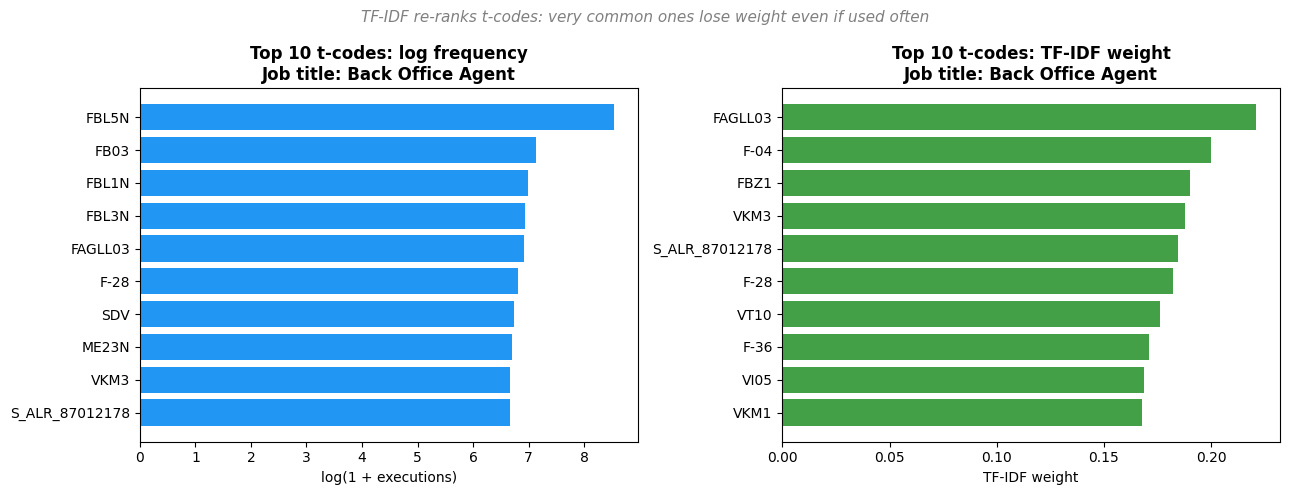

Saved figs/fig02_tfidf_user_comparison.png


In [59]:

# FIG TF-IDF re-ranking example (Back Office Agent)
# Shows how TF-IDF changes which t-codes are considered important

os.makedirs('figs', exist_ok=True)

example_jt = 'Back Office Agent'
if example_jt not in matrix_train_log.index:
    example_jt = matrix_train_log.index[0]  # fallback
    print(f'Back Office Agent not found — using {example_jt}')

raw_row    = matrix_train_log.loc[example_jt]
tfidf_row  = pd.Series(
    tfidf.transform(matrix_train_log.loc[[example_jt]].values).toarray()[0],
    index=matrix_train_log.columns
)

top_raw   = raw_row[raw_row > 0].nlargest(10)
top_tfidf = tfidf_row[tfidf_row > 0].nlargest(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('TF-IDF re-ranks t-codes: very common ones lose weight even if used often',
             fontsize=11, style='italic', color='gray')

ax1.barh(range(len(top_raw)), np.log1p(top_raw.values), color='#2196F3')
ax1.set_yticks(range(len(top_raw)))
ax1.set_yticklabels(top_raw.index)
ax1.invert_yaxis()
ax1.set_xlabel('log(1 + executions)')
ax1.set_title(f'Top 10 t-codes: log frequency\nJob title: {example_jt}', fontweight='bold')

ax2.barh(range(len(top_tfidf)), top_tfidf.values, color='#43A047')
ax2.set_yticks(range(len(top_tfidf)))
ax2.set_yticklabels(top_tfidf.index)
ax2.invert_yaxis()
ax2.set_xlabel('TF-IDF weight')
ax2.set_title(f'Top 10 t-codes: TF-IDF weight\nJob title: {example_jt}', fontweight='bold')

plt.tight_layout()
plt.savefig('figs/fig02_tfidf_user_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/fig02_tfidf_user_comparison.png')

Loaded cv_kmeans from checkpoint
Loaded cv_bkmeans from checkpoint
Loaded cv_gmm from checkpoint
Loaded cv_hdbscan from checkpoint


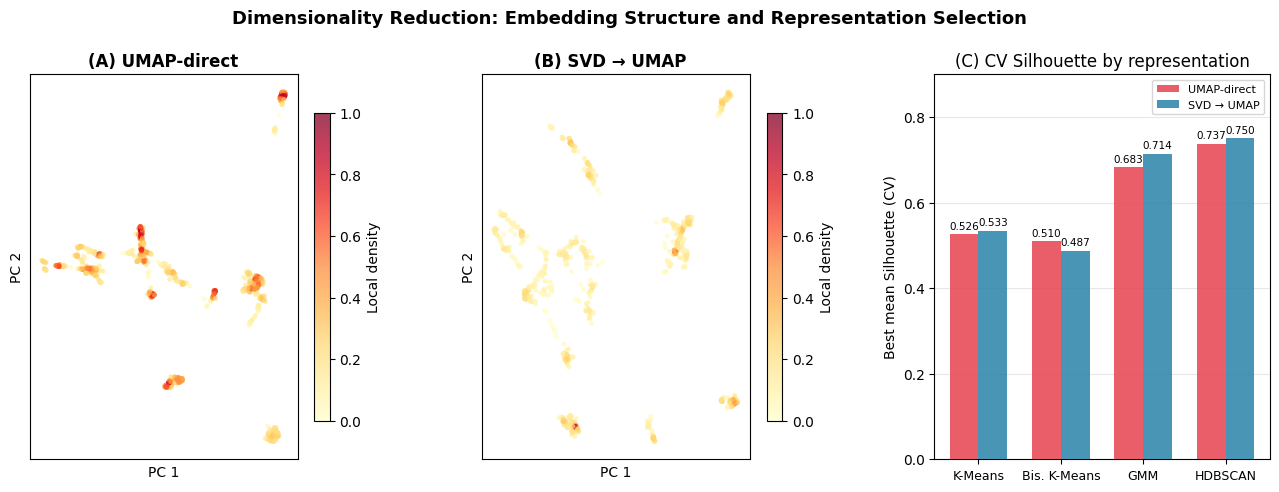

Saved figs/figNEW_repr_selection.png


In [60]:
# FIG Dimensionality reduction comparison
# UMAP-direct vs SVD→UMAP embeddings + CV Silhouette comparison


def density_color(X2d, k=15):
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X2d)
    dists, _ = nbrs.kneighbors(X2d)
    dens = 1.0 / (dists[:, 1:].mean(axis=1) + 1e-6)
    return (dens - dens.min()) / (dens.max() - dens.min())

u2d_direct  = PCA(n_components=2, random_state=42).fit_transform(X_umap_direct_norm)
u2d_svdumap = PCA(n_components=2, random_state=42).fit_transform(X_umap_on_svd_norm)

# CV best silhouette per method per representation
def best_sil_repr(cv_dict, repr_key):
    data = cv_dict.get(repr_key, {})
    all_scores = []
    for mk, kdict in data.items():
        for param, fold_scores in kdict.items():
            valid = [s for s in fold_scores if s == s]
            if valid: all_scores.append(np.mean(valid))
    return max(all_scores) if all_scores else np.nan



# Load CV checkpoints if not already in memory
_cp_dir = CHECKPOINT_DIR  # defined in cell 3
for _var, _fname in [('cv_kmeans','cv_kmeans.json'), ('cv_bkmeans','cv_bkmeans.json'),
                     ('cv_gmm','cv_gmm.json'), ('cv_hdbscan','cv_hdbscan.json')]:
    if _var not in dir() or eval(_var) is None:
        _path = f'{_cp_dir}/{_fname}'
        if _os.path.exists(_path):
            with open(_path) as _f:
                exec(f'{_var} = _json.load(_f)')
            print(f'Loaded {_var} from checkpoint')
        else:
            print(f'WARNING: {_path} not found')

_cv_files = {'K-Means': cv_kmeans, 'Bis. K-Means': cv_bkmeans,
             'GMM': cv_gmm, 'HDBSCAN': cv_hdbscan}
# cv_kmeans, cv_bkmeans, etc. must be loaded (from checkpoints in cell 39)
repr_labels, direct_vals, svd_vals = [], [], []
for label, cv in _cv_files.items():
    repr_labels.append(label)
    direct_vals.append(best_sil_repr(cv, 'UMAP_direct'))
    svd_vals.append(best_sil_repr(cv, 'SVD_UMAP'))

fig = plt.figure(figsize=(16, 5))
gs  = fig.add_gridspec(1, 3, wspace=0.35)

for ax_i, (X2d, dens, title) in enumerate([
    (u2d_direct,  density_color(u2d_direct),  '(A) UMAP-direct'),
    (u2d_svdumap, density_color(u2d_svdumap), '(B) SVD → UMAP  '),
]):
    ax = fig.add_subplot(gs[ax_i])
    sc = ax.scatter(X2d[:,0], X2d[:,1], c=dens, cmap='YlOrRd', s=12, alpha=0.75, linewidths=0)
    plt.colorbar(sc, ax=ax, shrink=0.8, label='Local density')
    ax.set_title(title, fontweight='bold' if ' ' in title else 'normal')
    ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
    ax.set_xticks([]); ax.set_yticks([])

ax = fig.add_subplot(gs[2])
x = np.arange(len(repr_labels)); w = 0.35
b1 = ax.bar(x - w/2, direct_vals, w, label='UMAP-direct', color='#E84855', alpha=0.88, zorder=3)
b2 = ax.bar(x + w/2, svd_vals,    w, label='SVD → UMAP',  color='#2E86AB', alpha=0.88, zorder=3)
for bar in list(b1)+list(b2):
    h = bar.get_height()
    if h == h: ax.text(bar.get_x()+bar.get_width()/2, h+0.008, f'{h:.3f}',
                       ha='center', va='bottom', fontsize=7.5)
ax.set_xticks(x); ax.set_xticklabels(repr_labels, fontsize=9)
ax.set_ylabel('Best mean Silhouette (CV)')
ax.set_title('(C) CV Silhouette by representation')
ax.legend(fontsize=8); ax.yaxis.grid(True, alpha=0.3, zorder=0); ax.set_axisbelow(True)
ax.set_ylim(0, max([v for v in direct_vals+svd_vals if v==v])*1.2)

plt.suptitle('Dimensionality Reduction: Embedding Structure and Representation Selection',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('figs/figNEW_repr_selection.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved figs/figNEW_repr_selection.png')

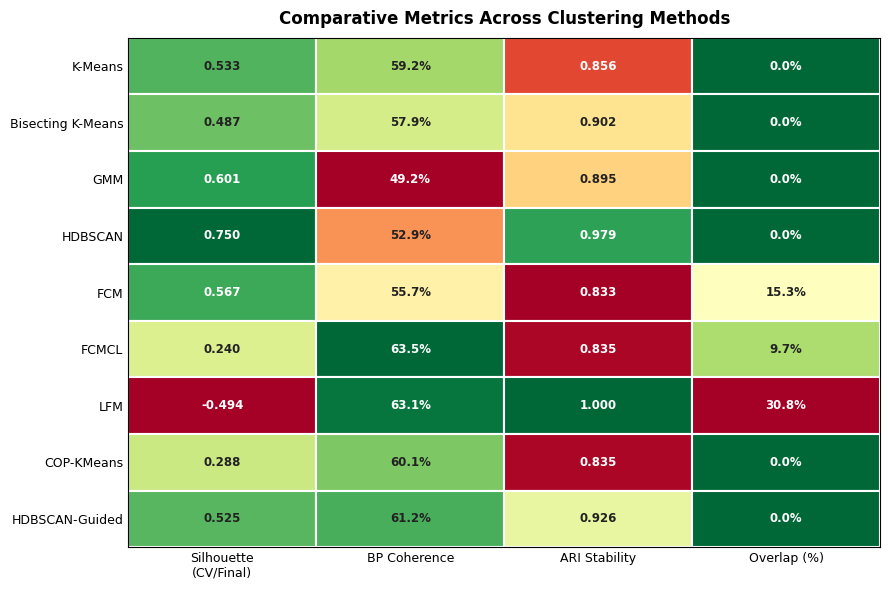

Saved figs/figA_comparison_heatmap.png  (9 methods)


In [61]:
# FIG: Normalised metric heatmap — ALL methods, complete data


# Master data table (9 methods)
# Columns: Silhouette | BP Coherence | ARI Stability (seed) | Overlap %
# COP-KMeans ARI stability: update from cell 110 output when available
methods_hm = [
    'K-Means','Bisecting K-Means','GMM','HDBSCAN',
    'FCM','FCMCL','LFM',
    'COP-KMeans','HDBSCAN-Guided',
]
families_hm = [
    'Non-overlapping','Non-overlapping','Non-overlapping','Non-overlapping',
    'Overlapping','Constrained','Overlapping',
    'Constrained','Guided',
]
# Rows: [Silhouette, BP Coherence, ARI Stability, Overlap%]
data_raw = np.array([
    [ 0.533, 0.592, 0.856,  0.0],   # K-Means
    [ 0.487, 0.579, 0.902,  0.0],   # Bisecting K-Means
    [ 0.601, 0.492, 0.895,  0.0],   # GMM
    [ 0.750, 0.529, 0.979,  0.0],   # HDBSCAN
    [ 0.567, 0.557, 0.833, 15.3],   # FCM
    [ 0.240, 0.635, 0.835,  9.7],   # FCMCL
    [-0.494, 0.631, 1.000, 30.8],   # LFM
    [ 0.288, 0.601, 0.835,  0.0],   # COP-KMeans  (ARI: update from cell 110)
    [ 0.525, 0.612, 0.926,  0.0],   # HDBSCAN-Guided
], dtype=float)

col_labels         = ['Silhouette\n(CV/Final)','BP Coherence','ARI Stability','Overlap (%)']
col_higher_better  = [True, True, True, False]

# Normalise per column
data_norm = np.zeros_like(data_raw)
for c in range(data_raw.shape[1]):
    col = data_raw[:, c]
    mn, mx = col.min(), col.max()
    norm = (col - mn) / (mx - mn) if mx > mn else np.full_like(col, 0.5)
    data_norm[:, c] = norm if col_higher_better[c] else 1 - norm

# Plot
n_methods, n_cols = data_raw.shape
fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.cm.RdYlGn
for r in range(n_methods):
    for c in range(n_cols):
        color  = cmap(data_norm[r, c])
        ax.add_patch(plt.Rectangle((c, n_methods-1-r), 1, 1,
                                   color=color, ec='white', lw=1.5))
        v = data_raw[r, c]
        txt = (f'{v*100:.1f}%' if c == 1 else
               f'{v:.1f}%'   if c == 3 else
               f'{v:.3f}')
        brightness = 0.299*color[0] + 0.587*color[1] + 0.114*color[2]
        fc = 'white' if brightness < 0.5 else '#222222'
        ax.text(c+0.5, n_methods-0.5-r, txt, ha='center', va='center',
                fontsize=8.5, fontweight='bold', color=fc)

ax.set_xlim(0, n_cols); ax.set_ylim(0, n_methods)
ax.set_xticks(np.arange(n_cols)+0.5); ax.set_xticklabels(col_labels, fontsize=9)
ax.set_yticks(np.arange(n_methods)+0.5)
ax.set_yticklabels(list(reversed(methods_hm)), fontsize=9)
ax.set_title('Comparative Metrics Across Clustering Methods',
             fontsize=12, fontweight='bold', pad=10)
ax.tick_params(length=0)
plt.tight_layout()
plt.savefig('figs/figA_comparison_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved figs/figA_comparison_heatmap.png  ({n_methods} methods)')


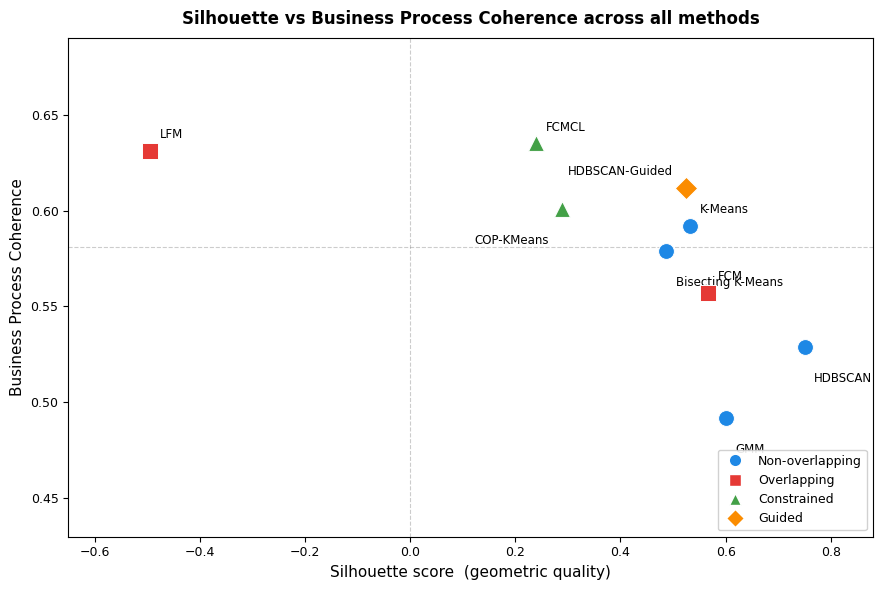

Saved figs/fig53_sil_vs_coh.png


In [64]:
# FIG Silhouette vs BP Coherence scatter

fam_colors = {
    'Non-overlapping': '#1E88E5',
    'Overlapping':     '#E53935',
    'Constrained':     '#43A047',
    'Guided':          '#FB8C00',
}
fam_markers = {
    'Non-overlapping': 'o',
    'Overlapping':     's',
    'Constrained':     '^',
    'Guided':          'D',
}
# Label offsets: (dx, dy, ha, va) per method
offsets = {
    'K-Means':          ( 0.018,  0.005, 'left',  'bottom'),
    'Bisecting K-Means':( 0.018, -0.013, 'left',  'top'),
    'GMM':              ( 0.018, -0.013, 'left',  'top'),
    'HDBSCAN':          ( 0.018, -0.013, 'left',  'top'),
    'FCM':              ( 0.018,  0.005, 'left',  'bottom'),
    'FCMCL':            ( 0.018,  0.005, 'left',  'bottom'),
    'LFM':              ( 0.018,  0.005, 'left',  'bottom'),
    'COP-KMeans':       (-0.025, -0.013, 'right', 'top'),
    'HDBSCAN-Guided':   (-0.025,  0.005, 'right', 'bottom'),
}

fig, ax = plt.subplots(figsize=(9, 6))
for m, fam, row in zip(methods_hm, families_hm, data_raw):
    s, c = row[0], row[1]
    ax.scatter(s, c, color=fam_colors[fam], marker=fam_markers[fam],
               s=130, zorder=3, edgecolors='white', linewidths=0.7)
    dx, dy, ha, va = offsets.get(m, (0.018, 0.005, 'left', 'bottom'))
    ax.annotate(m, (s, c), xytext=(s+dx, c+dy), fontsize=8.5, ha=ha, va=va)

ax.axvline(0, color='grey', lw=0.8, ls='--', alpha=0.4)
mean_coh = data_raw[:, 1].mean()
ax.axhline(mean_coh, color='grey', lw=0.8, ls='--', alpha=0.4,
           label=f'Mean coherence ({mean_coh:.3f})')
ax.set_xlabel('Silhouette score  (geometric quality)', fontsize=11)
ax.set_ylabel('Business Process Coherence', fontsize=11)
ax.set_title('Silhouette vs Business Process Coherence across all methods',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlim(-0.65, 0.88); ax.set_ylim(0.43, 0.69)

legend_els = [mlines.Line2D([],[],marker=fam_markers[f],color='w',
              markerfacecolor=fam_colors[f],markersize=9,label=f)
              for f in fam_colors]
ax.legend(handles=legend_els, fontsize=9, loc='lower right', framealpha=0.9)
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig('figs/fig53_sil_vs_coh.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/fig53_sil_vs_coh.png')


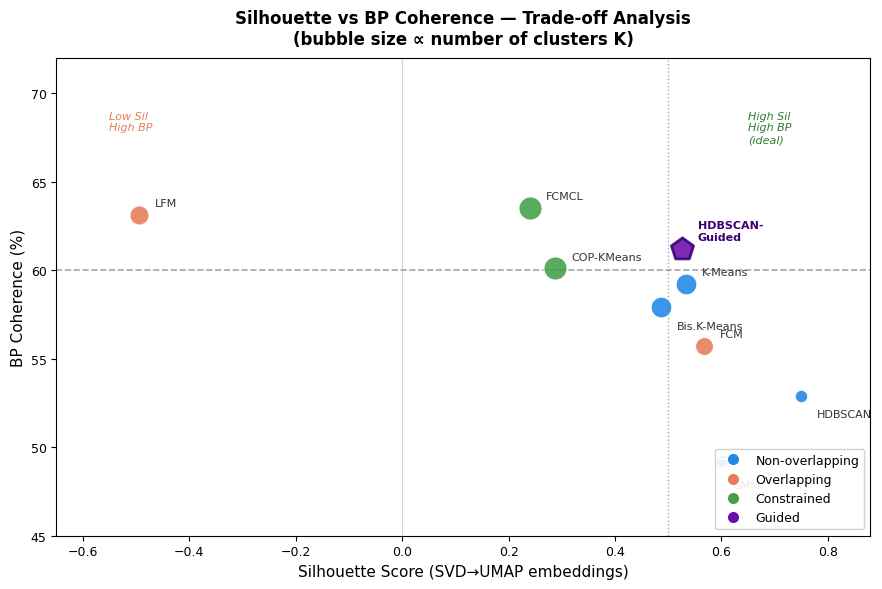

Saved figs/fig53_sil_vs_coh.png


In [67]:
# FIG  Silhouette vs BP Coherence bubble chart (bubble size ∝ K)

k_hm = [40, 40, 15, 12, 30, 50, 34, 50, 51]
fam_colors = {
    'Non-overlapping': '#1E88E5',
    'Overlapping':     '#E87B5A',
    'Constrained':     '#43A047',
    'Guided':          '#6A0DAD',
}
fam_markers = {
    'Non-overlapping': 'o',
    'Overlapping':     'o',
    'Constrained':     'o',
    'Guided':          'p',   # pentagon to highlight
}
# Short display labels
short_labels = {
    'K-Means':          'K-Means',
    'Bisecting K-Means':'Bis.K-Means',
    'GMM':              'GMM',
    'HDBSCAN':          'HDBSCAN',
    'FCM':              'FCM',
    'FCMCL':            'FCMCL',
    'LFM':              'LFM',
    'COP-KMeans':       'COP-KMeans',
    'HDBSCAN-Guided':   'HDBSCAN-\nGuided',
}

fig, ax = plt.subplots(figsize=(9, 6))

# Scale bubble area: base_area * (K / K_ref) with a minimum size
K_ref   = 40
base_sz = 220
min_sz  = 80

for m, fam, row, k in zip(methods_hm, families_hm, data_raw, k_hm):
    s, c = float(row[0]), float(row[1]) * 100   # coherence as %
    sz   = max(min_sz, base_sz * (k / K_ref))
    col  = fam_colors[fam]
    mk   = fam_markers[fam]
    guided = (m == 'HDBSCAN-Guided')
    ec   = '#3A006F' if guided else 'white'
    lw   = 2.0       if guided else 0.7
    ax.scatter(s, c, s=sz, color=col, marker=mk, zorder=3,
               edgecolors=ec, linewidths=lw, alpha=0.88)
    label = short_labels.get(m, m)
    offx, offy = 0.03, 0.5
    ha = 'left'
    if m == 'HDBSCAN-Guided': offx, offy = 0.03, 0.5; ha='left'
    if m == 'LFM':             offx, offy = 0.03, 0.5
    if m == 'HDBSCAN':         offx, offy = 0.03, -1.2; ha='left'
    if m == 'Bisecting K-Means': offx, offy = 0.03, -1.2
    if m == 'GMM':             offx, offy = 0.02, -1.5
    fc = '#3A006F' if guided else '#333'
    fw = 'bold'    if guided else 'normal'
    ax.annotate(label, (s, c), xytext=(s+offx, c+offy),
                fontsize=8, ha=ha, color=fc, fontweight=fw)

# Reference lines
ax.axhline(60, color='grey', lw=1.2, ls='--', alpha=0.7, label='60% BP ref')
ax.axvline(0.5, color='grey', lw=1.0, ls=':', alpha=0.7, label='Sil = 0.5')
ax.axvline(0, color='#aaa', lw=0.8, alpha=0.5)

# Quadrant annotations
ax.text(-0.55, 69, 'Low Sil\nHigh BP', fontsize=8, color='#E87B5A',
        ha='left', va='top', style='italic')
ax.text(0.65, 69, 'High Sil\nHigh BP\n(ideal)', fontsize=8, color='#2E7D32',
        ha='left', va='top', style='italic')

ax.set_xlabel('Silhouette Score (SVD→UMAP embeddings)', fontsize=11)
ax.set_ylabel('BP Coherence (%)', fontsize=11)
ax.set_title('Silhouette vs BP Coherence — Trade-off Analysis\n(bubble size ∝ number of clusters K)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlim(-0.65, 0.88); ax.set_ylim(45, 72)

# Legend: families
legend_els = [mlines.Line2D([],[],marker='o',color='w',
              markerfacecolor=fam_colors[f],markersize=9,label=f)
              for f in fam_colors]
ax.legend(handles=legend_els, fontsize=9, loc='lower right', framealpha=0.9)
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig('figs/fig53_sil_vs_coh.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/fig53_sil_vs_coh.png')


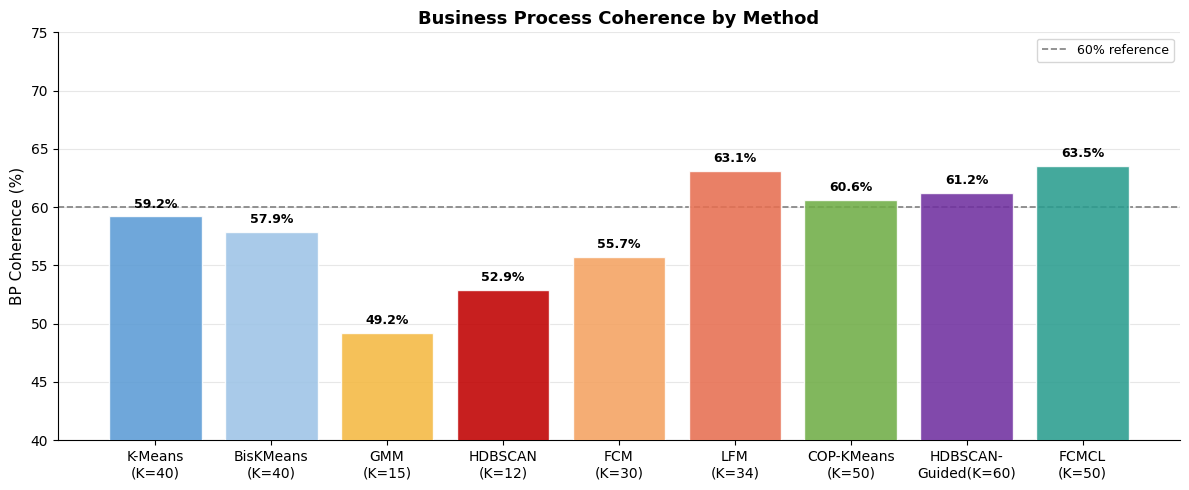

Saved figs/figC_bp_coherence.png


In [68]:
# FIG BP Coherence barchart — ALL methods including K-Means/BisKMeans


methods_bp = ['K-Means\n(K=40)', 'BisKMeans\n(K=40)', 'GMM\n(K=15)',
              'HDBSCAN\n(K=12)', 'FCM\n(K=30)', 'LFM\n(K=34)',
              'COP-KMeans\n(K=50)', 'HDBSCAN-\nGuided(K=60)', 'FCMCL\n(K=50)']
coh_vals = [0.592, 0.579, 0.492, 0.529, 0.557, 0.631, 0.606, 0.612, 0.635]
colors_bp = ['#5B9BD5','#9DC3E6','#F4B942','#C00000','#F4A261','#E76F51',
             '#70AD47','#7030A0','#2A9D8F']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(methods_bp, [v*100 for v in coh_vals], color=colors_bp, alpha=0.88,
              edgecolor='white', zorder=3)
for bar, v in zip(bars, coh_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v*100+0.5, f'{v*100:.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.axhline(60, color='grey', linestyle='--', linewidth=1.2, label='60% reference', zorder=2)
ax.set_ylabel('BP Coherence (%)', fontsize=11)
ax.set_title('Business Process Coherence by Method', fontsize=13, fontweight='bold')
ax.set_ylim(40, 75); ax.legend(fontsize=9)
ax.yaxis.grid(True, alpha=0.3, zorder=0); ax.set_axisbelow(True)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('figs/figC_bp_coherence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/figC_bp_coherence.png')


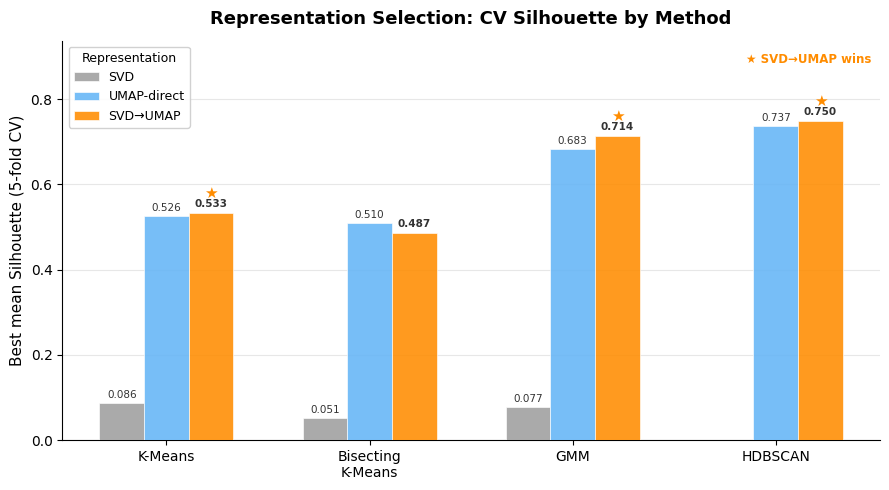

Saved figs/figTFG_repr_selection_sil.png


In [69]:
# FIG Representation Selection: CV Silhouette by method × representation
# Grouped bar chart showing best mean Silhouette per method per representation.
# Confirms SVD→UMAP as the primary representation.

# Load CV checkpoints if not in memory
_cp_dir = CHECKPOINT_DIR
for _var, _fname in [('cv_kmeans','cv_kmeans.json'), ('cv_bkmeans','cv_bkmeans.json'),
                     ('cv_gmm','cv_gmm.json'), ('cv_hdbscan','cv_hdbscan.json')]:
    if _var not in dir() or eval(_var) is None:
        _path = f'{_cp_dir}/{_fname}'
        if _os.path.exists(_path):
            with open(_path) as _f: exec(f'{_var} = _json.load(_f)')

def best_sil(cv_dict, repr_key, method_key=None):
    """Best mean CV Silhouette for a given representation (across all params)."""
    data = cv_dict.get(repr_key, {})
    if method_key:
        data = {method_key: data.get(method_key, {})}
    scores = []
    for kdict in data.values():
        for fold_scores in kdict.values():
            valid = [s for s in fold_scores if s == s and not np.isnan(s)]
            if valid: scores.append(np.mean(valid))
    return max(scores) if scores else np.nan

METHODS = {
    'K-Means':         cv_kmeans,
    'Bisecting\nK-Means': cv_bkmeans,
    'GMM':             cv_gmm,
    'HDBSCAN':         cv_hdbscan,
}
REPRS = ['SVD', 'UMAP_direct', 'SVD_UMAP']
REPR_LABELS = ['SVD', 'UMAP-direct', 'SVD→UMAP']
COLORS = ['#9E9E9E', '#64B5F6', '#FF8C00']

n_methods = len(METHODS)
n_reprs   = len(REPRS)
x = np.arange(n_methods)
w = 0.22

fig, ax = plt.subplots(figsize=(9, 5))

bars_all = []
for ri, (rep, rep_label, color) in enumerate(zip(REPRS, REPR_LABELS, COLORS)):
    vals = [best_sil(cv, rep) for cv in METHODS.values()]
    offset = (ri - 1) * w
    bars = ax.bar(x + offset, vals, w, label=rep_label, color=color,
                  alpha=0.88, zorder=3, edgecolor='white', linewidth=0.5)
    bars_all.append((bars, vals, rep))
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.008,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7.5,
                    color='#333333', fontweight='bold' if rep == 'SVD_UMAP' else 'normal')

# Highlight SVD_UMAP bars with a star where it wins
svd_umap_vals = [best_sil(cv, 'SVD_UMAP') for cv in METHODS.values()]
umap_d_vals   = [best_sil(cv, 'UMAP_direct') for cv in METHODS.values()]
for i, (sv, ud) in enumerate(zip(svd_umap_vals, umap_d_vals)):
    if sv > ud:
        ax.text(x[i] + w, max(sv, ud) + 0.035, '★', ha='center',
                fontsize=11, color='#FF8C00')

ax.set_xticks(x)
ax.set_xticklabels(list(METHODS.keys()), fontsize=10)
ax.set_ylabel('Best mean Silhouette (5-fold CV)', fontsize=11)
ax.set_title('Representation Selection: CV Silhouette by Method',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0, max(svd_umap_vals) * 1.25)
ax.yaxis.grid(True, alpha=0.3, zorder=0); ax.set_axisbelow(True)
ax.spines[['top','right']].set_visible(False)

legend = ax.legend(title='Representation', fontsize=9, title_fontsize=9,
                   loc='upper left', framealpha=0.9)
ax.annotate('★ SVD→UMAP wins', xy=(0.99, 0.97), xycoords='axes fraction',
            ha='right', va='top', fontsize=8.5, color='#FF8C00',
            fontweight='bold')

plt.tight_layout()
plt.savefig('figs/figTFG_repr_selection_sil.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/figTFG_repr_selection_sil.png')


### Extra Metrics: BP Coherence (K-Means / BisKMeans) and ARI Stability (Constrained Methods)

In [70]:
# EXTRA METRICS: BP Coherence for K-Means and Bisecting K-Means


# Representation: SVD_UMAP (best from CV)
X_bp = sk_normalize(X_umap_on_svd_norm)

# BP array for all job titles in jt_list
bp_col_meta = 'BUSINESS PROCESS'
bp_array_meta = [df_jt_metadata.set_index('JOB_TITLE')[bp_col_meta].to_dict().get(jt, None)
                 for jt in jt_list]

def bp_coherence_score(labels, bp_array):
    clusters = {}
    for idx, lbl in enumerate(labels):
        if lbl == -1: continue
        clusters.setdefault(lbl, []).append(bp_array[idx])
    coh = []
    for bps in clusters.values():
        clean = [b for b in bps if b is not None and str(b) != 'nan']
        if clean:
            coh.append(pd.Series(clean).value_counts().iloc[0] / len(clean))
    return float(np.mean(coh)) if coh else 0.0

# K-Means K=40
km = KMeans(n_clusters=40, random_state=RANDOM_STATE, n_init=10, max_iter=300)
labels_km40 = km.fit_predict(X_bp)
coh_km = bp_coherence_score(labels_km40, bp_array_meta)
print(f'K-Means     K=40  BP Coherence: {coh_km:.3f}  ({coh_km*100:.1f}%)')

# Bisecting K-Means K=40
bkm = BisectingKMeans(n_clusters=40, random_state=RANDOM_STATE, n_init=3)
labels_bkm40 = bkm.fit_predict(X_bp)
coh_bkm = bp_coherence_score(labels_bkm40, bp_array_meta)
print(f'BisKMeans   K=40  BP Coherence: {coh_bkm:.3f}  ({coh_bkm*100:.1f}%)')


K-Means     K=40  BP Coherence: 0.592  (59.2%)
BisKMeans   K=40  BP Coherence: 0.579  (57.9%)


In [71]:
# EXTRA METRICS: ARI Stability for COP-KMeans and HDBSCAN-Guided
# ARI stability = mean pairwise ARI across seeds [42, 123, 456]
# on the full dataset (no CV splits needed).
# COP-KMeans: simplified implementation (random init + CL enforcement)
# HDBSCAN-Guided: KMeans-guided distance modification + HDBSCAN

X_ari = X_umap_on_svd_norm  # SVD_UMAP representation

# COP-KMeans (simplified)
def cop_kmeans_ari(X, k, cl, random_state=42, max_iter=100):
    rng = np.random.RandomState(random_state)
    n = len(X)
    cl_map = {}
    for a, b in cl:
        cl_map.setdefault(a, set()).add(b)
        cl_map.setdefault(b, set()).add(a)
    centroids = X[rng.choice(n, k, replace=False)].copy()
    labels = np.zeros(n, dtype=int)
    for _ in range(max_iter):
        old = labels.copy()
        dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        order = np.argsort(dists, axis=1)
        for i in range(n):
            assigned = False
            for c in order[i]:
                if all(labels[j] != c for j in cl_map.get(i, set())):
                    labels[i] = c; assigned = True; break
            if not assigned:
                labels[i] = order[i, 0]
        for c in range(k):
            m = labels == c
            if m.sum() > 0: centroids[c] = X[m].mean(0)
        if np.all(labels == old): break
    return labels

# HDBSCAN-Guided
def hdbscan_guided_ari(X, guide_k=40, boost=0.5, mcs=5, ms=4, random_state=42):
    n = len(X)
    g = KMeans(n_clusters=guide_k, random_state=random_state, n_init=5).fit_predict(X)
    D = pairwise_distances(X, metric='euclidean').astype(np.float64)
    for i in range(n):
        for j in range(i+1, n):
            if g[i] == g[j]: D[i,j] *= (1-boost); D[j,i] *= (1-boost)
    lbl = hdbscan_lib.HDBSCAN(min_cluster_size=mcs, min_samples=ms,
                               metric='precomputed').fit_predict(D)
    unique_c = [c for c in set(lbl) if c != -1]
    if -1 in lbl and unique_c:
        cents = np.array([X[lbl==c].mean(0) for c in unique_c])
        for i in np.where(lbl==-1)[0]:
            lbl[i] = unique_c[np.argmin(np.linalg.norm(X[i]-cents, axis=1))]
    return lbl

SEEDS_ARI = [42, 123, 456]

# COP-KMeans ARI
print('COP-KMeans ARI stability (K=50, smart CL)...')
cop_lbls = [cop_kmeans_ari(X_ari, k=50, cl=cl_smart, random_state=s) for s in SEEDS_ARI]
aris_cop = [adjusted_rand_score(cop_lbls[i], cop_lbls[j]) for i,j in combinations(range(3),2)]
print(f'  ARI: {np.mean(aris_cop):.3f} +/- {np.std(aris_cop):.3f}')

# HDBSCAN-Guided ARI
print('HDBSCAN-Guided ARI stability (guide_k=40, boost=0.5, mcs=5, ms=4)...')
guided_lbls = [hdbscan_guided_ari(X_ari, guide_k=40, boost=0.5, mcs=5, ms=4, random_state=s)
               for s in SEEDS_ARI]
aris_guided = [adjusted_rand_score(guided_lbls[i], guided_lbls[j]) for i,j in combinations(range(3),2)]
print(f'  ARI: {np.mean(aris_guided):.3f} +/- {np.std(aris_guided):.3f}')

# GMM ARI stability (K=15, BIC-selected, covariance_type='diag')
# Cell 40 computes this inside the CV loop after the errstate fix;
# this cell provides a standalone verification with the final K.
from sklearn.mixture import GaussianMixture

print('GMM ARI stability (K=15, BIC-selected)...')
gmm_lbls = []
for s in SEEDS_ARI:
    gmm = GaussianMixture(n_components=15, covariance_type='diag',
                          random_state=s, max_iter=300)
    with np.errstate(under='ignore'):
        lbl = gmm.fit_predict(X_ari)
    gmm_lbls.append(lbl)
aris_gmm = [adjusted_rand_score(gmm_lbls[i], gmm_lbls[j]) for i,j in combinations(range(3),2)]
print(f'  ARI: {np.mean(aris_gmm):.3f} +/- {np.std(aris_gmm):.3f}')


COP-KMeans ARI stability (K=50, smart CL)...
  ARI: 0.599 +/- 0.031
HDBSCAN-Guided ARI stability (guide_k=40, boost=0.5, mcs=5, ms=4)...
  ARI: 0.926 +/- 0.015
GMM ARI stability (K=15, BIC-selected)...
  ARI: 0.872 +/- 0.090
